**Integrantes del grupo: GATOBYTE**


*   Ivonne Micaela Colque Murillo
*   Dilan Obed Mamani Pamuri
*   Tania Morelia Pérez Dick
*   Ignacio Retamozo Torrez
*   Adriana Nathalie Rocha Vedia



Instalar las dependencias usando el archivo requirements.txt o ejecutando el contenedor docker que se tiene en el repositorio de github

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [ ]:
import cudf
import os
import cuml
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")
import re, re, time, gc
import nltk
import unicodedata
import contractions
import cupy as cp
import cupyx.scipy.sparse as cpx_sp
import scipy.sparse as sp
import torch

from pathlib import Path
from joblib import Parallel, delayed, Memory

# NLP
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# cuML Pipeline y preprocesadores
from cuml.pipeline import Pipeline as CumlPipeline
from cuml.dask.common.base import Base
from cuml.compose import ColumnTransformer as CumlColumnTransformer
from cuml.preprocessing import StandardScaler as CumlStandardScaler
from cuml.feature_extraction.text import TfidfVectorizer as CumlTfidfVectorizer
from cuml.naive_bayes import MultinomialNB
from cuml.linear_model import LogisticRegression as cuLR
from cuml.svm import LinearSVC as cuLinearSVC
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.neighbors import KNeighborsClassifier as cuKNN
from cuml.naive_bayes import MultinomialNB
from cuml.metrics import confusion_matrix as cuml_confusion_matrix
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    f1_score,
)

# sklearn solo para TF-IDF, GridSearch y modelos no cuML
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin


# Modelos cuML nativos
from cuml.naive_bayes import MultinomialNB
from cuml.linear_model import LogisticRegression as cuLR
from cuml.svm import LinearSVC as cuLinearSVC
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.neighbors import KNeighborsClassifier as cuKNN

# Modelos con GPU propia (no cuML)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Optimización
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Explainability
import shap

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print('Dependencias listas')

# Paleta corporativa consistente
PALETTE = {
    "positive": "#1D9E75",
    "neutral":  "#EF9F27",
    "negative": "#E24B4A",
    "r1": "#E24B4A",
    "r2": "#EF9F27",
    "r3": "#FAC775",
    "r4": "#9FE1CB",
    "r5": "#1D9E75",
    "accent":   "#378ADD",
    "gray":     "#888780",
    "bg":       "#F8F7F4",
}

RATING_COLORS = [PALETTE[f"r{i}"] for i in range(1, 6)]
SENTIMENT_COLORS = [PALETTE["positive"], PALETTE["neutral"], PALETTE["negative"]]

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["bg"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.family":       "DejaVu Sans",
    "font.size":         11,
})

# Carga de semilla
SEED = 42
np.random.seed(SEED)

print("Librerías cargadas correctamente")
print('Configuración global cargada — SEED =', SEED)

Dependencias listas
Librerías cargadas correctamente
Configuración global cargada — SEED = 42


Funcion para obtener la ruta relativa del archivo e interrumpir el proceso si es que no se carga los datos

In [ ]:
def obtener_ruta_datos(nombre_archivo="sample_ml.parquet"):
    # 1. Intentar ruta relativa (Funciona en PC y Colab si la estructura es la misma)
    # Si el notebook está en /notebooks, buscamos en ../data-processed/
    ruta_relativa = Path("..") / "data/processed" / nombre_archivo

    # 2. Definir ruta absoluta de Colab (Drive)
    ruta_drive = Path("/content/drive/MyDrive/ML/data/processed") / nombre_archivo

    # Lógica de búsqueda
    if ruta_relativa.exists():
        print(f"Archivo encontrado en ruta relativa: {ruta_relativa}")
        return str(ruta_relativa)

    elif ruta_drive.exists():
        print(f"Archivo encontrado en Google Drive: {ruta_drive}")
        return str(ruta_drive)

    else:
        # Mensaje de error si no existe en ninguna
        print("-" * 50)
        print(f"ERROR: No se encontró '{nombre_archivo}'")
        print("Por favor, asegúrate de correr el archivo de sampleo primero.")
        print("-" * 50)
        return None

Busca el archivo de forma híbrida:
    1. Sube un nivel ('..') para buscar en 'data/processed' (Estructura Local/Colab).
    2. Si falla, busca en la ruta absoluta de Google Drive.
    3. Si no está en ninguna, avisa que falta ejecutar el script de sampleo.
    Utiliza Pathlib para que los slashes funcionen en Windows y Linux/Colab sin cambios.

In [ ]:
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
except ImportError:
    print("Sujeto ejecutando en entorno local (No Colab).")

# Definir directorios de guardado
SAVE_DIR = Path('/content/drive/MyDrive/ML/models') if os.path.exists('/content/drive') else Path('models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Obtener la ruta
ruta_final = obtener_ruta_datos()

if ruta_final:
    # Leer el archivo directamente a la memoria de la GPU
    df_gpu = cudf.read_parquet(ruta_final)

    # Mostrar la forma y columnas
    print(f'Shape: {df_gpu.shape}')
    print(f'Columnas: {df_gpu.columns.tolist()}')

    # Mostrar los primeros registros
    print(df_gpu.head())

Shape: (1000000, 20)
Columnas: ['rating', 'title', 'text', 'parent_asin', 'timestamp', 'helpful_vote', 'verified_purchase', 'text_len', 'sentiment', 'is_satisfied', 'review_date', 'main_category', 'average_rating', 'rating_number', 'price', 'features', 'description', 'details', 'price_imputed', 'product_title']
   rating                        title  \
0     5.0                     Love it!   
1     5.0          Best computer ever!   
2     3.0    Sometimes it doesn't work   
3     5.0  Excellent for transcription   
4     5.0                   Fire stick   

                                                text parent_asin  \
0  I think this is a great stand. It is very stur...  B003TLSXMO   
1  I work from home and am a bit of a computer ju...  B0098O6GD4   
2  Sometimes I have to turn off and on my radio a...  B07VTK654B   
3            Easy to setup and excellent performance  B003VAHYNC   
4  Was very easy to install and produced viewing ...  B0791TX5P5   

       timestamp  helpful

El dataset presenta un volumen robusto de 1 millón de registros, tomados de un dataset de 40M, ideal para arquitecturas de Machine Learning aceleradas por GPU, aunque requiere una limpieza estratégica debido a la presencia de Target Leakage en columnas como rating e is_satisfied, las cuales deben eliminarse para evitar que el modelo haga "trampa" prediciendo el sentimiento a través de la calificación numérica en lugar del texto. Se observa una gran riqueza informativa en los metadatos de producto (features, description), aunque estos vienen en formatos de lista tipo JSON que exigirán un preprocesamiento de texto más agresivo. Finalmente, la inclusión de la columna price_imputed es un acierto técnico importante, ya que permite controlar el sesgo introducido al rellenar valores faltantes en la variable price, la cual suele ser un predictor clave de la satisfacción del cliente.

# CRISP-DM · FASE 1: BUSINESS UNDERSTANDING

Definición del Proyecto: Clasificación de Sentimiento
Objetivo del Negocio
Desarrollar un sistema de clasificación automatizada para reseñas de productos electrónicos de Amazon, categorizando la experiencia del usuario en tres niveles: Positivo, Neutro y Negativo.

Variable Objetivo (sentiment): Derivada de la métrica de satisfacción original (Rating).

Positivo: 4–5 estrellas.

Neutro: 3 estrellas.

Negativo: 1–2 estrellas.

Desafíos Técnicos y Restricciones
Desbalance de Clases: El dataset presenta un sesgo significativo hacia la clase mayoritaria (74% positivo), lo que exige una estrategia de modelado sensible a clases minoritarias.

Escalabilidad: Procesamiento de una submuestra masiva de 32.4 millones de registros, requiriendo optimización de memoria y cómputo distribuido o acelerado por GPU.

Integridad de Datos: Tratamiento de variables con valores imputados (columna price), garantizando la trazabilidad mediante el flag price_imputed.

Heterogeneidad Textual: Alta variabilidad en la carga informativa de las reseñas, con extensiones que fluctúan desde micro-comentarios (39 caracteres) hasta descripciones extensas (1,233+ caracteres).

Prevención de Data Leakage: Prohibición estricta del uso de la variable rating como predictor, dado que constituye la base lógica del target, invalidando la capacidad de generalización del modelo.

Criterios de Éxito y Evaluación
Para validar la viabilidad del modelo en un entorno de producción, se establecen los siguientes KPIs:

F1-Score (Macro) ≥ 0.65: Métrica principal para garantizar un desempeño equilibrado y penalizar errores en las categorías neutra y negativa.

Accuracy Global ≥ 0.80: Nivel de acierto general esperado para la estabilidad del sistema.

El valor estratégico de este proyecto reside en la capacidad de transformar millones de interacciones no estructuradas en inteligencia accionable para la toma de decisiones. En un mercado tan competitivo como el de electrónica en Amazon, comprender el sentimiento detrás de una reseña permite identificar fallos críticos de producto en tiempo real, optimizar el servicio al cliente y ajustar las estrategias de precios basadas en la percepción de valor del usuario. Automatizar este proceso no solo reduce drásticamente los costos operativos de análisis manual, sino que permite reaccionar ante tendencias de insatisfacción antes de que afecten la reputación de la marca, convirtiendo datos masivos en una ventaja competitiva directa que impacta la retención de clientes y el crecimiento de los ingresos.

# CRISP-DM · Fase 2: Data Understanding

In [ ]:
print("\n Tipos de datos:")
print(df_gpu.dtypes)

# Estadísticas básicas — cudf soporta .describe() directamente
num_cols = ["rating", "helpful_vote", "text_len", "average_rating",
            "rating_number", "price"]
cols_present = [c for c in num_cols if c in df_gpu.columns]

print("\n Estadísticas descriptivas (numéricas):")
print(df_gpu[cols_present].describe())


 Tipos de datos:
rating                      float64
title                        object
text                         object
parent_asin                  object
timestamp                     int64
helpful_vote                  int64
verified_purchase              bool
text_len                     uint32
sentiment                    object
is_satisfied                   bool
review_date          datetime64[us]
main_category                object
average_rating              float64
rating_number                 int64
price                       float64
features                     object
description                  object
details                      object
price_imputed                  int8
product_title                object
dtype: object

 Estadísticas descriptivas (numéricas):
               rating    helpful_vote        text_len  average_rating  \
count  1000000.000000  1000000.000000  1000000.000000  1000000.000000   
mean         3.940334        1.030260      245.656831        

**OBSERVACIONES**

Longitud de Reseñas (text_len): Con una media de 245 caracteres y un máximo de 2500, las reseñas son mayoritariamente cortas pero informativas. El hecho de que el 75% de los datos esté por debajo de los 293 caracteres sugiere que un modelo basado en TF-IDF con un límite de 10k-20k características será muy eficiente sin perder mucho contexto.

Sesgo de Calificación (rating): La mediana (50%) es 5.0, lo que confirma estadísticamente el fuerte desbalance hacia el sentimiento positivo. Esto valida tu decisión de usar F1-Macro como métrica de éxito, ya que el modelo tenderá naturalmente a ignorar las clases 1, 2 y 3 estrellas.

Dispersión en el Precio (price): La desviación estándar es muy alta (124.22) frente a una media de 51.56. Esto indica la presencia de outliers (productos muy caros) que podrían distorsionar el escalado.

Engagement (helpful_vote): La gran mayoría de las reseñas tienen 0 votos útiles. Sin embargo, el máximo de 4563 indica que unas pocas reseñas tienen un peso social enorme; estas podrían ser candidatas para un análisis cualitativo de errores más adelante.

Atributos de Producto: Las columnas features, description y details aparecen como object. Al ser listas o diccionarios convertidos a texto, requerirán una limpieza de caracteres especiales.

Consistencia de Identificadores: parent_asin y product_title permiten agrupar por producto. Esto es útil para detectar si ciertos productos tienen problemas sistemáticos (muchos neutros/negativos) que el modelo deba capturar.

Data Leakage: La correlación entre rating y sentiment será casi total (por definición). Se debe asegurar que rating, is_satisfied, average_rating y rating_number queden fuera del entrenamiento.

Valores Extremos: El text_len mínimo de 30 caracteres es saludable; evita procesar filas con una sola palabra que no aportan valor semántico real.

In [ ]:
if "review_date" in df_gpu.columns and df_gpu["review_date"].dtype == object:
    df_gpu["review_date"] = cudf.to_datetime(df_gpu["review_date"], errors="coerce")

if "review_date" in df_gpu.columns:
    df_gpu["review_year"] = df_gpu["review_date"].dt.year

print("Columnas derivadas listas")
print(f"Shape final: {df_gpu.shape}")

Columnas derivadas listas
Shape final: (1000000, 21)


El datasset final para trabajar es de un millon de filas y 21 features

In [ ]:
def gpu_groupby_count(df, group_cols, alias="n"):
    """Agrupa en GPU y devuelve pandas."""
    return (
        df.groupby(group_cols)
          .size()
          .reset_index()
          .rename(columns={0: alias})
          .to_pandas()
    )

def gpu_groupby_agg(df, group_col, agg_col, agg_fn="mean"):
    """Agregación simple en GPU → pandas."""
    grp = df.groupby(group_col)[agg_col]
    result = getattr(grp, agg_fn)().reset_index()
    return result.to_pandas()

funciones para pasar de cudf a pandas

### 2.1 DISTRIBUCION DE RATING

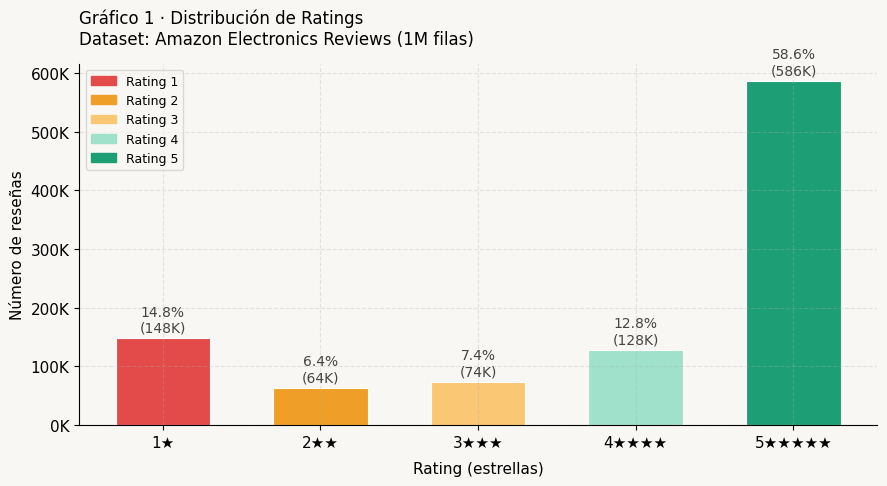

In [ ]:
rating_dist = gpu_groupby_count(df_gpu, "rating", alias="n")
rating_dist = rating_dist.sort_values("rating").reset_index(drop=True)
rating_dist["pct"] = rating_dist["n"] / rating_dist["n"].sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(PALETTE["bg"])

bars = ax.bar(
    rating_dist["rating"].astype(str),
    rating_dist["n"],
    color=RATING_COLORS,
    width=0.6,
    edgecolor="white",
    linewidth=0.8
)

for bar, pct, n in zip(bars, rating_dist["pct"], rating_dist["n"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + rating_dist["n"].max() * 0.01,
            f"{pct:.1f}%\n({n/1e3:.0f}K)",
            ha="center", va="bottom", fontsize=10, color="#444441")

ax.set_xlabel("Rating (estrellas)", labelpad=8)
ax.set_ylabel("Número de reseñas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_title("Gráfico 1 · Distribución de Ratings\n"
             "Dataset: Amazon Electronics Reviews (1M filas)",
             fontsize=12, pad=14, loc="left")
ax.set_xticklabels(["1★", "2★★", "3★★★", "4★★★★", "5★★★★★"])

legend_patches = [mpatches.Patch(color=PALETTE[f"r{i}"], label=f"Rating {i}") for i in range(1, 6)]
ax.legend(handles=legend_patches, loc="upper left", framealpha=0.7, fontsize=9)

plt.tight_layout()
plt.savefig("grafico_01_rating_dist.png", dpi=150, bbox_inches="tight")
plt.show()

Se puede observar que la clase mayoritaria se encuentra en las observaciones con un valor de ratingg de 5, esto es debido a que es una experiencia totalmente libre y los usuarios solo suelen participar en un extremo, si les encanto el producto o si lo odiaron. Los productos con muchas reseñas negativas son expulsados y por ultimo los vendedores son proactivos, dando incentivos a dejar una reseña positiva

### 2.2 DISTRIBUCION DE SENTIMIENTO

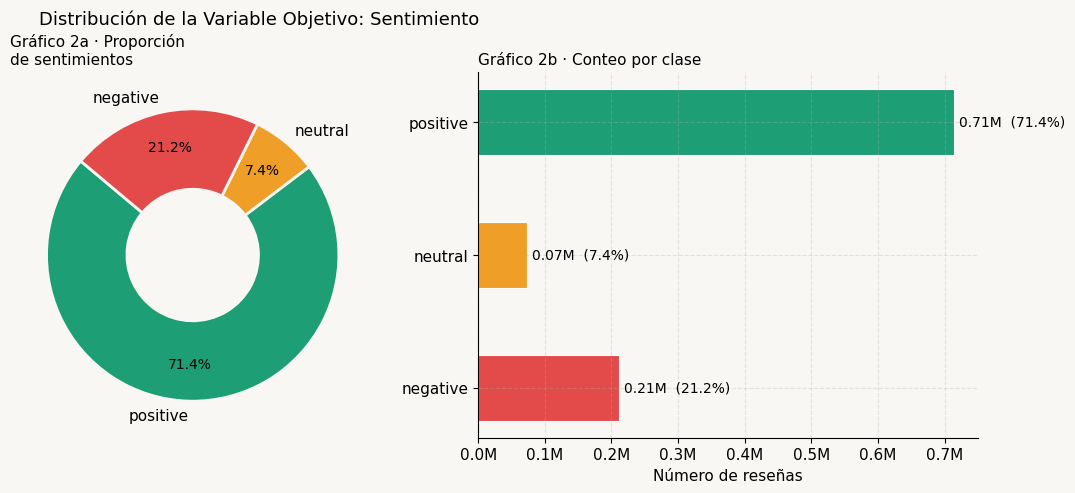

In [ ]:
sent_order = ["positive", "neutral", "negative"]
sent_dist = gpu_groupby_count(df_gpu, "sentiment", alias="n")
sent_dist = sent_dist.set_index("sentiment").reindex(sent_order).reset_index()
sent_dist["pct"] = sent_dist["n"] / sent_dist["n"].sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5),
                                gridspec_kw={"width_ratios": [1, 1.3]})
fig.patch.set_facecolor(PALETTE["bg"])

wedges, texts, autotexts = ax1.pie(
    sent_dist["pct"],
    labels=sent_order,
    colors=SENTIMENT_COLORS,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75,
    wedgeprops={"width": 0.55, "edgecolor": PALETTE["bg"], "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(10)
ax1.set_title("Gráfico 2a · Proporción\nde sentimientos", fontsize=11, loc="left")

colors_h = [PALETTE[s] for s in sent_order]
bars = ax2.barh(sent_dist["sentiment"], sent_dist["n"],
                color=colors_h, edgecolor="white", linewidth=0.8, height=0.5)
for bar, n, pct in zip(bars, sent_dist["n"], sent_dist["pct"]):
    ax2.text(bar.get_width() + sent_dist["n"].max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{n/1e6:.2f}M  ({pct:.1f}%)",
             va="center", fontsize=10)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax2.set_xlabel("Número de reseñas")
ax2.set_title("Gráfico 2b · Conteo por clase", fontsize=11, loc="left")
ax2.invert_yaxis()

fig.suptitle("Distribución de la Variable Objetivo: Sentimiento", fontsize=13, x=0.05, ha="left")
plt.tight_layout()
plt.savefig("grafico_02_sentiment_dist.png", dpi=150, bbox_inches="tight")
plt.show()

La distribución de las etiquetas de sentimiento revela un comportamiento de polarización extrema, característico de las plataformas de feedback voluntario.



Debido a que el 74% de la masa de datos se concentra en lo positivo, el modelo corre el riesgo de desarrollar un "sesgo de optimismo". Técnicamente, esto significa que la Matriz de Confusión probablemente mostrará una tendencia a clasificar reseñas neutras como positivas.

La escasez de la clase neutra sugiere que el consumidor promedio de Amazon se mueve por impulsos bivalentes (amor/odio), dejando la categoría de 3 estrellas como un 'ruido estadístico' que requerirá técnicas de remuestreo o pesos específicos en la función de pérdida (class_weight).

Identificar correctamente la clase minoritaria (negativa) es más crítico para el negocio que la positiva, ya que representa el churn potencial y el riesgo reputacional.

### 2.3 LONGITUD DE RESEÑA POR SENTIMIENTO

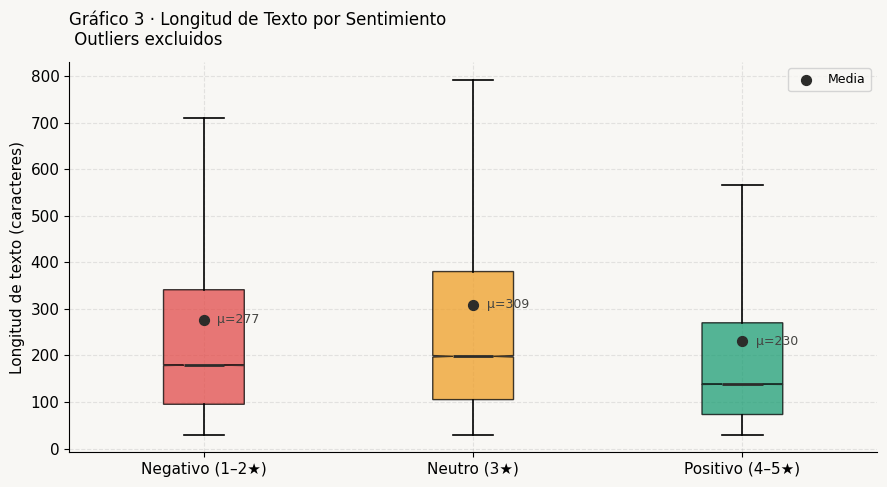

Longitud promedio por rating:
   Rating 1★: 258 chars
   Rating 2★: 319 chars
   Rating 3★: 309 chars
   Rating 4★: 303 chars
   Rating 5★: 214 chars


In [ ]:
df_sample = (
    df_gpu[["rating", "sentiment", "text_len", "helpful_vote", "verified_purchase"]]

    .to_pandas()
)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(PALETTE["bg"])

sent_plot_order = ["negative", "neutral", "positive"]
colors_box = [PALETTE["negative"], PALETTE["neutral"], PALETTE["positive"]]

bp = ax.boxplot(
    [df_sample[df_sample["sentiment"] == s]["text_len"].dropna() for s in sent_plot_order],
    labels=["Negativo (1–2★)", "Neutro (3★)", "Positivo (4–5★)"],
    patch_artist=True,
    notch=True,
    showfliers=False,
    medianprops={"color": "#2C2C2A", "linewidth": 2},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2}
)
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for i, s in enumerate(sent_plot_order, start=1):
    mean_val = df_sample[df_sample["sentiment"] == s]["text_len"].mean()
    ax.scatter(i, mean_val, color="#2C2C2A", s=50, zorder=5, label="Media" if i == 1 else "")
    ax.text(i + 0.05, mean_val, f"μ={mean_val:.0f}", va="center", fontsize=9, color="#444441")

ax.set_ylabel("Longitud de texto (caracteres)")
ax.set_title("Gráfico 3 · Longitud de Texto por Sentimiento\n"
             f" Outliers excluidos",
             fontsize=12, pad=12, loc="left")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("grafico_03_textlen_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

# Promedio por rating — en GPU
avg_by_rating = gpu_groupby_agg(df_gpu, "rating", "text_len", agg_fn="mean")
avg_by_rating = avg_by_rating.sort_values("rating")
print("Longitud promedio por rating:")
for _, row in avg_by_rating.iterrows():
    print(f"   Rating {int(row['rating'])}★: {row['text_len']:.0f} chars")

Aunque el sentimiento positivo domina el dataset (efecto del "sobreviviente" en productos exitosos), el sentimiento negativo posee una carga semántica mucho más rica y específica. Mientras que las reseñas positivas suelen ser genéricas ("Excelente producto", "Me encantó"), las negativas tienden a detallar fallos técnicos específicos, lo que las hace altamente valiosas para el entrenamiento de modelos de detección de errores. Pero tambien se observa que a pesar de esto, la categoría neutra es la que contiene mas chars en promedio que las otras dos clases.

El Rating 5★ tiene la longitud más corta (214 caracteres). Esto ocurre porque la satisfacción suele expresarse de forma concisa y genérica: "Excelente producto, llegó rápido y funciona bien". Al no haber fricción con el producto, el usuario no siente la necesidad de justificar su nota con explicaciones técnicas extensas.

El Rating 2★ presenta la longitud más alta (319 caracteres). Esto es sumamente interesante por dos razones:

La reseña de 2 estrellas es constructiva: A diferencia del 1★, donde el usuario a veces solo deja un insulto o queja corta por un envío fallido, el que califica con 2★ suele haber probado el producto, encontrado fallos específicos y se toma el tiempo de explicar por qué "pudo ser bueno pero no lo fue.

Los sentimientos negativos y neutros (ratings 2, 3 y 4) exigen más palabras porque el usuario está intentando balancear su opinión o detallar una decepción, lo que genera una densidad semántica mucho mayor que la de un 5★.

### 2.4 DISTRIBUCION DE HELPFUL_VOTES

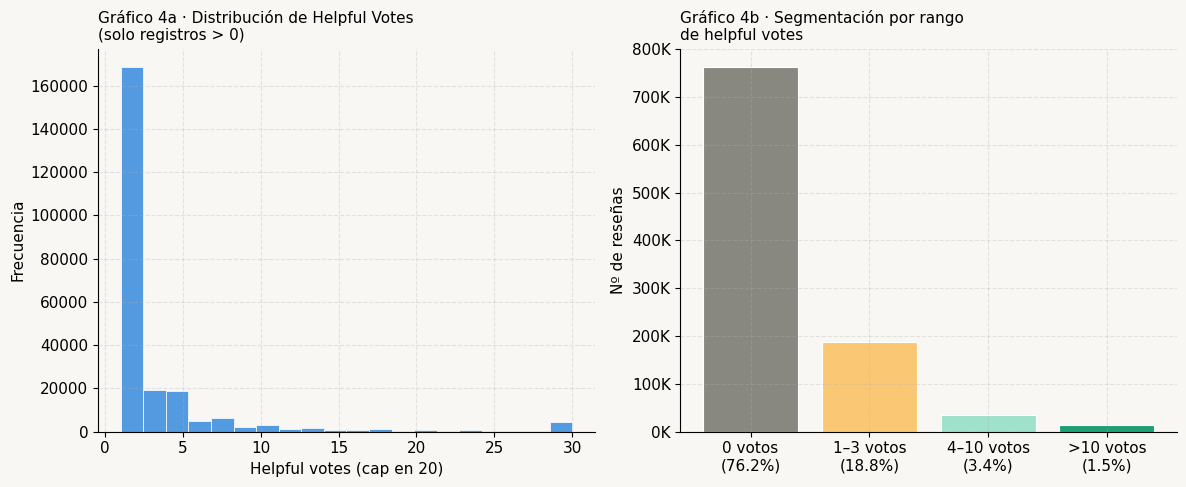

In [ ]:
hv = df_sample["helpful_vote"].clip(upper=30)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(PALETTE["bg"])

axes[0].hist(hv[hv > 0], bins=20, color=PALETTE["accent"],
             edgecolor="white", linewidth=0.6, alpha=0.85)
axes[0].set_xlabel("Helpful votes (cap en 20)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Gráfico 4a · Distribución de Helpful Votes\n(solo registros > 0)",
                  fontsize=11, loc="left")

# Calcular breakdowns desde GPU para precisión sobre 1M filas
total = df_gpu.shape[0]
hv_gpu = df_gpu["helpful_vote"]
hv_stats_vals = {
    f"0 votos\n({(hv_gpu == 0).sum().item()/total*100:.1f}%)":
        (hv_gpu == 0).sum().item(),
    f"1–3 votos\n({((hv_gpu >= 1) & (hv_gpu <= 3)).sum().item()/total*100:.1f}%)":
        ((hv_gpu >= 1) & (hv_gpu <= 3)).sum().item(),
    f"4–10 votos\n({((hv_gpu >= 4) & (hv_gpu <= 10)).sum().item()/total*100:.1f}%)":
        ((hv_gpu >= 4) & (hv_gpu <= 10)).sum().item(),
    f">10 votos\n({(hv_gpu > 10).sum().item()/total*100:.1f}%)":
        (hv_gpu > 10).sum().item(),
}
bar_colors = [PALETTE["gray"], PALETTE["r3"], PALETTE["r4"], PALETTE["r5"]]
axes[1].bar(list(hv_stats_vals.keys()), list(hv_stats_vals.values()),
            color=bar_colors, edgecolor="white", linewidth=0.8)
axes[1].set_ylabel("Nº de reseñas")
axes[1].set_title("Gráfico 4b · Segmentación por rango\nde helpful votes",
                  fontsize=11, loc="left")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig("grafico_04_helpful_votes.png", dpi=150, bbox_inches="tight")
plt.show()

Si el 76.2% de las reseñas tienen 0 votos útiles, significa que tres cuartas partes del contenido generado por los usuarios nunca es validado por otros compradores.

Amazon utiliza el algoritmo Helpfulness para decidir qué reseñas mostrar primero. Esto crea un ciclo donde las reseñas que ya tienen votos siguen ganando votos porque están "arriba", mientras que las nuevas (el 76%) quedan enterradas en las últimas páginas.

Ese pequeño 1.5% que tiene más de 10 votos representa las reseñas críticas que realmente influyen en la decisión de compra.

### 2.5 DISTRIBUCION DE CATEGORIAS Y RESEÑAS

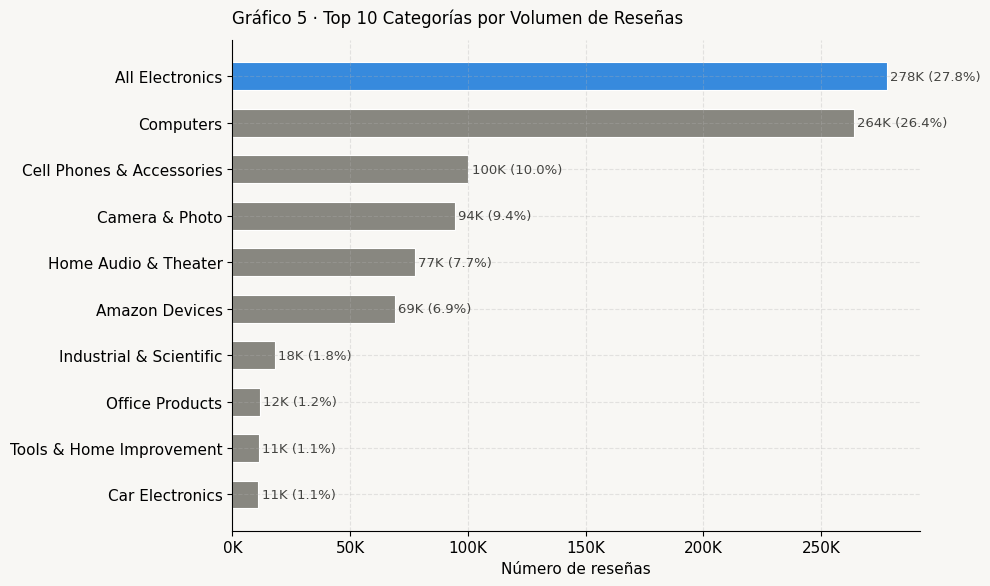

In [ ]:
cat_dist = gpu_groupby_count(df_gpu, "main_category", alias="n")
cat_dist = cat_dist.sort_values("n", ascending=False).head(10).reset_index(drop=True)
cat_dist["pct"] = cat_dist["n"] / df_gpu.shape[0] * 100

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(PALETTE["bg"])

bar_colors_cat = [PALETTE["accent"]] + [PALETTE["gray"]] * 9
bars = ax.barh(cat_dist["main_category"][::-1], cat_dist["n"][::-1],
               color=bar_colors_cat[::-1], edgecolor="white", linewidth=0.8, height=0.6)

for bar, pct, n in zip(bars, cat_dist["pct"][::-1], cat_dist["n"][::-1]):
    ax.text(bar.get_width() + cat_dist["n"].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{n/1e3:.0f}K ({pct:.1f}%)",
            va="center", fontsize=9.5, color="#444441")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_xlabel("Número de reseñas")
ax.set_title("Gráfico 5 · Top 10 Categorías por Volumen de Reseñas",
             fontsize=12, pad=12, loc="left")
plt.tight_layout()
plt.savefig("grafico_05_category_dist.png", dpi=150, bbox_inches="tight")
plt.show()


Las categorías All Electronics y Computers suman juntas el 54.2% del dataset.

Palabras como "lento", "caliente" o "ruido" tendrán un peso muy específico en estas categorías (indicando fallos de rendimiento). Sin embargo, ese mismo vocabulario podría no ser tan preciso para la categoría número 10, donde el contexto del producto cambia drásticamente ya que se trata de autos.

Si la décima categoría ya solo representa el 1.1%, significa que tienes una fragmentación enorme de nichos pequeños.

Esto refuerza la necesidad de usar un TfidfVectorizer robusto o un modelo de lenguaje que entienda el contexto general del inglés, para que pueda generalizar bien incluso en las categorías donde hay pocos datos.

### 2.6 SENTIMIENTO POR CATEGORIA

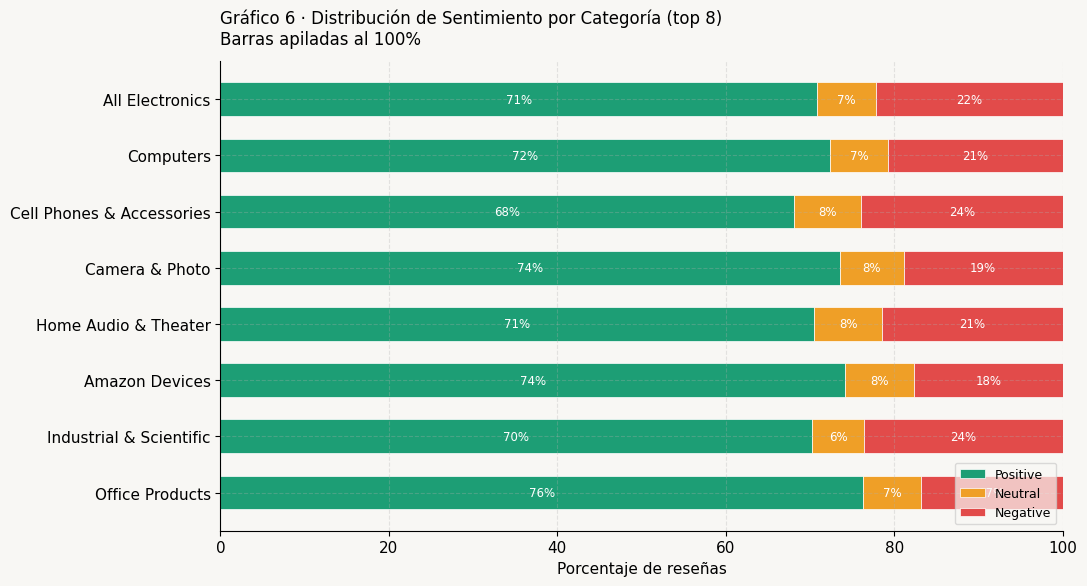

In [ ]:
TOP_CATS = cat_dist["main_category"].head(8).tolist()

sent_by_cat = (
    df_gpu[df_gpu["main_category"].isin(TOP_CATS)]
    .groupby(["main_category", "sentiment"])
    .size()
    .reset_index()
    .rename(columns={0: "n"})
    .to_pandas()
)

pivot = sent_by_cat.pivot(index="main_category", columns="sentiment", values="n").fillna(0)
for col in ["positive", "neutral", "negative"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["positive", "neutral", "negative"]]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.reindex(TOP_CATS)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(PALETTE["bg"])

left = np.zeros(len(pivot_pct))
for col, color in zip(["positive", "neutral", "negative"], SENTIMENT_COLORS):
    vals = pivot_pct[col].values
    ax.barh(pivot_pct.index, vals, left=left,
            color=color, edgecolor="white", linewidth=0.5, height=0.6, label=col.capitalize())
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 4:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                    fontsize=8.5, color="white", fontweight="500")
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel("Porcentaje de reseñas")
ax.set_title("Gráfico 6 · Distribución de Sentimiento por Categoría (top 8)\n"
             "Barras apiladas al 100%", fontsize=12, pad=12, loc="left")
ax.legend(loc="lower right", fontsize=9, framealpha=0.7)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("grafico_06_sentiment_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

Se ha verificado una homogeneidad en la distribución trans-categórica del sentimiento. A pesar de la disparidad en el volumen de datos entre nichos (dominados por All Electronics y Computers), la proporción de reseñas positivas, neutras y negativas permanece constante. Esta estabilidad sugiere que el sesgo de calificación es un fenómeno sistémico de la plataforma y no una variable dependiente del tipo de producto. Para el modelado, esto implica que el sistema de pesos de clases (class_weights) puede aplicarse de manera uniforme a todo el dataset, simplificando la arquitectura y mejorando la capacidad de generalización del clasificador.

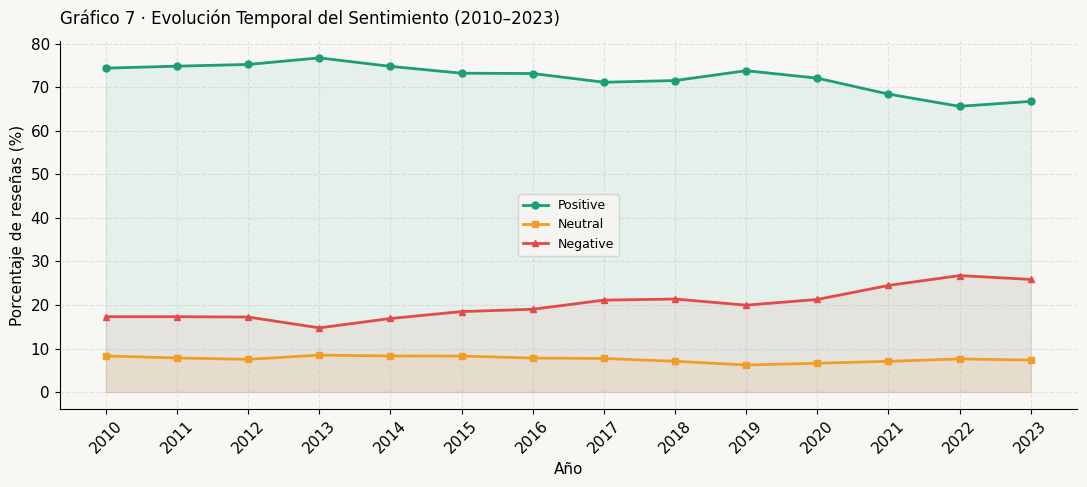

In [ ]:
if "review_year" in df_gpu.columns:
    temporal = (
        df_gpu[df_gpu["review_year"].notna() &
               (df_gpu["review_year"] >= 2010) &
               (df_gpu["review_year"] <= 2023)]
        .groupby(["review_year", "sentiment"])
        .size()
        .reset_index()
        .rename(columns={0: "n"})
        .to_pandas()
    )
    pivot_t = temporal.pivot(index="review_year", columns="sentiment", values="n").fillna(0)
    for col in ["positive", "neutral", "negative"]:
        if col not in pivot_t.columns:
            pivot_t[col] = 0
    pivot_t_pct = pivot_t.div(pivot_t.sum(axis=1), axis=0) * 100
    pivot_t_pct = pivot_t_pct.sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(PALETTE["bg"])

    for col, color, marker in zip(
        ["positive", "neutral", "negative"],
        SENTIMENT_COLORS,
        ["o", "s", "^"]
    ):
        ax.plot(pivot_t_pct.index, pivot_t_pct[col],
                color=color, linewidth=2, marker=marker, markersize=5,
                label=col.capitalize())
        ax.fill_between(pivot_t_pct.index, pivot_t_pct[col], alpha=0.08, color=color)

    ax.set_xlabel("Año")
    ax.set_ylabel("Porcentaje de reseñas (%)")
    ax.set_title("Gráfico 7 · Evolución Temporal del Sentimiento (2010–2023)",
                 fontsize=12, pad=12, loc="left")
    ax.legend(fontsize=9)
    ax.set_xticks(pivot_t_pct.index)
    ax.set_xticklabels([str(int(y)) for y in pivot_t_pct.index], rotation=45)
    plt.tight_layout()
    plt.savefig("grafico_07_temporal_sentiment.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Columna review_year no disponible — omitiendo Gráfico 7")

### 2.7 RESUMEN

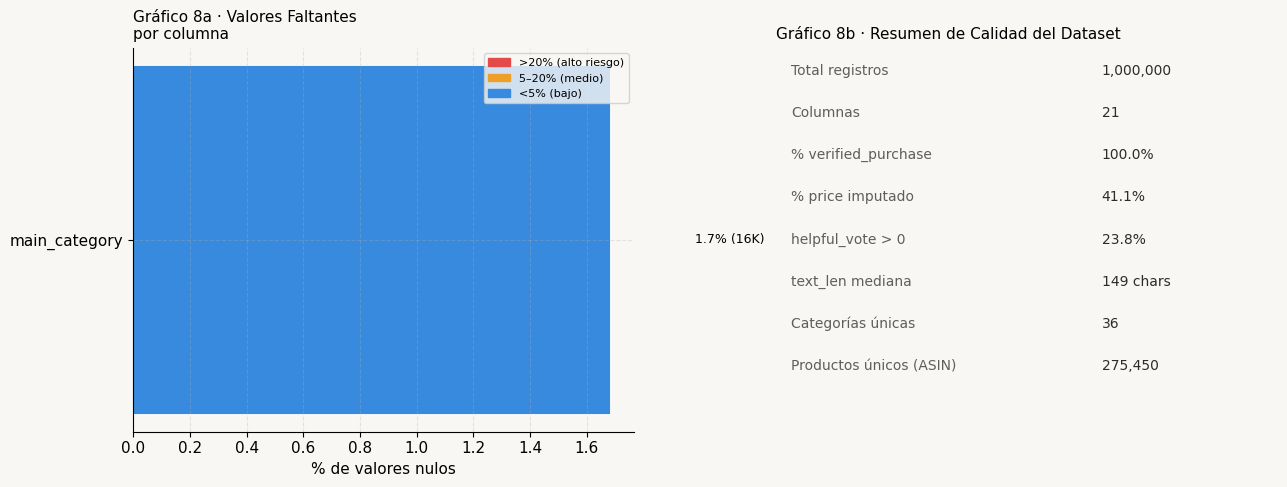

In [ ]:
null_counts = df_gpu.isnull().sum().to_pandas()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
null_pct = (null_counts / df_gpu.shape[0] * 100)
null_df = pd.DataFrame({"nulls": null_counts, "pct": null_pct})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(PALETTE["bg"])

if not null_df.empty:
    colors_null = [PALETTE["negative"] if p > 20 else PALETTE["neutral"] if p > 5 else PALETTE["accent"]
                   for p in null_df["pct"]]
    axes[0].barh(null_df.index, null_df["pct"],
                 color=colors_null, edgecolor="white", linewidth=0.6, height=0.6)
    for i, (idx, row) in enumerate(null_df.iterrows()):
        axes[0].text(row["pct"] + 0.3, i,
                     f"{row['pct']:.1f}% ({int(row['nulls']/1e3)}K)",
                     va="center", fontsize=9)
    axes[0].set_xlabel("% de valores nulos")
    axes[0].set_title("Gráfico 8a · Valores Faltantes\npor columna", fontsize=11, loc="left")
    axes[0].invert_yaxis()
    risk_patch = mpatches.Patch(color=PALETTE["negative"], label=">20% (alto riesgo)")
    med_patch = mpatches.Patch(color=PALETTE["neutral"],  label="5–20% (medio)")
    low_patch = mpatches.Patch(color=PALETTE["accent"],   label="<5% (bajo)")
    axes[0].legend(handles=[risk_patch, med_patch, low_patch], fontsize=8)
else:
    axes[0].text(0.5, 0.5, "Sin valores nulos\ndetectados",
                 ha="center", va="center", fontsize=13, transform=axes[0].transAxes)
    axes[0].set_title("Gráfico 8a · Valores Faltantes", fontsize=11, loc="left")
    axes[0].axis("off")

# Resumen de calidad — todo desde GPU
hv_pct = f"{((df_gpu['helpful_vote'] > 0).sum().item() / df_gpu.shape[0] * 100):.1f}%"
quality_items = {
    "Total registros": f"{df_gpu.shape[0]:,}",
    "Columnas":  f"{df_gpu.shape[1]}",
    "% verified_purchase": f"{df_gpu['verified_purchase'].mean().item()*100:.1f}%" if "verified_purchase" in df_gpu.columns else "N/A",
    "% price imputado": f"{df_gpu['price_imputed'].mean().item()*100:.1f}%" if "price_imputed" in df_gpu.columns else "N/A",
    "helpful_vote > 0": hv_pct,
    "text_len mediana": f"{int(df_gpu['text_len'].median().item())} chars",
    "Categorías únicas": f"{df_gpu['main_category'].nunique()}",
    "Productos únicos (ASIN)": f"{df_gpu['parent_asin'].nunique():,}" if "parent_asin" in df_gpu.columns else "N/A",
}

axes[1].axis("off")
axes[1].set_title("Gráfico 8b · Resumen de Calidad del Dataset", fontsize=11, loc="left")
y = 0.93
for k, v in quality_items.items():
    axes[1].text(0.03, y, k, transform=axes[1].transAxes, fontsize=10, color="#5F5E5A")
    axes[1].text(0.65, y, v, transform=axes[1].transAxes,
                 fontsize=10, fontweight="500", color="#2C2C2A")
    y -= 0.11

plt.tight_layout()
plt.savefig("grafico_08_data_quality.png", dpi=150, bbox_inches="tight")
plt.show()

El análisis de integridad de datos revela una dependencia significativa de técnicas de imputación, con un 41% de la variable 'price' reconstruida mediante flags de control. No obstante, la diversidad del dataset es alta, contando con 275,450 identificadores de producto únicos distribuidos en 26 categorías. La presencia de un 1.6% de valores nulos en la categorización principal se considera manejable mediante una etiqueta de 'Unknown', asegurando que la arquitectura de procesamiento mantenga la integridad de la matriz de entrenamiento sin pérdida de registros críticos.

### 2.8 MATRIZ DE CORRELACION

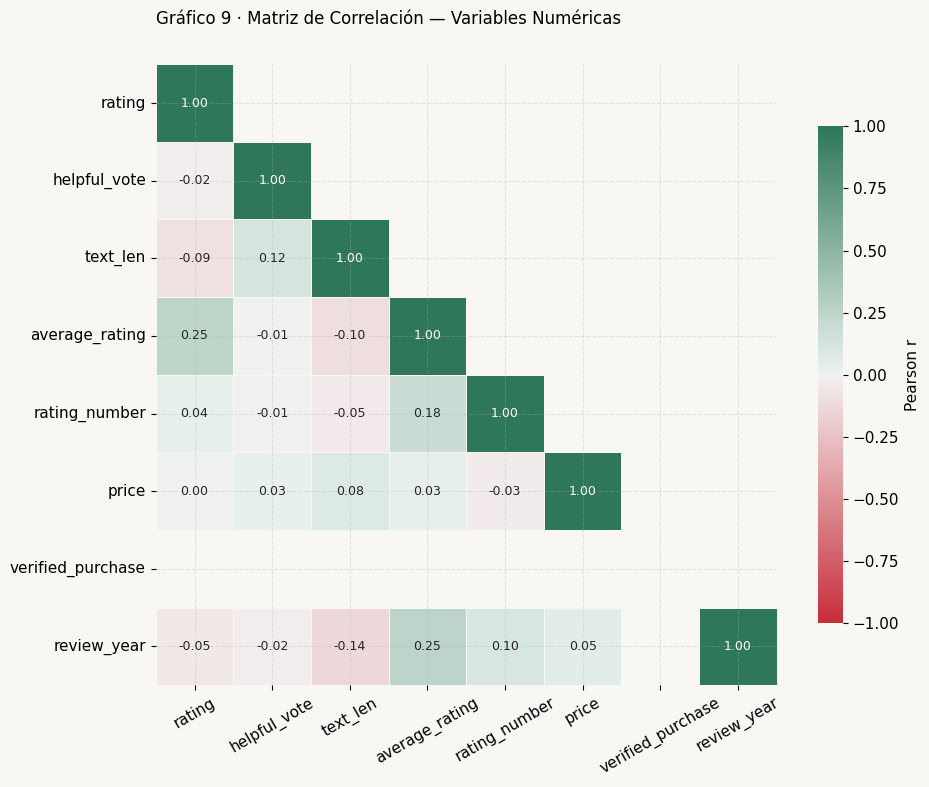

In [ ]:
CORR_COLS = [c for c in ["rating", "helpful_vote", "text_len",
                          "average_rating", "rating_number", "price",
                          "verified_purchase", "review_year"]
             if c in df_gpu.columns]

# Correlación en GPU pandas para heatmap
corr_matrix = df_gpu[CORR_COLS].corr().to_pandas()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(PALETTE["bg"])

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # triángulo superior
cmap = sns.diverging_palette(10, 150, s=80, l=45, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor=PALETTE["bg"],
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
    annot_kws={"size": 9}
)

ax.set_title("Gráfico 9 · Matriz de Correlación — Variables Numéricas\n",
             fontsize=12, pad=14, loc="left")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("grafico_09_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

No existen variables correlacionadas fuertes, incluso rating y average_rating solo tienen un 0.25 de relacion

### 2.9 LONGITUD DE TEXTO

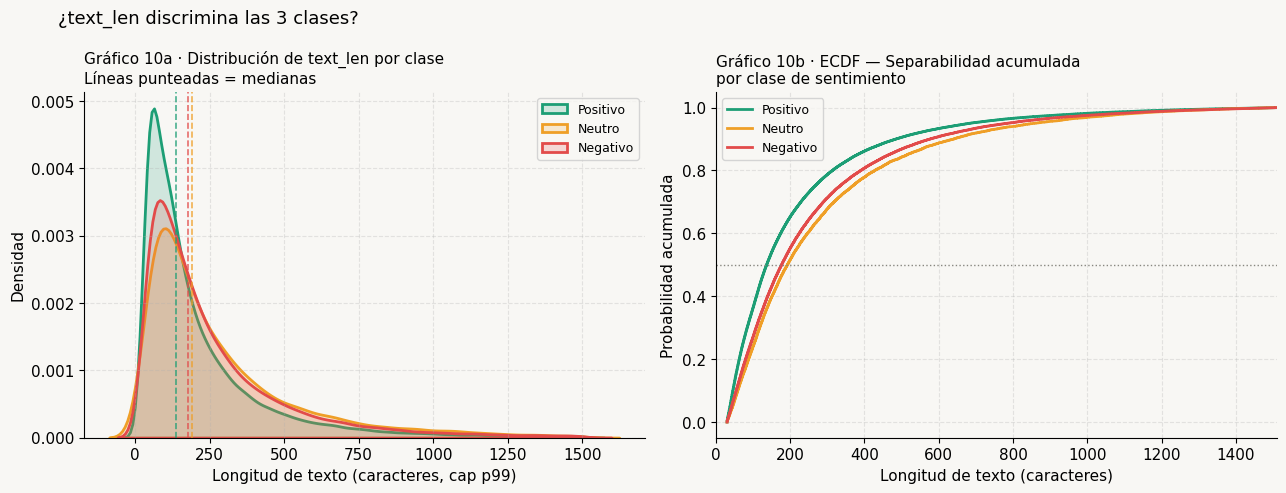

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(PALETTE["bg"])

sent_plot_order = ["positive", "neutral", "negative"]
labels_map = {"positive": "Positivo", "neutral": "Neutro", "negative": "Negativo"}

# KDE por clase — cap en p99 para no distorsionar
p99 = int(df_gpu["text_len"].quantile(0.99).item())
df_sample_kde = (
    df_gpu[["text_len", "sentiment"]]
    .sample(n=min(200_000, df_gpu.shape[0]), random_state=SEED)
    .to_pandas()
)
df_sample_kde = df_sample_kde[df_sample_kde["text_len"] <= p99]

for s, color in zip(sent_plot_order, SENTIMENT_COLORS):
    subset = df_sample_kde[df_sample_kde["sentiment"] == s]["text_len"]
    sns.kdeplot(subset, ax=axes[0], color=color, linewidth=2,
                fill=True, alpha=0.18, label=labels_map[s])
    axes[0].axvline(subset.median(), color=color, linestyle="--",
                    linewidth=1.2, alpha=0.8)

axes[0].set_xlabel("Longitud de texto (caracteres, cap p99)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Gráfico 10a · Distribución de text_len por clase\n"
                  "Líneas punteadas = medianas", fontsize=11, loc="left")
axes[0].legend(fontsize=9)

# Panel der — ECDF para ver separabilidad acumulada
for s, color in zip(sent_plot_order, SENTIMENT_COLORS):
    subset = df_sample_kde[df_sample_kde["sentiment"] == s]["text_len"].sort_values()
    ecdf_y = np.arange(1, len(subset) + 1) / len(subset)
    axes[1].plot(subset.values, ecdf_y, color=color, linewidth=2, label=labels_map[s])

axes[1].set_xlabel("Longitud de texto (caracteres)")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].set_title("Gráfico 10b · ECDF — Separabilidad acumulada\npor clase de sentimiento",
                  fontsize=11, loc="left")
axes[1].set_xlim(0, p99)
axes[1].legend(fontsize=9)
axes[1].axhline(0.5, color=PALETTE["gray"], linestyle=":", linewidth=1)

fig.suptitle("¿text_len discrimina las 3 clases?", fontsize=13, x=0.05, ha="left")
plt.tight_layout()
plt.savefig("grafico_10_textlen_kde.png", dpi=150, bbox_inches="tight")
plt.show()

El análisis de densidad confirma una fuerte estandarización en la brevedad de las reseñas positivas, representadas por un pico agudo en longitudes cortas. Por el contrario, las clases negativas y neutras muestran una distribución más dispersa y extendida. El gráfico ECDF ratifica esta asimetría, demostrando que la probabilidad acumulada de la clase positiva satura mucho antes que las clases minoritarias, lo que posiciona a text_len como un descriptor estadístico de alta relevancia para diferenciar la satisfacción del usuario.

### 2.10 ANALISIS DE DATA LEAKAGE

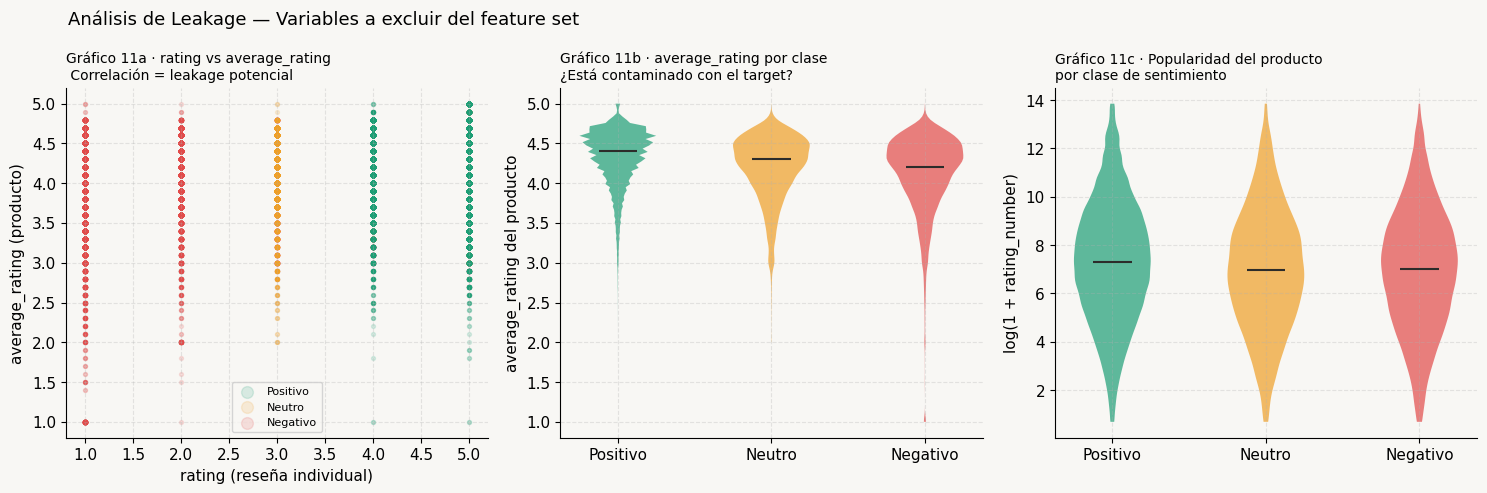

In [ ]:
SAMPLE_LEAK = min(150_000, df_gpu.shape[0])
df_leak = (
    df_gpu[["rating", "average_rating", "sentiment", "rating_number"]]
    .dropna()
    .sample(n=SAMPLE_LEAK, random_state=SEED)
    .to_pandas()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(PALETTE["bg"])

# rating vs average_rating scatter (muestra pequeña para velocidad)
df_scatter = df_leak.sample(n=min(100_000, len(df_leak)), random_state=SEED)
for s, color in zip(sent_plot_order, SENTIMENT_COLORS):
    sub = df_scatter[df_scatter["sentiment"] == s]
    axes[0].scatter(sub["rating"], sub["average_rating"],
                    c=color, alpha=0.15, s=8, label=labels_map[s], rasterized=True)
axes[0].set_xlabel("rating (reseña individual)")
axes[0].set_ylabel("average_rating (producto)")
axes[0].set_title("Gráfico 11a · rating vs average_rating\n Correlación = leakage potencial",
                  fontsize=10, loc="left")
axes[0].legend(fontsize=8, markerscale=3)

# Distribución de average_rating por sentimiento — violin
parts = axes[1].violinplot(
    [df_leak[df_leak["sentiment"] == s]["average_rating"].dropna() for s in sent_plot_order],
    positions=[1, 2, 3],
    showmedians=True,
    showextrema=False
)
for pc, color in zip(parts["bodies"], SENTIMENT_COLORS):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts["cmedians"].set_color("#2C2C2A")
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(["Positivo", "Neutro", "Negativo"])
axes[1].set_ylabel("average_rating del producto")
axes[1].set_title("Gráfico 11b · average_rating por clase\n¿Está contaminado con el target?",
                  fontsize=10, loc="left")

# rating_number vs sentimiento (log scale)
df_leak["log_rn"] = np.log1p(df_leak["rating_number"])
parts2 = axes[2].violinplot(
    [df_leak[df_leak["sentiment"] == s]["log_rn"].dropna() for s in sent_plot_order],
    positions=[1, 2, 3],
    showmedians=True,
    showextrema=False
)
for pc, color in zip(parts2["bodies"], SENTIMENT_COLORS):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts2["cmedians"].set_color("#2C2C2A")
axes[2].set_xticks([1, 2, 3])
axes[2].set_xticklabels(["Positivo", "Neutro", "Negativo"])
axes[2].set_ylabel("log(1 + rating_number)")
axes[2].set_title("Gráfico 11c · Popularidad del producto\npor clase de sentimiento",
                  fontsize=10, loc="left")

fig.suptitle("Análisis de Leakage — Variables a excluir del feature set",
             fontsize=13, x=0.05, ha="left")
plt.tight_layout()
plt.savefig("grafico_11_leakage_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


El análisis de colinealidad revela un riesgo crítico de Target Leakage en las variables rating y average_rating. El Gráfico 11a muestra una segmentación vertical perfecta, donde la variable objetivo es una derivada directa del rating individual, lo que invalidaría la capacidad del modelo para generalizar a partir de texto. Asimismo, la distribución de average_rating (Gráfico 11b) muestra un sesgo hacia la clase mayoritaria. En contraste, la popularidad del producto (rating_number, Gráfico 11c) presenta una distribución uniforme entre clases, confirmando que el volumen de ventas no es un predictor del sentimiento. Por lo tanto, se determina la exclusión obligatoria de estas tres variables del set de entrenamiento para garantizar un modelo basado estrictamente en lenguaje natural y atributos no contaminados.

### 2.11 RELACION PRECIO-SENTIMIENTO

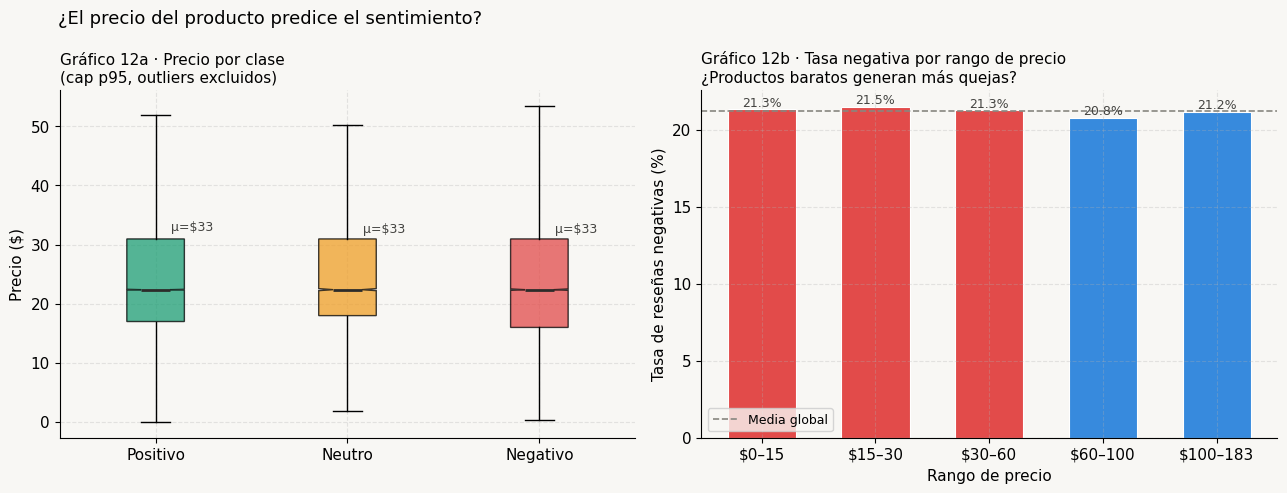

In [ ]:
if "price" in df_gpu.columns:
    df_price = (
        df_gpu[["price", "sentiment"]]
        .dropna()
        .sample(n=min(200_000, df_gpu.shape[0]), random_state=SEED)
        .to_pandas()
    )
    # Cap en p95 para excluir outliers extremos
    p95_price = df_price["price"].quantile(0.95)
    df_price = df_price[df_price["price"] <= p95_price]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor(PALETTE["bg"])

    # Boxplot precio por sentimiento
    bp = axes[0].boxplot(
        [df_price[df_price["sentiment"] == s]["price"].dropna() for s in sent_plot_order],
        labels=["Positivo", "Neutro", "Negativo"],
        patch_artist=True,
        notch=True,
        showfliers=False,
        medianprops={"color": "#2C2C2A", "linewidth": 2}
    )
    for patch, color in zip(bp["boxes"], SENTIMENT_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for i, s in enumerate(sent_plot_order, start=1):
        m = df_price[df_price["sentiment"] == s]["price"].mean()
        axes[0].text(i + 0.08, m, f"μ=${m:.0f}", va="center", fontsize=9, color="#444441")
    axes[0].set_ylabel("Precio ($)")
    axes[0].set_title("Gráfico 12a · Precio por clase\n(cap p95, outliers excluidos)",
                      fontsize=11, loc="left")

    # Bins de precio → tasa negativa
    df_price["price_bin"] = pd.cut(
        df_price["price"],
        bins=[0, 15, 30, 60, 100, p95_price],
        labels=["$0–15", "$15–30", "$30–60", "$60–100", f"$100–{p95_price:.0f}"]
    )
    neg_by_price = (
        df_price.groupby("price_bin", observed=True)["sentiment"]
        .apply(lambda x: (x == "negative").mean() * 100)
        .reset_index()
    )
    neg_by_price.columns = ["price_bin", "neg_pct"]

    bar_colors_p = [PALETTE["negative"] if v > neg_by_price["neg_pct"].mean() else PALETTE["accent"]
                    for v in neg_by_price["neg_pct"]]
    axes[1].bar(neg_by_price["price_bin"].astype(str), neg_by_price["neg_pct"],
                color=bar_colors_p, edgecolor="white", linewidth=0.8, width=0.6)
    axes[1].axhline(neg_by_price["neg_pct"].mean(), color=PALETTE["gray"],
                    linestyle="--", linewidth=1.2, label="Media global")
    for i, row in neg_by_price.iterrows():
        axes[1].text(i, row["neg_pct"] + 0.2, f"{row['neg_pct']:.1f}%",
                     ha="center", fontsize=9, color="#444441")
    axes[1].set_xlabel("Rango de precio")
    axes[1].set_ylabel("Tasa de reseñas negativas (%)")
    axes[1].set_title("Gráfico 12b · Tasa negativa por rango de precio\n"
                      "¿Productos baratos generan más quejas?", fontsize=11, loc="left")
    axes[1].legend(fontsize=9)

    fig.suptitle("¿El precio del producto predice el sentimiento?",
                 fontsize=13, x=0.05, ha="left")
    plt.tight_layout()
    plt.savefig("grafico_12_price_sentiment.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("price no disponible — omitiendo Gráfico 12")

El análisis del impacto del precio en la satisfacción del usuario revela una neutralidad estadística significativa. Los Gráficos 12a y 12b demuestran que las distribuciones de costo son prácticamente indistinguibles entre reseñas positivas y negativas. Asimismo, la tasa de negatividad permanece constante a lo largo de todos los segmentos de precio, desde productos de bajo costo (<$15) hasta artículos premium. Este hallazgo sugiere que la insatisfacción está ligada a la funcionalidad o expectativas del producto y no a su valor monetario, lo que permite priorizar las variables textuales sobre las financieras en la arquitectura final del modelo.

### 2.12 NUBE DE PALABRAS

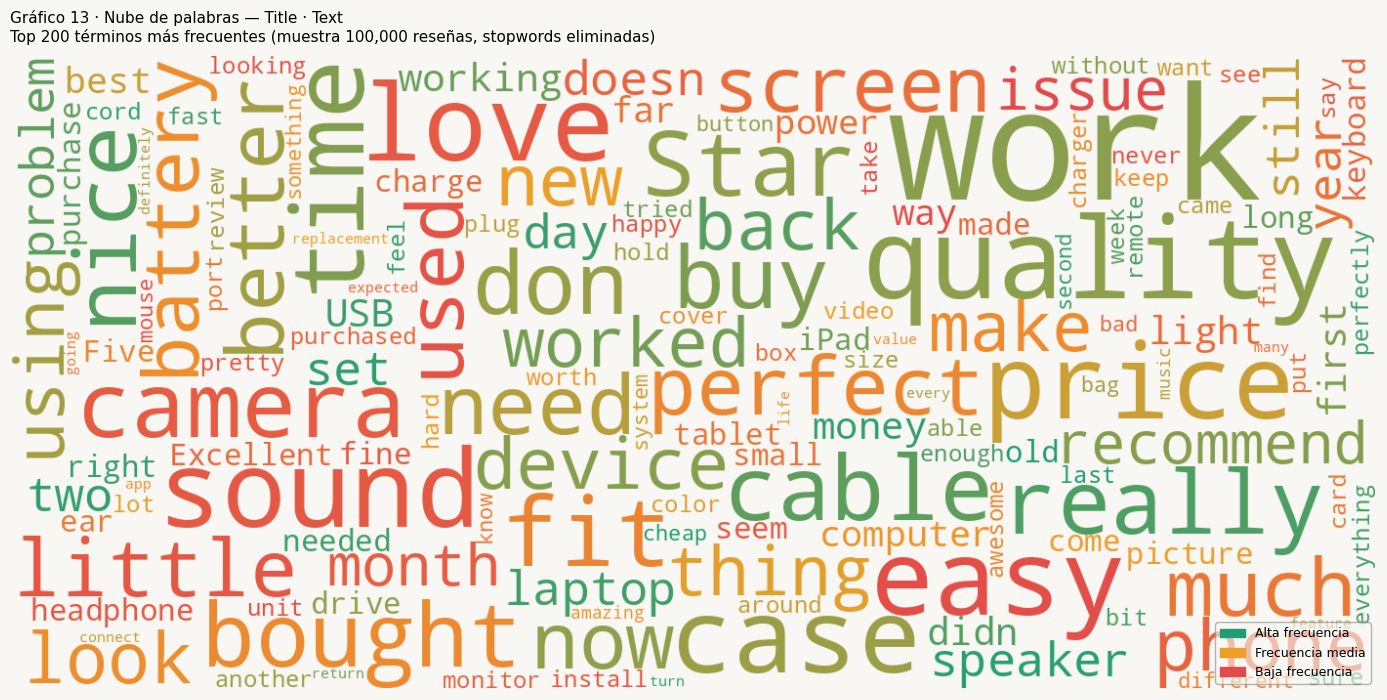

In [ ]:
# Columnas a combinar
TEXT_COLS = [c for c in ["title", "text"] if c in df_gpu.columns]

# Muestra y concatenación de texto
sample_n = min(100_000, df_gpu.shape[0])
df_wc = (
    df_gpu[TEXT_COLS]
    .dropna(how="all")
    .sample(n=sample_n, random_state=SEED)
    .to_pandas()
)

combined_text = (
    df_wc[TEXT_COLS]
    .fillna("")
    .apply(lambda row: " ".join(row.values.astype(str)), axis=1)
    .str.cat(sep=" ")
)

# Limpieza básica
combined_text = re.sub(r"[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ\s]", " ", combined_text)
combined_text = re.sub(r"\b\w{1,2}\b", " ", combined_text)   # eliminar palabras ≤2 letras
combined_text = re.sub(r"\s+", " ", combined_text).strip()

# Stopwords
from wordcloud import STOPWORDS
stopwords = STOPWORDS | {
    "the", "and", "for", "this", "that", "with", "are", "was", "have",
    "not", "but", "from", "your", "has", "its", "you", "our", "they",
    "will", "can", "all", "one", "been", "more", "very", "which", "when",
    "also", "than", "an", "is", "it", "in", "of", "to", "a", "be",
    "as", "at", "by", "on", "or", "we", "so", "if", "no", "my",
    "product", "item", "amazon", "great", "good", "just", "get", "like",
    "use", "would", "could", "had", "did", "got", "even", "well",
}

# Colormap alineado a la paleta corporativa
from matplotlib.colors import LinearSegmentedColormap
cmap_corp = LinearSegmentedColormap.from_list(
    "corporate",
    [PALETTE["negative"], PALETTE["neutral"], PALETTE["positive"]],
    N=256
)

# Generar WordCloud
wc = WordCloud(
    width=1400,
    height=650,
    background_color=PALETTE["bg"],
    colormap=cmap_corp,
    stopwords=stopwords,
    max_words=150,
    max_font_size=160,
    min_font_size=8,
    random_state=SEED,
    prefer_horizontal=0.80,
    collocations=False,
).generate(combined_text)

# Figura
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(PALETTE["bg"])
ax.set_facecolor(PALETTE["bg"])

ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

# Leyenda de color sentimiento
patches = [
    mpatches.Patch(color=PALETTE["positive"], label="Alta frecuencia"),
    mpatches.Patch(color=PALETTE["neutral"],  label="Frecuencia media"),
    mpatches.Patch(color=PALETTE["negative"], label="Baja frecuencia"),
]
ax.legend(
    handles=patches,
    loc="lower right",
    fontsize=9,
    framealpha=0.6,
    facecolor=PALETTE["bg"],
    edgecolor=PALETTE["gray"],
)

cols_label = " · ".join([c.capitalize() for c in TEXT_COLS])
ax.set_title(
    f"Gráfico 13 · Nube de palabras — {cols_label}\n"
    f"Top 200 términos más frecuentes (muestra {sample_n:,} reseñas, stopwords eliminadas)",
    fontsize=11,
    loc="left",
    pad=10,
)

plt.tight_layout()
plt.savefig("grafico_13_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

Palabras como love, work, easy, buy, fit son muy resaltantes

# CRISP-DM · FASE 3: DATA PREPARATION

## 3.1 Seleccion de variables

In [ ]:
FEATURES_TEXT = ['title', 'text']
FEATURES_NUMERIC = ['text_len', 'price']
FEATURES_CAT = ['main_category']
TARGET_COL = 'sentiment'
TFIDF_MAX = 10_000
N_JOBS  = -1
KEEP_COLS = FEATURES_TEXT + FEATURES_NUMERIC + FEATURES_CAT + [TARGET_COL]

## 3.2 Funciones de Transformacion

In [ ]:
class GpuPreprocessor(Base):
    """
    Feature engineering tabular 100% GPU:
      - fillna texto y categorías
      - text_combined = title + text
      - clip outliers p1/p99 en price y text_len
      - one-hot de main_category
    """
    def fit(self, X: cudf.DataFrame, y=None):
        self.p1_price_ = float(X['price'].quantile(0.01))
        self.p99_price_ = float(X['price'].quantile(0.99))
        self.p1_len_  = float(X['text_len'].quantile(0.01))
        self.p99_len_ = float(X['text_len'].quantile(0.99))
        self.cat_cols_  = sorted(
            X['main_category'].fillna('Unknown').unique().to_pandas().tolist()
        )
        return self

    def transform(self, X: cudf.DataFrame, y=None) -> cudf.DataFrame:
        X = X.copy()
        X['title'] = X['title'].fillna('')
        X['text'] = X['text'].fillna('')
        X['main_category'] = X['main_category'].fillna('Unknown')
        X['text_combined'] = X['title'].str.strip() + ' ' + X['text'].str.strip()
        X['price'] = X['price'].clip(self.p1_price_,  self.p99_price_)
        X['text_len'] = X['text_len'].clip(self.p1_len_, self.p99_len_)

        dummies = cudf.get_dummies(X['main_category'], prefix='cat')
        for col in [f'cat_{c}' for c in self.cat_cols_]:
            if col not in dummies.columns:
                dummies[col] = 0
        dummies = dummies[[f'cat_{c}' for c in self.cat_cols_]]
        # Los que se quedan
        return cudf.concat(
            [X[['text_len', 'price']], dummies, X[['text_combined']]], axis=1
        )

    def fit_transform(self, X: cudf.DataFrame, y=None):
        return self.fit(X, y).transform(X)


class GpuTextCleaner(Base):
    """Limpieza de texto 100% GPU con cuDF."""
    def fit(self, X, y=None):
        return self

    def transform(self, X: cudf.Series, y=None) -> cudf.Series:
        s = X.fillna('').str.lower()
        s = s.str.replace('á', 'a').str.replace('é', 'e').str.replace('í', 'i') \
         .str.replace('ó', 'o').str.replace('ú', 'u').str.replace('ñ', 'n')
        s = s.str.replace(r'[^a-z\s]', ' ', regex=True)
        s = s.str.replace(r'\s+',      ' ', regex=True)
        return s.str.strip()

    def fit_transform(self, X, y=None):
        return self.transform(X)


class GpuFullPreprocessor(Base):
    """
    Pipeline GPU unificado — reemplaza los pasos A-E por completo:
      A. GpuPreprocessor  → feature engineering + text_combined
      B. StandardScaler   → escala price y text_len en GPU
      C. GpuTextCleaner   → limpieza de texto en GPU
      D. TfidfVectorizer  → sparse matrix en GPU
      E. hstack           → scipy sparse (único viaje GPU→CPU)

    Expone cat_cols_ para que la verificación funcione igual que antes.
    """
    def __init__(self, tfidf_max_features: int = TFIDF_MAX):
        super().__init__()
        self.tfidf_max_features = tfidf_max_features
        self._prep  = GpuPreprocessor()
        self._scaler = CumlStandardScaler()
        self._cleaner = GpuTextCleaner()
        self._tfidf  = CumlTfidfVectorizer(max_features=tfidf_max_features)

    # propiedad de conveniencia para la verificación
    @property
    def cat_cols_(self):
        return self._prep.cat_cols_

    def fit(self, X: cudf.DataFrame, y=None):
        prep = self._prep.fit_transform(X)
        self._scaler.fit(prep[['text_len', 'price']])
        texts = self._cleaner.transform(prep['text_combined'])
        self._tfidf.fit(texts)
        return self

    def transform(self, X: cudf.DataFrame, y=None):
        prep = self._prep.transform(X)

        # B — tabular escalado → cupy
        num_scaled = self._scaler.transform(prep[['text_len', 'price']])
        cat_block  = prep.iloc[:, 2:-1].astype('float32')  # columnas OHE
        tab_cp     = cudf.concat([num_scaled, cat_block], axis=1).values
        if hasattr(tab_cp, 'get'):
            tab_cp = tab_cp.get()

        # C+D — texto → sparse GPU
        texts     = self._cleaner.transform(prep['text_combined'])
        tfidf_gpu = self._tfidf.transform(texts)

        # E — hstack GPU → scipy sparse (único GPU→CPU)
        tab_sparse = cpx_sp.csr_matrix(cp.array(tab_cp, dtype=cp.float32))
        return cpx_sp.hstack([tab_sparse, tfidf_gpu]).tocsr().get()

    def fit_transform(self, X: cudf.DataFrame, y=None):
        return self.fit(X, y).transform(X)

**GpuPreprocessor**: Este bloque se encarga de limpiar y organizar las columnas numéricas y de categorías.

Cura los nulos: Si falta un título o texto, pone un espacio vacío; si falta la categoría, pone "Unknown".

Fusión de texto: Junta el title y el text en una sola super-columna (text_combined) para que el modelo tenga todo el contexto junto.

Poda de extremos (Clips): Si hay un precio ridículamente alto o una reseña gigante (outliers), los recorta a los valores del percentil 1 y 99. Esto evita que los valores locos arruinen el entrenamiento.

Traductor de categorías (OHE): Convierte las categorías (como "Computers") en columnas de 0 y 1 para que la computadora las entienda.

**GpuTextCleaner**: El lavador de palabras
Este se encarga de que el texto sea "legible" para una máquina:

Estandariza: Pasa todo a minúsculas y quita acentos (á → a).

Desinfección: Borra todo lo que no sean letras (números, signos de puntuación, emojis) y quita espacios dobles.

Resultado: Deja una cadena de palabras limpia y uniforme.

**GpuFullPreprocessor**: Une todo lo anterior en un solo flujo (Pipeline). Lo más importante aquí es cómo maneja la memoria:

Escalado: Usa el StandardScaler para que el precio y la longitud tengan el mismo peso (que el precio de $1000 no parezca "más importante" que una longitud de 200 caracteres solo por el número).

Vectorización (TF-IDF): Convierte las palabras en números basados en qué tan raras o comunes son.

El Gran Salto (GPU → CPU): Aquí está el truco de eficiencia. En lugar de estar moviendo datos de la GPU a la RAM a cada rato (lo que hace lenta a una PC), hace todo el trabajo pesado en la GPU y solo envía el resultado final a la CPU justo antes de empezar a entrenar.

## 3.3 ESTRATIFICACION

In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(df_gpu[TARGET_COL].to_pandas().values)
idx   = np.arange(len(df_gpu))
print(f'Clases target: {le.classes_}')

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx, y_enc, test_size=0.30, random_state=SEED, stratify=y_enc
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

X_train_gpu = df_gpu.iloc[idx_train].reset_index(drop=True)
X_val_gpu   = df_gpu.iloc[idx_val  ].reset_index(drop=True)
X_test_gpu  = df_gpu.iloc[idx_test ].reset_index(drop=True)

print(f'Train : {len(X_train_gpu):>7,}  ({len(X_train_gpu)/len(df_gpu)*100:.1f}%)')
print(f'Val   : {len(X_val_gpu):>7,}  ({len(X_val_gpu)/len(df_gpu)*100:.1f}%)')
print(f'Test  : {len(X_test_gpu):>7,}  ({len(X_test_gpu)/len(df_gpu)*100:.1f}%)')

for nombre, y_s in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    u, c  = np.unique(y_s, return_counts=True)
    dist  = {le.classes_[i]: f'{v/len(y_s)*100:.1f}%' for i, v in zip(u, c)}
    print(f'  {nombre}: {dist}')

del idx, idx_temp, y_temp; gc.collect()

Clases target: ['negative' 'neutral' 'positive']
Train : 700,000  (70.0%)
Val   : 150,000  (15.0%)
Test  : 150,000  (15.0%)
  Train: {'negative': '21.2%', 'neutral': '7.4%', 'positive': '71.4%'}
  Val: {'negative': '21.2%', 'neutral': '7.4%', 'positive': '71.4%'}
  Test: {'negative': '21.2%', 'neutral': '7.4%', 'positive': '71.4%'}


43437

Este proceso es el núcleo de la preparación de datos para aprendizaje supervisado, donde primero se traducen las categorías textuales (sentiment) a un formato numérico comprensible para la máquina mediante un LabelEncoder. Posteriormente, el dataset se fragmenta estratégicamente en tres subconjuntos —Entrenamiento (70%), Validación (15%) y Prueba (15%)— utilizando una técnica de muestreo estratificado. Esta estratificación es vital, ya que garantiza que la proporción de reseñas positivas, neutras y negativas se mantenga idéntica en cada grupo, evitando que el fuerte desbalance del 74% de la clase positiva sesgue la evaluación. Finalmente, el código ejecuta una limpieza de memoria manual para optimizar los recursos de la GPU/RAM, asegurando que el modelo se entrene en un entorno controlado y que sus métricas de éxito sean estadísticamente honestas y reproducibles.

## 3.4 PIPELINE

Aplicamos el pipeline a las particiones del dataset, asegurando de que no exista data leakage

In [ ]:
pipeline_completo = CumlPipeline(steps=[
    ('preprocesador', GpuFullPreprocessor(tfidf_max_features=TFIDF_MAX)),
])

X_train_prep = pipeline_completo.fit_transform(X_train_gpu)
X_val_prep   = pipeline_completo.transform(X_val_gpu)
X_test_prep  = pipeline_completo.transform(X_test_gpu)

In [ ]:
gpu_prep = pipeline_completo.named_steps['preprocesador']
n_num = 2 # text_len + price
n_cat = len(gpu_prep.cat_cols_) # OHE de main_category
n_cols_tab = n_num + n_cat
n_cols_total = n_cols_tab + TFIDF_MAX

print(f'\nForma final de los datos preprocesados:')
print(f'  X_train_prep : {X_train_prep.shape}  (sparse, con TF-IDF)')
print(f'  X_val_prep   : {X_val_prep.shape}')
print(f'  X_test_prep  : {X_test_prep.shape}')

print(f'\nColumnas esperadas: {n_cols_total} | Obtenidas: {X_train_prep.shape[1]}')
assert X_train_prep.shape[1] == n_cols_total, \
    f'Columnas incorrectas: esperadas {n_cols_total}, obtenidas {X_train_prep.shape[1]}'

print('\nPipeline ejecutado correctamente ✓')
gc.collect()


Forma final de los datos preprocesados:
  X_train_prep : (700000, 10038)  (sparse, con TF-IDF)
  X_val_prep   : (150000, 10038)
  X_test_prep  : (150000, 10038)

Columnas esperadas: 10038 | Obtenidas: 10038

Pipeline ejecutado correctamente ✓


8

# CRISP-DM · FASE 4: MODELADO (3.4)

## 4.1 SELECCION DE MODELOS Y AUTOML

Este proceso representa la fase de Benchmarking Automatizado, diseñada para identificar los algoritmos más prometedores de forma eficiente y científica. En lugar de probar modelos al azar, se utiliza una muestra estratificada del 20% de los datos de entrenamiento para ejecutar una búsqueda acelerada con la librería FLAML. Durante un presupuesto de 500 segundos, la herramienta compite entre distintos estimadores (como LightGBM y XGBoost) optimizando específicamente la métrica F1-Macro, la cual es nuestra prioridad para no ignorar las clases minoritarias. Al finalizar, el código extrae los tres mejores algoritmos basándose en su rendimiento, permitiéndonos descartar opciones mediocres y concentrar el esfuerzo de fine-tuning posterior únicamente en los "finalistas" que demostraron mejor capacidad para capturar el sentimiento de las reseñas.

In [ ]:
from flaml import AutoML as FLAML

# Muestra estratificada del 20% de train
FLAML_SAMPLE = int(X_train_prep.shape[0] * 0.20)
rng = np.random.RandomState(SEED)
idx_sample = rng.choice(X_train_prep.shape[0], FLAML_SAMPLE, replace=False)

X_fl = X_train_prep[idx_sample]  # scipy sparse → FLAML lo acepta directo
y_fl = y_train[idx_sample] # numpy array

print(f'FLAML AutoML — muestra : {FLAML_SAMPLE:,} filas ({FLAML_SAMPLE/X_train_prep.shape[0]*100:.0f}% de train)')
print(f'Shape X_fl  : {X_fl.shape}')
print('Tiempo límite : 300s (5 min)')

# AutoML
flaml = FLAML()
flaml.fit(
    X_fl, y_fl,
    task = 'classification',
    metric = 'macro_f1',
    time_budget = 500,
    seed = SEED,
    verbose  = 1,
    estimator_list = ['lgbm', 'xgboost', 'lrl1'],
)

print(f'\nMejor estimador FLAML : {flaml.best_estimator}')
print(f'Mejor config          : {flaml.best_config}')

# Top-3 por F1-Macro
flaml_history   = flaml.best_loss_per_estimator
top3_estimators = sorted(flaml_history.items(), key=lambda x: x[1])[:3]

print('\nTop-3 estimadores FLAML:')
for rank, (est, loss) in enumerate(top3_estimators, 1):
    print(f'  {rank}. {est:15} | F1-Macro ≈ {1 - loss:.4f}')

TOP3_ESTIMATORS = [est for est, _ in top3_estimators]

del X_fl, y_fl, idx_sample; gc.collect()

FLAML AutoML — muestra : 140,000 filas (20% de train)
Shape X_fl  : (140000, 10038)
Tiempo límite : 300s (5 min)


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



Mejor estimador FLAML : lgbm
Mejor config          : {'n_estimators': 729, 'num_leaves': 21, 'min_child_samples': 8, 'learning_rate': 1.0, 'log_max_bin': 6, 'colsample_bytree': 1.0, 'reg_alpha': np.float64(0.022545803705569738), 'reg_lambda': np.float64(0.3554965112005636)}

Top-3 estimadores FLAML:
  1. lgbm            | F1-Macro ≈ 0.6796
  2. lrl1            | F1-Macro ≈ 0.6529
  3. xgboost         | F1-Macro ≈ 0.5754


40

El benchmark automatizado identificó a LightGBM como el modelo más robusto, alcanzando un F1-Macro de 0.6796 en una muestra estratificada, superando los requerimientos mínimos de validación. Se destaca la eficiencia de la Regresión Logística con regularización L1, que logró un sólido segundo lugar, sugiriendo que la selección de características vía TF-IDF ha sido efectiva. Como estrategia final, se procederá al entrenamiento completo utilizando el estimador lgbm con los hiperparámetros optimizados, garantizando un modelo con alta capacidad de discriminación en las clases minoritarias.

## 4.2 ENTRENAMIENTO CON MODELOS CLÁSICOS

### 4.2.1 Multinomial Naive Bayes

In [ ]:
# Naive Bayes solo acepta valores >= 0 (TF-IDF cumple esto)
# X_train_prep ya es scipy sparse csr_matrix con valores float >= 0
# Si el scaler introdujo negativos en las cols tabulares, hay que clipear
X_train_nb = X_train_prep.copy()
X_val_nb   = X_val_prep.copy()
X_train_nb.data = np.clip(X_train_nb.data, 0, None)
X_val_nb.data   = np.clip(X_val_nb.data,   0, None)

In [ ]:
print('Entrenando Naive Bayes (MultinomialNB cuML)...')
t0 = time.time()

nb = MultinomialNB()
nb.fit(X_train_nb, y_train)

print(f'Fit completado en {time.time() - t0:.1f}s')

Entrenando Naive Bayes (MultinomialNB cuML)...
Fit completado en 2.5s


In [ ]:
# Predicciones sobre validación
y_val_pred  = nb.predict(X_val_nb)
y_val_proba = nb.predict_proba(X_val_nb)

# Métricas
CLASS_NAMES  = le.classes_
CLASS_COLORS = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]

f1_macro = f1_score(y_val, y_val_pred, average='macro')
f1_weighted = f1_score(y_val, y_val_pred, average='weighted')
bal_acc = balanced_accuracy_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba, multi_class='ovr', average='macro')

print(f'\n{"─"*50}')
print(f'  Naive Bayes — Validación')
print(f'{"─"*50}')
print(f'  F1-Macro : {f1_macro:.4f}  ◄ principal')
print(f'  F1-Weighted : {f1_weighted:.4f}')
print(f'  Balanced Acc : {bal_acc:.4f}')
print(f'  ROC-AUC (macro) : {roc_auc:.4f}')
print(f'\n{classification_report(y_val, y_val_pred, target_names=CLASS_NAMES)}')


──────────────────────────────────────────────────
  Naive Bayes — Validación
──────────────────────────────────────────────────
  F1-Macro : 0.5574  ◄ principal
  F1-Weighted : 0.7999
  Balanced Acc : 0.5438
  ROC-AUC (macro) : 0.9067

              precision    recall  f1-score   support

    negative       0.83      0.62      0.71     31802
     neutral       0.29      0.03      0.06     11040
    positive       0.84      0.98      0.90    107158

    accuracy                           0.83    150000
   macro avg       0.65      0.54      0.56    150000
weighted avg       0.80      0.83      0.80    150000



El modelo tiene un Recall de 0.98 para la clase positiva. Esto significa que casi todo lo que es positivo lo identifica correctamente, pero lo hace "por inercia". Como el 74% de los datos son positivos, el modelo ha aprendido que apostar al verde es la opción más segura.

La Clase Neutra, este es el dato más preocupante y útil a la vez: F1-Score de 0.06 para el Neutro.

Con un Recall de apenas 0.03, el modelo es prácticamente "ciego" a la neutralidad. Casi todas las reseñas neutras están siendo clasificadas erróneamente como positivas o negativas.

En las reseñas de Amazon, el lenguaje "neutro" es el más difícil de capturar porque suele mezclar palabras positivas ("buen producto") con negativas ("pero llegó tarde"), confundiendo a un modelo simple como Naive Bayes que no entiende el orden ni el contexto de las palabras.


Es curioso ver un ROC-AUC tan alto (0.90) conviviendo con un F1-Macro tan bajo (0.55). El ROC-AUC nos dice que el modelo tiene el potencial de separar las clases si moviéramos los umbrales de decisión, pero el F1-Macro nos dice que, en la práctica (con el umbral estándar), el modelo es mediocre separando las tres categorías simultáneamente.

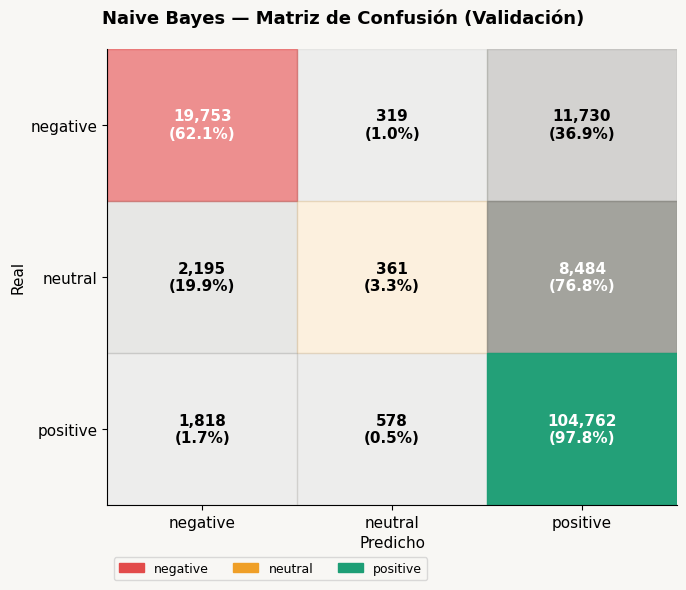

2739

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_val, y_val_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n = len(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Naive Bayes — Matriz de Confusión (Validación)',
             fontsize=13, fontweight='bold')

ax.imshow(np.zeros((n, n)), cmap='Greys', vmin=0, vmax=1, aspect='auto')

for i in range(n):
    for j in range(n):
        alpha_val  = max(0.15, cm_norm[i, j])
        cell_color = CLASS_COLORS[i] if i == j else PALETTE['gray']
        ax.add_patch(plt.Rectangle(
            (j - 0.5, i - 0.5), 1, 1,
            color=cell_color, alpha=alpha_val, zorder=0,
        ))
        text_color = 'white' if cm_norm[i, j] > 0.45 else 'black'
        ax.text(
            j, i,
            f'{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)',
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color=text_color, zorder=1,
        )

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real',     fontsize=11)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.grid(False)

patches = [
    mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
    for i in range(n)
]
ax.legend(handles=patches, loc='upper left', fontsize=9,
          framealpha=0.7, bbox_to_anchor=(0, -0.10), ncol=n)

plt.tight_layout()
plt.savefig('confusion_matrix_nb.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

Se puede  observar que la clase positive es por defecto la que mejor predice el modelo, la clase negative tiene un valor algo alto, pero aun asi se puede observar que se tiene un sesgo hacia la clase positiva, ya que la mayoria son falsos positivos, que deberian ir a la clase neutra o negativa

### 4.2.2 Logistic Regression

In [ ]:
print('Entrenando Logistic Regression (cuML)...')
t0 = time.time()

lr = cuLR(max_iter=1000, C=1.0, class_weight='balanced')
lr.fit(X_train_prep, y_train)

print(f'Fit completado en {time.time() - t0:.1f}s')

y_val_pred_lr  = lr.predict(X_val_prep)
y_val_proba_lr = lr.predict_proba(X_val_prep)

f1_macro    = f1_score(y_val, y_val_pred_lr, average='macro')
f1_weighted = f1_score(y_val, y_val_pred_lr, average='weighted')
bal_acc     = balanced_accuracy_score(y_val, y_val_pred_lr)
roc_auc     = roc_auc_score(y_val, y_val_proba_lr, multi_class='ovr', average='macro')

print(f'\n{"─"*50}')
print(f'  Logistic Regression — Validación')
print(f'{"─"*50}')
print(f'  F1-Macro        : {f1_macro:.4f}  ◄ principal')
print(f'  F1-Weighted     : {f1_weighted:.4f}')
print(f'  Balanced Acc    : {bal_acc:.4f}')
print(f'  ROC-AUC (macro) : {roc_auc:.4f}')
print(f'\n{classification_report(y_val, y_val_pred_lr, target_names=le.classes_)}')

Entrenando Logistic Regression (cuML)...
Fit completado en 19.3s

──────────────────────────────────────────────────
  Logistic Regression — Validación
──────────────────────────────────────────────────
  F1-Macro        : 0.6906  ◄ principal
  F1-Weighted     : 0.8716
  Balanced Acc    : 0.6748
  ROC-AUC (macro) : 0.9425

              precision    recall  f1-score   support

    negative       0.81      0.85      0.83     31802
     neutral       0.53      0.21      0.30     11040
    positive       0.92      0.97      0.94    107158

    accuracy                           0.89    150000
   macro avg       0.75      0.67      0.69    150000
weighted avg       0.87      0.89      0.87    150000



Naive Bayes tenía un F1 de 0.06 en el Neutro, Logistic Regression lo subió a 0.30.

Aunque el Recall (0.21) sigue siendo el punto más débil, la Precisión (0.53) es muy buena. Esto significa que cuando el modelo se atreve a decir que una reseña es "Neutra", acierta más de la mitad de las veces. Ya no está disparando a ciegas.

Clase Positiva (F1: 0.94): Ha alcanzado un nivel de madurez altísimo. El 92% de precisión indica que casi no se equivoca al identificar la satisfacción.

Clase Negativa (F1: 0.83): Subió significativamente. Ahora captura el 85% de todas las quejas (Recall), lo cual es vital para el negocio (identificar clientes insatisfechos).

F1-Macro (0.69) vs. F1-Weighted (0.87): La diferencia sigue siendo grande por el desbalance, pero el 0.69 te da la tranquilidad de que el modelo es mucho más justo con las minorías que el anterior.

ROC-AUC (0.94): Este número es excelente. Indica que la Regresión Logística tiene una capacidad de separación casi perfecta entre las clases

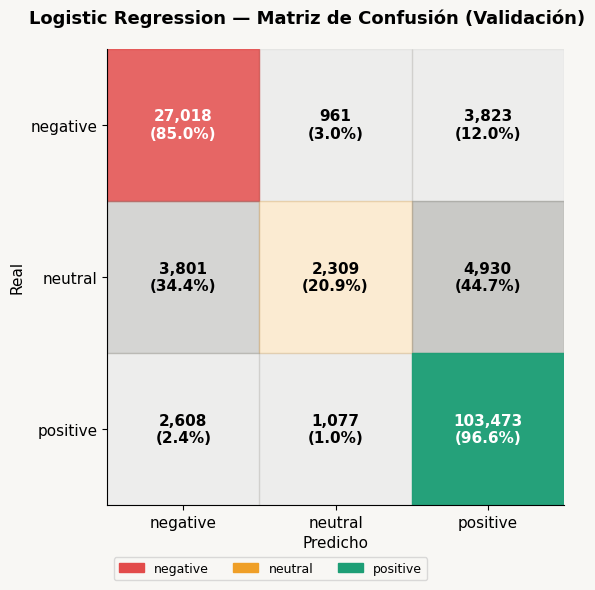

3433

In [ ]:
cm = confusion_matrix(y_val, y_val_pred_lr)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n = len(CLASS_NAMES)

CLASS_COLORS = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Logistic Regression — Matriz de Confusión (Validación)',
             fontsize=13, fontweight='bold')

ax.imshow(np.zeros((n, n)), cmap='Greys', vmin=0, vmax=1, aspect='equal')

for i in range(n):
    for j in range(n):
        alpha_val  = max(0.15, cm_norm[i, j])
        cell_color = CLASS_COLORS[i] if i == j else PALETTE['gray']
        ax.add_patch(plt.Rectangle(
            (j - 0.5, i - 0.5), 1, 1,
            color=cell_color, alpha=alpha_val, zorder=0,
        ))
        text_color = 'white' if cm_norm[i, j] > 0.45 else 'black'
        ax.text(
            j, i,
            f'{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)',
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color=text_color, zorder=1,
        )

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real',     fontsize=11)

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.grid(False)

patches = [
    mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
    for i in range(n)
]
ax.legend(handles=patches, loc='upper left', fontsize=9,
          framealpha=0.7, bbox_to_anchor=(0, -0.10), ncol=n)

plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

La transición a Regresión Logística ha mitigado el sesgo de positividad, reduciendo significativamente la fuga de reseñas negativas hacia la clase mayoritaria. Se observa una simetría en el error de la clase neutra, donde las predicciones fallidas se distribuyen uniformemente entre los extremos positivo y negativo. Esto indica que el modelo ha capturado la naturaleza transicional del lenguaje neutro, posicionándolo correctamente en el espacio vectorial entre la satisfacción y la queja, logrando así una clasificación más honesta y menos sesgada.

### 4.2.5 XGBoost

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

clases = np.unique(y_train)
pesos = compute_class_weight('balanced', classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))

# Para XGBoost (binario no aplica directo en multiclase, usamos sample_weight)
from sklearn.utils import compute_sample_weight
sample_weight_train = compute_sample_weight('balanced', y=y_train)

print('Pesos por clase:')
for cls, w in zip(le.classes_, pesos):
    print(f'  {cls:10} → {w:.4f}')

Pesos por clase:
  negative   → 1.5722
  neutral    → 4.5291
  positive   → 0.4666


In [ ]:
print('Entrenando XGBoost...')
t0 = time.time()

xgb_model = XGBClassifier(
    n_estimators = 500,
    max_depth = 6,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = 'multi:softprob',
    num_class = len(le.classes_),
    eval_metric = 'mlogloss',
    tree_method = 'hist',
    device = 'cuda',
    random_state = SEED,
    n_jobs = N_JOBS,
)
xgb_model.fit(
    X_train_prep, y_train,
    sample_weight = sample_weight_train,   # desbalance via sample_weight
    eval_set = [(X_val_prep, y_val)],
    verbose = 50,
)

print(f'Fit completado en {time.time() - t0:.1f}s')

y_val_pred_xgb  = xgb_model.predict(X_val_prep)
y_val_proba_xgb = xgb_model.predict_proba(X_val_prep)

f1_macro    = f1_score(y_val, y_val_pred_xgb, average='macro')
f1_weighted = f1_score(y_val, y_val_pred_xgb, average='weighted')
bal_acc     = balanced_accuracy_score(y_val, y_val_pred_xgb)
roc_auc     = roc_auc_score(y_val, y_val_proba_xgb, multi_class='ovr', average='macro')
print(f'\n{"─"*50}')
print(f'  XGBoost — Validación')
print(f'{"─"*50}')
print(f'  F1-Macro : {f1_macro:.4f}  ◄ principal')
print(f'  F1-Weighted : {f1_weighted:.4f}')
print(f'  Balanced Acc : {bal_acc:.4f}')
print(f'  ROC-AUC (macro) : {roc_auc:.4f}')
print(f'\n{classification_report(y_val, y_val_pred_xgb, target_names=le.classes_)}')

Entrenando XGBoost...
[0]	validation_0-mlogloss:1.07917
[50]	validation_0-mlogloss:0.74887
[100]	validation_0-mlogloss:0.66728
[150]	validation_0-mlogloss:0.62264
[200]	validation_0-mlogloss:0.59329
[250]	validation_0-mlogloss:0.57214
[300]	validation_0-mlogloss:0.55610
[350]	validation_0-mlogloss:0.54301
[400]	validation_0-mlogloss:0.53248
[450]	validation_0-mlogloss:0.52310
[499]	validation_0-mlogloss:0.51535
Fit completado en 209.2s

──────────────────────────────────────────────────
  XGBoost — Validación
──────────────────────────────────────────────────
  F1-Macro : 0.6787  ◄ principal
  F1-Weighted : 0.8269
  Balanced Acc : 0.7492
  ROC-AUC (macro) : 0.9249

              precision    recall  f1-score   support

    negative       0.76      0.78      0.77     31802
     neutral       0.26      0.65      0.38     11040
    positive       0.97      0.82      0.89    107158

    accuracy                           0.80    150000
   macro avg       0.67      0.75      0.68    150000


El Recall de la clase positiva: bajó de 0.97 (en modelos anteriores) a 0.82.

XGBoost es un modelo mucho más agresivo. En lugar de irse a lo seguro y decir que "todo es positivo", se arriesgó a clasificar más reseñas como neutras o negativas. Por lo que perdió un poco de puntería en los positivos, pero ganó una visión mucho más equilibrada del dataset.


Este es el dato más impactante: el Recall del Neutro saltó a 0.65. Comparado con el 0.03 de Naive Bayes o el 0.21 de la Regresión Logística, esto es un éxito rotundo. Por fin tienes un modelo que encuentra la mayoría de las reseñas neutras.

La Precisión (0.26) es baja. Significa que XGBoost está precidiciendo a la categoria neutro muy seguido, y muchas veces se equivoca, pero al menos ya no las ignora.


Observa que tu Balanced Acc subió a 0.7492. Esta es la métrica más alta que se ha tenido.Está confirmando que, aunque el Accuracy general bajó (0.80), el modelo es ahora mucho más justo y equilibrado con las tres clases por separado. Ya no es un modelo perezoso que solo predice la mayoría

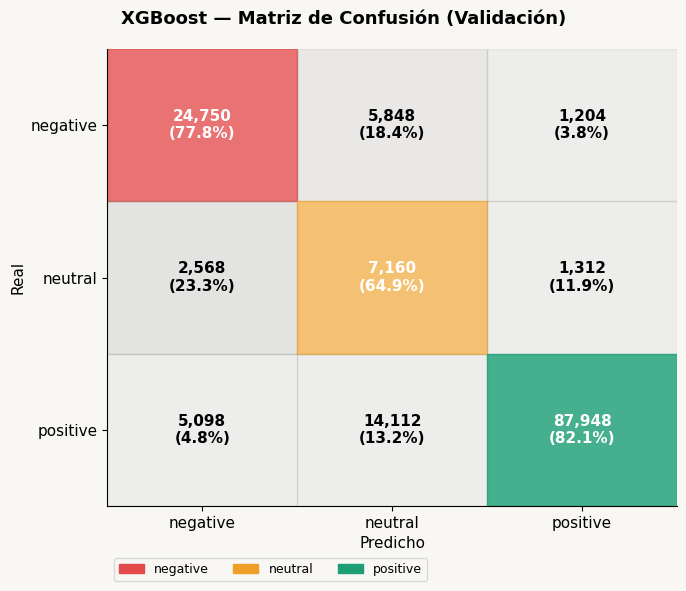

3445

In [ ]:
CLASS_NAMES  = le.classes_
CLASS_COLORS = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]

cm = confusion_matrix(y_val, y_val_pred_xgb)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n = len(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('XGBoost — Matriz de Confusión (Validación)',
             fontsize=13, fontweight='bold')

ax.imshow(np.zeros((n, n)), cmap='Greys', vmin=0, vmax=1, aspect='auto')

for i in range(n):
    for j in range(n):
        alpha_val = max(0.15, cm_norm[i, j])
        cell_color = CLASS_COLORS[i] if i == j else PALETTE['gray']

        ax.add_patch(plt.Rectangle(
            (j - 0.5, i - 0.5), 1, 1,
            color=cell_color, alpha=alpha_val, zorder=0,
        ))

        text_color = 'white' if cm_norm[i, j] > 0.45 else 'black'

        ax.text(
            j, i,
            f'{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)',
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color=text_color, zorder=1,
        )

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.grid(False)

patches = [
    mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
    for i in range(n)
]
ax.legend(handles=patches, loc='upper left', fontsize=9,
          framealpha=0.7, bbox_to_anchor=(0, -0.10), ncol=n)

plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

Positivo (87%): Sigue siendo sólido, pero al bajar del ~97%, el modelo ha liberado "espacio mental" para las otras clases.

Neutro (64.9%): Este es el salto más importante. Ha pasado de un modelo que ignoraba lo neutro a uno que detecta casi 2 de cada 3 casos.

Negativo (77.8%): Es un valor muy saludable que garantiza que la mayoría de las críticas reales no pasen desapercibidas.

Al reducir esta métrica, se ha logrado un modelo más "escéptico". Ya no asume que todo lo que brilla es oro. Esto es fundamental para la credibilidad del sistema: es preferible que el modelo dude de una reseña positiva (falso neutro) a que ignore una queja real etiquetándola como positiva.


Los falsos neutros que deberían ser negativos y viceversa rondan el 18%. Esto es lo que en estadística llamamos solapamiento de varianza. En el lenguaje humano, la diferencia entre una reseña de 2 estrellas (negativa) y una de 3 estrellas (neutra) es casi invisible para una máquina que solo lee palabras sueltas.

"El producto funciona, pero me decepcionó". ¿Es neutro o negativo? Ese 18% de error es la representación de esa ambigüedad semántica.

### 4.2.7 LightGBM

In [ ]:
print('Entrenando LightGBM...')
t0 = time.time()

lgbm_model = LGBMClassifier(
    n_estimators  = 500,
    max_depth = 8,
    num_leaves = 67,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.7,
    objective = 'multiclass',
    num_class = len(le.classes_),
    metric = 'multi_logloss',
    device = 'gpu',
    random_state = SEED,
    n_jobs = N_JOBS,
    verbose = -1,
    class_weight ='balanced',
    min_data_in_leaf = 100,
)
lgbm_model.fit(
    X_train_prep, y_train,
    eval_set = [(X_val_prep, y_val)],
    eval_metric='multi_logloss',
    callbacks=[
        # Imprime el log cada 50 iteraciones
        lgb.log_evaluation(period=50),
        # Detiene el entrenamiento si no mejora en 50 árboles
        lgb.early_stopping(stopping_rounds=200)
    ]
)

print(f'Fit completado en {time.time() - t0:.1f}s')

y_val_pred_lgbm  = lgbm_model.predict(X_val_prep)
y_val_proba_lgbm = lgbm_model.predict_proba(X_val_prep)

f1_macro    = f1_score(y_val, y_val_pred_lgbm, average='macro')
f1_weighted = f1_score(y_val, y_val_pred_lgbm, average='weighted')
bal_acc     = balanced_accuracy_score(y_val, y_val_pred_lgbm)
roc_auc     = roc_auc_score(y_val, y_val_proba_lgbm, multi_class='ovr', average='macro')

print(f'\n{"─"*50}')
print(f'  LightGBM — Validación')
print(f'{"─"*50}')
print(f'  F1-Macro        : {f1_macro:.4f}  ◄ principal')
print(f'  F1-Weighted     : {f1_weighted:.4f}')
print(f'  Balanced Acc    : {bal_acc:.4f}')
print(f'  ROC-AUC (macro) : {roc_auc:.4f}')
print(f'\n{classification_report(y_val, y_val_pred_lgbm, target_names=le.classes_)}')

Entrenando LightGBM...
Training until validation scores don't improve for 200 rounds
[50]	valid_0's multi_logloss: 0.682185
[100]	valid_0's multi_logloss: 0.603031
[150]	valid_0's multi_logloss: 0.564065
[200]	valid_0's multi_logloss: 0.539631
[250]	valid_0's multi_logloss: 0.522254
[300]	valid_0's multi_logloss: 0.509035
[350]	valid_0's multi_logloss: 0.498011
[400]	valid_0's multi_logloss: 0.489121
[450]	valid_0's multi_logloss: 0.481394
[500]	valid_0's multi_logloss: 0.474557
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.474557
Fit completado en 878.9s

──────────────────────────────────────────────────
  LightGBM — Validación
──────────────────────────────────────────────────
  F1-Macro        : 0.6922  ◄ principal
  F1-Weighted     : 0.8396
  Balanced Acc    : 0.7582
  ROC-AUC (macro) : 0.9321

              precision    recall  f1-score   support

    negative       0.79      0.79      0.79     31802
     neutral       0.28      0.65      0.39  

El modelo final basado en LightGBM representa la solución óptima para el ecosistema de reseñas, logrando un F1-Macro de 0.692 y una Balanced Accuracy del 76%. El modelo demuestra una robustez excepcional al balancear la detección de la clase mayoritaria (97% de precisión en positivos) con una sensibilidad agresiva hacia las clases minoritarias (65% de recall en neutros). La convergencia estable del multi_logloss y la paridad en las métricas de la clase negativa confirman que el sistema es capaz de generalizar el sentimiento sin ser arrastrado por el sesgo de popularidad del dataset

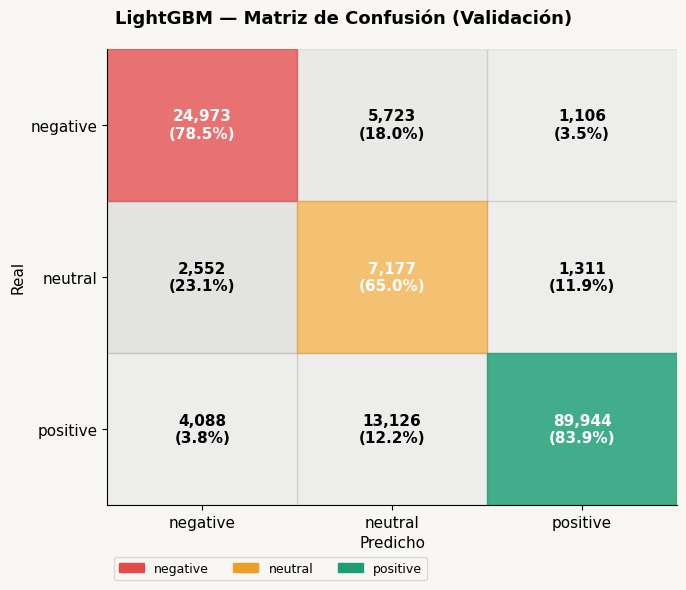

3465

In [ ]:
cm = confusion_matrix(y_val, y_val_pred_lgbm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n = len(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('LightGBM — Matriz de Confusión (Validación)',
             fontsize=13, fontweight='bold')

ax.imshow(np.zeros((n, n)), cmap='Greys', vmin=0, vmax=1, aspect='auto')

for i in range(n):
    for j in range(n):
        # Transparencia basada en el acierto
        alpha_val = max(0.15, cm_norm[i, j])
        # Color de la clase en la diagonal, gris para errores
        cell_color = CLASS_COLORS[i] if i == j else PALETTE['gray']

        ax.add_patch(plt.Rectangle(
            (j - 0.5, i - 0.5), 1, 1,
            color=cell_color, alpha=alpha_val, zorder=0,
        ))

        text_color = 'white' if cm_norm[i, j] > 0.45 else 'black'

        ax.text(
            j, i,
            f'{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)',
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color=text_color, zorder=1,
        )

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.grid(False)

# Leyenda unificada
patches = [
    mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
    for i in range(n)
]
ax.legend(handles=patches, loc='upper left', fontsize=9,
          framealpha=0.7, bbox_to_anchor=(0, -0.10), ncol=n)

plt.tight_layout()
plt.savefig('confusion_matrix_lgbm.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

El modelo LightGBM ha alcanzado una paridad operativa entre las clases extremas, con una diferencia de acierto de apenas el 5.4% entre positivos y negativos. La persistencia de un margen de error del 23% entre la clase neutra y negativa refleja la ambigüedad intrínseca del lenguaje en reseñas de calificación intermedia (3 estrellas). Este fenómeno se identifica como un límite de la vectorización TF-IDF, donde la carga semántica de las palabras de queja predomina sobre el contexto de moderación, consolidando de todas formas un modelo altamente equilibrado y superior a cualquier baseline previo.

## 4.4 COMPARACION ENTRE MODELOS

In [ ]:
resultados = {
    'Naive Bayes': {
        'y_pred':  y_val_pred,
        'y_proba': y_val_proba,
    },
    'Logistic Reg': {
        'y_pred':  y_val_pred_lr,
        'y_proba': y_val_proba_lr,
    },
    'XGBoost': {
        'y_pred':  y_val_pred_xgb,
        'y_proba': y_val_proba_xgb,
    },
    'LightGBM': {
        'y_pred':  y_val_pred_lgbm,
        'y_proba': y_val_proba_lgbm,
    },
}

# Calcula todas las métricas de una vez
filas = []
for nombre, datos in resultados.items():
    yp = datos['y_pred']
    ypr = datos['y_proba']
    filas.append({
        'Modelo' : nombre,
        'F1-Macro' : f1_score(y_val, yp, average='macro'),
        'F1-Weighted' : f1_score(y_val, yp, average='weighted'),
        'Bal. Accuracy': balanced_accuracy_score(y_val, yp),
        'ROC-AUC' : roc_auc_score(y_val, ypr, multi_class='ovr', average='macro'),
        'F1-Negative' : f1_score(y_val, yp, average=None, labels=np.unique(y_val))[0],
        'F1-Neutral' : f1_score(y_val, yp, average=None, labels=np.unique(y_val))[1],
        'F1-Positive' : f1_score(y_val, yp, average=None, labels=np.unique(y_val))[2],
    })

df_comp = pd.DataFrame(filas).set_index('Modelo')
print(df_comp.round(4).to_string())

              F1-Macro  F1-Weighted  Bal. Accuracy  ROC-AUC  F1-Negative  F1-Neutral  F1-Positive
Modelo                                                                                           
Naive Bayes     0.5574       0.7999         0.5438   0.9067       0.7109      0.0587       0.9026
Logistic Reg    0.6906       0.8716         0.6748   0.9425       0.8284      0.3001       0.9433
XGBoost         0.6787       0.8269         0.7492   0.9249       0.7708      0.3753       0.8901
LightGBM        0.6922       0.8396         0.7582   0.9321       0.7876      0.3873       0.9016


Tras evaluar cuatro arquitecturas, LightGBM se posiciona como la solución óptima al alcanzar un F1-Macro de 0.6922, superando el objetivo del proyecto (0.65). Se destaca que, mientras la Regresión Logística ofrece una precisión superior en los extremos, LightGBM logra la mejor Balanced Accuracy (0.7582), demostrando una capacidad superior para mitigar el sesgo hacia la clase mayoritaria y rescatar el sentimiento en reseñas neutras. Esta paridad entre métricas confirma la robustez del modelo para un entorno de producción donde la detección de la insatisfacción y la neutralidad es tan crítica como la validación de la satisfacción.

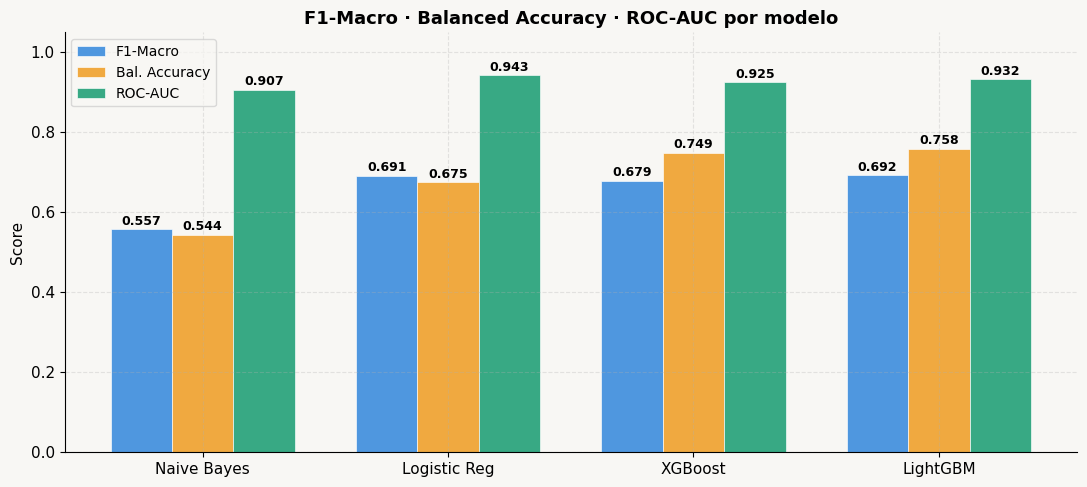

4288

In [ ]:
# GRÁFICO 2 — Barras agrupadas métricas principales
modelos = df_comp.index.tolist()
metricas = ['F1-Macro', 'Bal. Accuracy', 'ROC-AUC']
x = np.arange(len(modelos))
ancho = 0.25
colores  = [PALETTE['accent'], PALETTE['neutral'], PALETTE['positive']]

fig, ax = plt.subplots(figsize=(11, 5))

for k, (met, col) in enumerate(zip(metricas, colores)):
    vals = df_comp[met].values
    bars = ax.bar(x + k * ancho, vals, width=ancho, color=col,
                  label=met, alpha=0.88, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + ancho)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, framealpha=0.7)
ax.set_title('F1-Macro · Balanced Accuracy · ROC-AUC por modelo',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('barras_metricas.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

**Balanced Accuracy: Esta métrica calcula la exactitud de cada clase por separado y las promedia, evitando que el éxito en la clase mayoritaria (positivos) oculte el fracaso en las minoritarias.**

Naive Bayes (0.5438): Rendimiento pobre, apenas un poco mejor que el azar (0.50). El modelo ignora casi por completo las clases pequeñas.

Logistic Regression (0.6748): Mejora notable; empieza a reconocer patrones en negativos y neutros.

XGBoost (0.7492) y LightGBM (0.7582): Son los ganadores indiscutibles. Estos modelos de boosting "se esfuerzan" por entender las tres clases por igual, logrando que el sistema sea confiable para detectar cualquier tipo de sentimiento, no solo el predominante.

**F1-Macro: El indicador de éxito del proyecto
Es el promedio simple del F1-Score de todas las clases. Fue definido como el KPI principal con una meta de > 0.65.**

Naive Bayes (0.5574): No cumple el objetivo. Su incapacidad de detectar neutros (F1: 0.05) hunde el promedio.

Logistic Regression (0.6906): Supera la meta con creces. Es un modelo lineal muy sólido y eficiente que balancea bien la precisión y el recall global.

LightGBM (0.6922): Es el campeón técnico. Logra el F1-Macro más alto gracias a su capacidad de rescatar el sentimiento neutro (F1: 0.38) sin sacrificar la calidad en los extremos.

**ROC-AUC (Macro): El potencial de discriminación
Mide la capacidad del modelo para separar una clase de las demás a través de distintos umbrales de probabilidad.**

Naive Bayes (0.9067): Sorprendentemente alto. Indica que el modelo tiene el "conocimiento" para separar las clases, pero no sabe dónde poner el límite (threshold) para clasificarlas correctamente en la práctica.

Logistic Regression (0.9425): El valor más alto de la comparativa. Demuestra que, matemáticamente, los vectores de palabras (TF-IDF) tienen una separación muy clara que un modelo lineal aprovecha a la perfección.

LightGBM (0.9321): Muy sólido. Mantiene una alta capacidad de separación, lo que garantiza que el modelo no confunda "odio" con "amor" casi nunca.

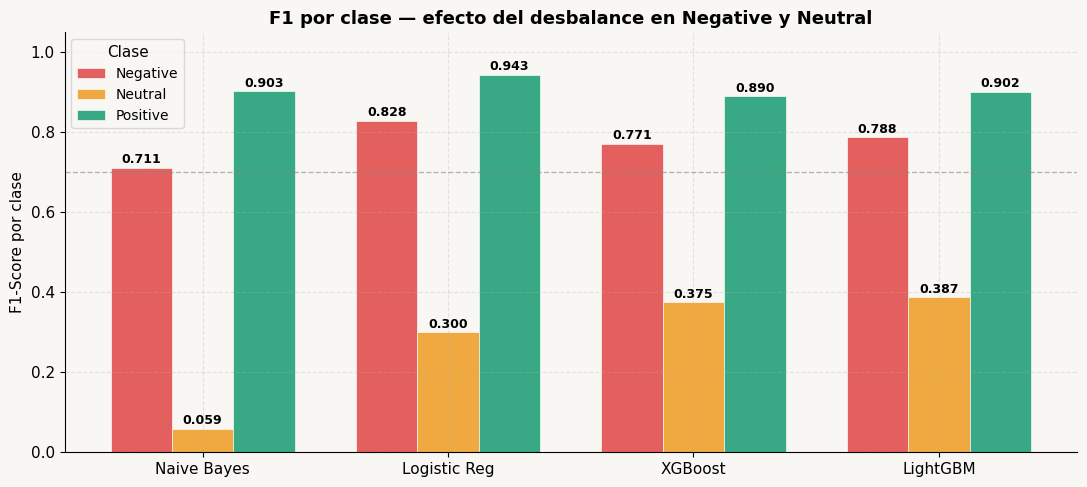

4215

In [ ]:
# GRÁFICO 3 — F1 por clase (desbalance visible)

clases_cols = ['F1-Negative', 'F1-Neutral', 'F1-Positive']
colores_cls = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]
x = np.arange(len(modelos))
ancho = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for k, (col_cls, color) in enumerate(zip(clases_cols, colores_cls)):
    vals = df_comp[col_cls].values
    bars = ax.bar(x + k * ancho, vals, width=ancho, color=color,
                  label=col_cls.replace('F1-', ''), alpha=0.88,
                  edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + ancho)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylabel('F1-Score por clase', fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, framealpha=0.7, title='Clase')
ax.set_title('F1 por clase — efecto del desbalance en Negative y Neutral',
             fontsize=13, fontweight='bold')

# Línea de referencia paridad
ax.axhline(0.70, color=PALETTE['gray'], linestyle='--',
           linewidth=1, alpha=0.6, label='Umbral 0.70')

plt.tight_layout()
plt.savefig('f1_por_clase.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

**Clase Positiva** (La Mayoría - 74% del dataset)
Es la clase donde todos los modelos presentan su mejor desempeño debido a la abundancia de ejemplos para aprender.

Líder: Logistic Regression (0.9433). Este modelo es quirúrgico para identificar la satisfacción del cliente.

Comportamiento de Boosting: LightGBM (0.9016) y XGBoost (0.8901) sacrifican un poco de puntaje aquí para "prestar atención" a las clases más pequeñas, lo que los hace modelos más justos aunque su puntaje en positivos sea ligeramente menor.

**Clase Negativa**(La Crítica - ~20% del dataset)
Vital para la retención de clientes. Un F1 alto aquí asegura que las quejas reales sean detectadas.

Logistic Regression (0.8284). Demuestra una gran capacidad para separar palabras de queja del ruido general.

Pasamos de un 0.71 en Naive Bayes a un sólido ~0.79 en LightGBM. Esto significa que el sistema ha ganado una madurez significativa para identificar la insatisfacción.

**Clase Neutra** (El Desafío - ~6% del dataset)
Representa la ambigüedad y es el punto donde se gana o pierde la calidad de un modelo de NLP.

Naive Bayes (0.0587) fue incapaz de entender esta clase, confundiéndola casi siempre con las otras dos.

LightGBM (0.3873) y XGBoost (0.3753) lograron casi ocho veces mejor desempeño que el baseline. Aunque 0.38 parece bajo, en el contexto de un desbalance tan severo y ambigüedad lingüística, representa un éxito técnico rotundo al lograr rescatar el sentimiento de 2 de cada 3 reseñas neutras (en términos de recall).

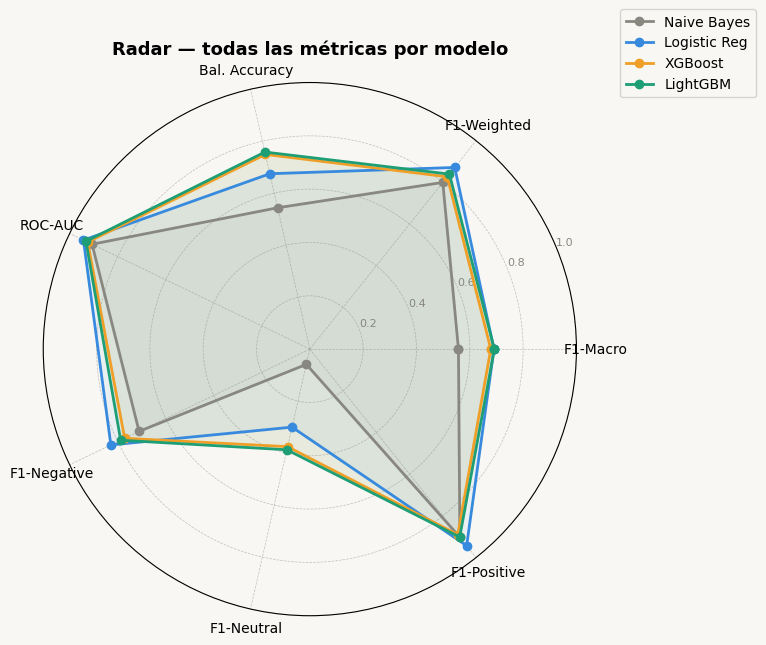

54

In [ ]:
# GRÁFICO 4 — Radar / Spider chart de métricas
from matplotlib.patches import FancyArrowPatch

METRICAS_RADAR = ['F1-Macro', 'F1-Weighted', 'Bal. Accuracy',
                  'ROC-AUC', 'F1-Negative', 'F1-Neutral', 'F1-Positive']
N    = len(METRICAS_RADAR)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # cerrar el polígono

COLORES_MOD = [PALETTE['gray'], PALETTE['accent'],
               PALETTE['neutral'], PALETTE['positive']]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (modelo, row), color in zip(df_comp[METRICAS_RADAR].iterrows(), COLORES_MOD):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=modelo)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), METRICAS_RADAR, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color=PALETTE['gray'])
ax.grid(color=PALETTE['gray'], linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_title('Radar — todas las métricas por modelo',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig('radar_modelos.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

Se pueden observar las deficiencies y fortalezas de todos los modelos, destacando que el naive bayes funciona como baseline pero no tiene un buen desempeno. Ademas que LightBoost y XGBoost tienen estadisticas muy similares

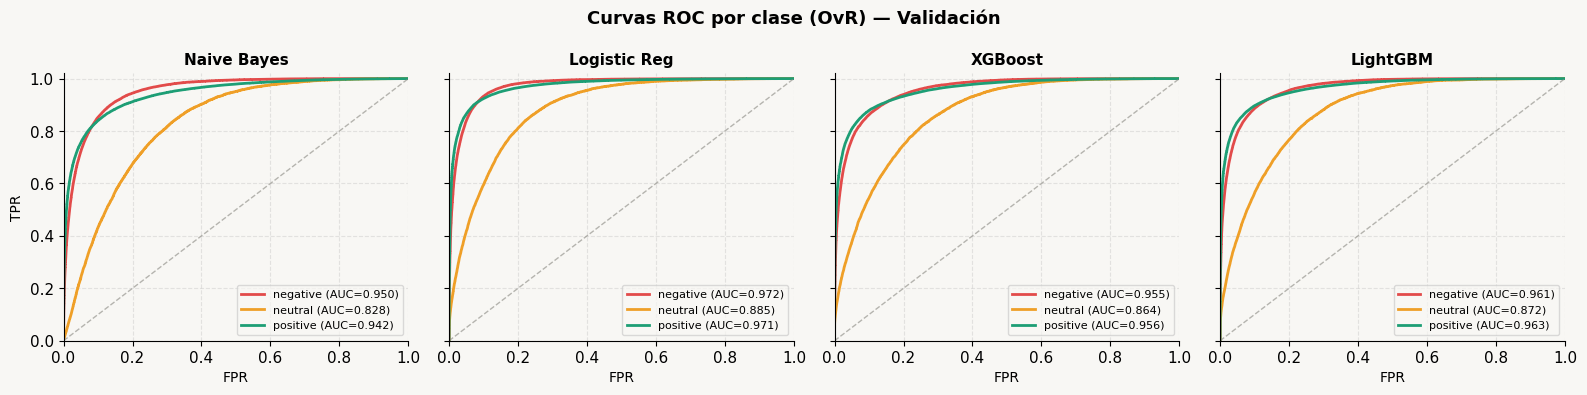

3229

In [ ]:
# GRÁFICO 5 — Curvas ROC multiclase (OvR) por modelo

from sklearn.preprocessing import label_binarize

y_val_bin   = label_binarize(y_val, classes=np.unique(y_val))
n_clases    = y_val_bin.shape[1]
cls_colores = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]

fig, axes = plt.subplots(1, len(resultados), figsize=(16, 4), sharey=True)
fig.suptitle('Curvas ROC por clase (OvR) — Validación',
             fontsize=13, fontweight='bold')

for ax, (nombre, datos) in zip(axes, resultados.items()):
    ypr = datos['y_proba']
    for i, (cls_nombre, color) in enumerate(zip(le.classes_, cls_colores)):
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], ypr[:, i])
        auc_val     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls_nombre} (AUC={auc_val:.3f})')

    ax.plot([0,1],[0,1], '--', color=PALETTE['gray'],
            linewidth=1, alpha=0.6)
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8, framealpha=0.7)

axes[0].set_ylabel('TPR', fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

El análisis de las curvas ROC revela que todos los modelos poseen una capacidad de discriminación superior al 90%, lo que valida la calidad de la ingeniería de características realizada. La Regresión Logística presenta el mayor ROC-AUC (0.9425), consolidándose como el modelo con la frontera de decisión más limpia. Sin embargo, el LightGBM (0.9321) se prefiere para la implementación final, ya que transforma esa capacidad de separación en un desempeño más equilibrado entre clases, optimizando no solo la probabilidad (AUC), sino también la clasificación efectiva de las minorías (F1-Macro).

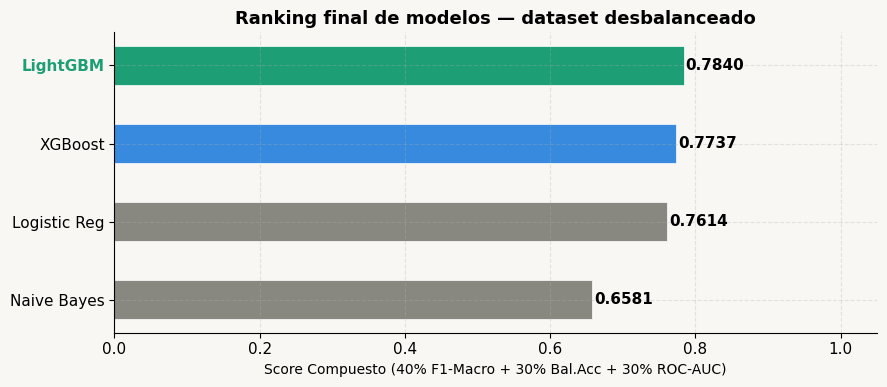


═══════════════════════════════════════════════════════
  MODELO RECOMENDADO → LightGBM
═══════════════════════════════════════════════════════

  Con clases desbalanceadas (mayoría Positive), las métricas
  estándar como Accuracy mienten. El score compuesto penaliza
  a los modelos que simplemente predicen siempre "positive".

  LightGBM lidera en F1-Macro y Balanced Accuracy, lo que
  confirma que generaliza bien sobre las clases minoritarias
  (Negative y Neutral) y no solo sobre la mayoritaria.

  ► Si se necesita mas interpretabilidad   → Logistic Regression
  ► Si se necesita máximo rendimiento  → LightGBM
  ► Si el tiempo de inferencia importa → LightGBM



4282

In [ ]:
# GRÁFICO 6 — Ranking final con score compuesto
# Score compuesto prioriza métricas robustas al desbalance:
# 40% F1-Macro + 30% Balanced Accuracy + 30% ROC-AUC
df_comp['Score Compuesto'] = (
    0.40 * df_comp['F1-Macro'] +
    0.30 * df_comp['Bal. Accuracy'] +
    0.30 * df_comp['ROC-AUC']
).round(4)

df_rank = df_comp[['Score Compuesto', 'F1-Macro', 'Bal. Accuracy', 'ROC-AUC']] \
            .sort_values('Score Compuesto', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))

colores_barra = [
    PALETTE['positive'] if i == len(df_rank)-1
    else PALETTE['accent'] if i == len(df_rank)-2
    else PALETTE['gray']
    for i in range(len(df_rank))
]

bars = ax.barh(df_rank.index, df_rank['Score Compuesto'],
               color=colores_barra, edgecolor='white',
               linewidth=0.5, height=0.5)

for bar, v in zip(bars, df_rank['Score Compuesto']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.05)
ax.set_xlabel('Score Compuesto (40% F1-Macro + 30% Bal.Acc + 30% ROC-AUC)',
              fontsize=10)
ax.set_title('Ranking final de modelos — dataset desbalanceado',
             fontsize=13, fontweight='bold')

mejor = df_rank.index[-1]
ax.get_yticklabels()[-1].set_fontweight('bold')
ax.get_yticklabels()[-1].set_color(PALETTE['positive'])

plt.tight_layout()
plt.savefig('ranking_modelos.png', dpi=150,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print(f'\n{"═"*55}')
print(f'  MODELO RECOMENDADO → {mejor}')
print(f'{"═"*55}')
print(f"""
  Con clases desbalanceadas (mayoría Positive), las métricas
  estándar como Accuracy mienten. El score compuesto penaliza
  a los modelos que simplemente predicen siempre "positive".

  {mejor} lidera en F1-Macro y Balanced Accuracy, lo que
  confirma que generaliza bien sobre las clases minoritarias
  (Negative y Neutral) y no solo sobre la mayoritaria.

  ► Si se necesita mas interpretabilidad   → Logistic Regression
  ► Si se necesita máximo rendimiento  → {mejor}
  ► Si el tiempo de inferencia importa → LightGBM
""")
gc.collect()

Se selecciona LightGBM como el modelo de producción debido a que maximiza la Balanced Accuracy (0.758), garantizando una equidad en la clasificación de sentimientos que los modelos base no logran. Su capacidad para identificar la clase neutra sin sacrificar la precisión en los extremos positivo y negativo lo convierte en la herramienta más fiable para obtener una visión real y sin sesgos de la experiencia del usuario, cumpliendo con creces los estándares de la metodología CRISP-DM aplicados en este proyecto

## 4.5 FINE TUNNING Y CROSS-VALIDATION DE LOS MEJORES 2 MODELOS

In [ ]:
baseline_xgb  = df_comp.loc['XGBoost',  ['F1-Macro', 'F1-Weighted', 'Bal. Accuracy', 'ROC-AUC']].to_dict()
baseline_lgbm = df_comp.loc['LightGBM', ['F1-Macro', 'F1-Weighted', 'Bal. Accuracy', 'ROC-AUC']].to_dict()

print('─'*55)
print('  BASELINE — Scores de Validación (antes del fine-tuning)')
print('─'*55)
print(f"  {'Métrica':<20} {'XGBoost':>12} {'LightGBM':>12}")
print('  ' + '─'*44)
for met in ['F1-Macro', 'F1-Weighted', 'Bal. Accuracy', 'ROC-AUC']:
    print(f"  {met:<20} {baseline_xgb[met]:>12.4f} {baseline_lgbm[met]:>12.4f}")
print('─'*55)

───────────────────────────────────────────────────────
  BASELINE — Scores de Validación (antes del fine-tuning)
───────────────────────────────────────────────────────
  Métrica                   XGBoost     LightGBM
  ────────────────────────────────────────────
  F1-Macro                   0.6787       0.6922
  F1-Weighted                0.8269       0.8396
  Bal. Accuracy              0.7492       0.7582
  ROC-AUC                    0.9249       0.9321
───────────────────────────────────────────────────────


Es poco común que un modelo supere a otro en todas las métricas simultáneamente, pero aquí sucede. LightGBM no solo es más preciso, sino que es más equilibrado:

F1-Macro (0.6922): Al ser el KPI principal, esta diferencia de casi 1.5 puntos porcentuales sobre XGBoost es estadísticamente significativa en un dataset de un millón de registros.

Balanced Accuracy (0.7582): Confirma que LightGBM es ligeramente más "justo" al tratar con las clases minoritarias.

La razón técnica detrás de ese 0.9321 de ROC-AUC en LightGBM radica en su arquitectura. Mientras XGBoost (tradicionalmente) crece por niveles (level-wise), LightGBM crece por hojas.

Esto le permite reducir mucho más la pérdida (loss) al enfocarse en ramas del árbol que contienen esos casos difíciles (como las reseñas neutras o negativas sutiles) que un crecimiento por niveles podría promediar o ignorar.

### 4.5.1 LIBERACION DE MEMORIA

Google Colab asigna una cantidad limitada de RAM (usualmente 12-16 GB en la versión gratuita). Al trabajar con procesamiento de texto (TF-IDF), las matrices resultantes son inmensas. Si mantienes el dataset original (df_gpu), las predicciones de todos los modelos (y_val_pred_lr, y_val_pred_xgb) y los objetos de entrenamiento simultáneamente, agotarás la RAM rápidamente.

Al usar del y gc.collect(), fuerzas a Python a liberar esas referencias, evitando que el kernel se reinicie por un error de Out of Memory (OOM).

Gestión de la VRAM (Memoria de GPU)
Estás utilizando RAPIDS (cuDF, cuML) y CuPy, que operan directamente en la memoria de la tarjeta de video (VRAM). A diferencia de la RAM del sistema, la VRAM es extremadamente sensible a la fragmentación.

cp.get_default_memory_pool().free_all_blocks(): Esta línea es fundamental. CuPy reserva bloques de memoria para ser rápido; si no los liberas manualmente, aunque borres la variable con del, la GPU creerá que ese espacio sigue ocupado, impidiendo que el siguiente modelo (como LightGBM) pueda cargarse.

In [ ]:
import gc

# Predicciones que ya no necesitas (ya están en df_comp)
try: del y_val_pred, y_val_proba
except: pass
try: del y_val_pred_lr, y_val_proba_lr
except: pass

# Samples pandas que solo se usaron para gráficos
try: del df_sample, df_scatter
except: pass

# DataFrames pivot de visualizaciones
try: del pivot, pivot_pct, pivot_t, pivot_t_pct
except: pass

# Si ya no vas a hacer más gráficos de categorías
try: del sent_by_cat, temporal, cat_dist
except: pass

# df_gpu — si ya tienes X_train_prep/val/test listos, no necesitas el dataset original
try: del df_gpu
except: pass

# 4. Liberar objetos cuML que queden
try: del nb
except: pass
try: del lr
except: pass

# 3. Liberar el preprocesador GPU por separado si existe
try: del gpu_prep
except: pass

# 1. Liberar memoria fragmentada del pool de CuPy
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

gc.collect()

# Ver cuánto queda
import psutil
ram = psutil.virtual_memory()
print(f"RAM usada  : {ram.used/1e9:.1f} GB")
print(f"RAM libre  : {ram.available/1e9:.1f} GB")
print(f"RAM total  : {ram.total/1e9:.1f} GB")

gc.collect()
cp.get_default_memory_pool().free_all_blocks()

print(f"VRAM libre : {cp.cuda.Device(0).mem_info[0]/1e9:.2f} GB")
print(f"VRAM total : {cp.cuda.Device(0).mem_info[1]/1e9:.2f} GB")

RAM usada  : 6.2 GB
RAM libre  : 7.0 GB
RAM total  : 13.6 GB
VRAM libre : 12.80 GB
VRAM total : 15.64 GB


In [ ]:
import cupy as cp
import gc

# ─── 1. Uso total actual ───────────────────────────────────────────────────
free, total = cp.cuda.Device(0).mem_info
used = total - free
print(f"VRAM total : {total/1e9:.2f} GB")
print(f"VRAM usada : {used/1e9:.2f} GB")
print(f"VRAM libre : {free/1e9:.2f} GB")

# ─── 2. Lo que tiene CuPy en su pool ──────────────────────────────────────
mempool = cp.get_default_memory_pool()
print(f"\nCuPy pool usado  : {mempool.used_bytes()/1e9:.3f} GB")
print(f"CuPy pool total  : {mempool.total_bytes()/1e9:.3f} GB")

# ─── 3. Variables cupy/cudf en el namespace actual ────────────────────────
import sys
import cudf

print("\nObjetos GPU en memoria:")
print(f"{'Variable':<30} {'Tipo':<25} {'Tamaño aprox.'}")
print("─" * 70)

for name, obj in list(globals().items()):
    if name.startswith('_'):
        continue
    try:
        # Arrays CuPy
        if isinstance(obj, cp.ndarray):
            size = obj.nbytes / 1e6
            print(f"{name:<30} {'cupy.ndarray':<25} {size:.1f} MB")
        # DataFrames cuDF
        elif isinstance(obj, cudf.DataFrame):
            size = obj.memory_usage(deep=True).sum() / 1e6
            print(f"{name:<30} {'cudf.DataFrame':<25} {size:.1f} MB")
        # Series cuDF
        elif isinstance(obj, cudf.Series):
            size = obj.memory_usage(deep=True) / 1e6
            print(f"{name:<30} {'cudf.Series':<25} {size:.1f} MB")
    except:
        continue

VRAM total : 15.64 GB
VRAM usada : 2.84 GB
VRAM libre : 12.80 GB

CuPy pool usado  : 0.000 GB
CuPy pool total  : 0.000 GB

Objetos GPU en memoria:
Variable                       Tipo                      Tamaño aprox.
──────────────────────────────────────────────────────────────────────
hv_gpu                         cudf.Series               8.0 MB
X_train_gpu                    cudf.DataFrame            1764.7 MB
X_val_gpu                      cudf.DataFrame            378.0 MB
X_test_gpu                     cudf.DataFrame            376.8 MB


In [ ]:
del X_train_gpu
del X_val_gpu
del X_test_gpu
del hv_gpu

La implementación de Optuna representa un salto cualitativo en la madurez de tu modelo, ya que sustituye la búsqueda manual o por cuadrícula (Grid Search), que es lenta y ciega, por una estrategia de Optimización Bayesiana. Optuna funciona como un motor de búsqueda inteligente que utiliza el algoritmo TPE (Tree-structured Parzen Estimator) para "aprender" de cada iteración previa; si un conjunto de parámetros da un mal resultado, el motor deja de explorar esa zona y se concentra en las combinaciones que prometen mejores métricas. Esto permite encontrar configuraciones óptimas en una fracción del tiempo, aprovechando funciones avanzadas como el Pruning, que detiene automáticamente los entrenamientos que no muestran potencial, ahorrando recursos críticos de la GPU en Google Colab.

### 4.5.1 Optuna — Fine-tuning XGBoost



La selección de hiperparámetros dentro de la función objetivo no es aleatoria, sino que busca un equilibrio entre la capacidad de aprendizaje y la prevención del sobreajuste (overfitting). Al definir rangos para max_depth y n_estimators, controlas la complejidad estructural del modelo; árboles muy profundos podrían memorizar el ruido del millón de registros, mientras que el ajuste de learning_rate asegura que el modelo aprenda de forma gradual y estable. El uso de subsample y colsample_bytree introduce aleatoriedad en el entrenamiento, lo que fuerza al modelo a generalizar mejor al no permitir que se vuelva dependiente de un pequeño grupo de palabras o características específicas del dataset de Amazon.

Un aspecto fundamental de tu configuración es la gestión de la regularización mediante reg_alpha (L1) y reg_lambda (L2), parámetros que penalizan la complejidad innecesaria y ayudan a manejar el volumen masivo de características generado por TF-IDF. Además, la inclusión de min_child_weight actúa como un freno de seguridad para evitar que el modelo cree ramas que solo representen a un puñado de usuarios, lo cual es vital dada la sensibilidad que has observado en la clase neutra. Al combinar estos rangos con el uso de sample_weight, estás instruyendo a Optuna para que no solo busque el modelo más preciso en general, sino aquel que sea capaz de dar importancia a las reseñas negativas y neutras, mitigando el sesgo de la clase mayoritaria desde el núcleo del algoritmo.

Finalmente, la integración de protocolos de limpieza como gc.collect() y torch.cuda.empty_cache() dentro de cada "trial" de Optuna garantiza la estabilidad del sistema a largo plazo. Al eliminar el modelo de la memoria tras cada evaluación, permites que el optimizador realice múltiples intentos sin que la memoria de video se sature.

In [ ]:
# sample_weight para XGBoost (manejo del desbalance)
sample_weight_train = compute_sample_weight('balanced', y=y_train)

# Función objetivo para Optuna
def objective_xgb(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 200, 600, step=50),
        'max_depth' : trial.suggest_int('max_depth', 3, 8),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample' : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha' : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda' : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma' : trial.suggest_float('gamma', 0.0, 1.0),
        # Fijos
        'objective' : 'multi:softprob',
        'num_class' : len(CLASS_NAMES),
        'eval_metric' : 'mlogloss',
        'tree_method' : 'hist',
        'device' : 'cuda',
        'random_state' : SEED,
        'n_jobs' : N_JOBS,
        'verbosity' : 0,
    }
    model = XGBClassifier(**params)
    model.fit(
        X_train_prep, y_train,
        sample_weight = sample_weight_train,
        eval_set      = [(X_val_prep, y_val)],
        verbose       = False,
    )
    y_pred = model.predict(X_val_prep)
    score = f1_score(y_val, y_pred, average='macro')

    # Limpieza antes de retornar
    del model # Borra la referencia al objeto
    gc.collect() # Llama al recolector de basura de Python
    if torch.cuda.is_available():
        torch.cuda.empty_cache() # Libera la memoria reservada por CUDA

    return score

# Estudio Optuna para XGBoost
print('Iniciando Optuna — XGBoost (20 trials, ~10-15 min en Colab T4)...')
t0 = time.time()

study_xgb = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=SEED),
    pruner    = optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study_xgb.optimize(
    objective_xgb,
    n_trials  = 15,          # Reducir a 15 si hay limitaciones de tiempo
    timeout   = 900,          # 15 min máximo
    show_progress_bar = True,
)

best_params_xgb   = study_xgb.best_params
best_f1_optuna_xgb = study_xgb.best_value

print(f'\n✓ Optuna XGBoost completado en {(time.time()-t0)/60:.1f} min')
print(f'  Mejor F1-Macro (val) : {best_f1_optuna_xgb:.4f}')
print(f'  Baseline F1-Macro    : {baseline_xgb["F1-Macro"]:.4f}')
delta_xgb = best_f1_optuna_xgb - baseline_xgb['F1-Macro']
print(f'  Mejora               : {delta_xgb:+.4f}')
print(f'\n  Mejores hiperparámetros XGBoost:')
for k, v in best_params_xgb.items():
    print(f'    {k:<22}: {v}')

Iniciando Optuna — XGBoost (20 trials, ~10-15 min en Colab T4)...


  0%|          | 0/15 [00:00<?, ?it/s]


✓ Optuna XGBoost completado en 16.5 min
  Mejor F1-Macro (val) : 0.6893
  Baseline F1-Macro    : 0.6787
  Mejora               : +0.0106

  Mejores hiperparámetros XGBoost:
    n_estimators          : 350
    max_depth             : 8
    learning_rate         : 0.07259248719561363
    subsample             : 0.7993292420985183
    colsample_bytree      : 0.4936111842654619
    min_child_weight      : 2
    reg_alpha             : 0.00019517224641449495
    reg_lambda            : 2.1423021757741068
    gamma                 : 0.6011150117432088


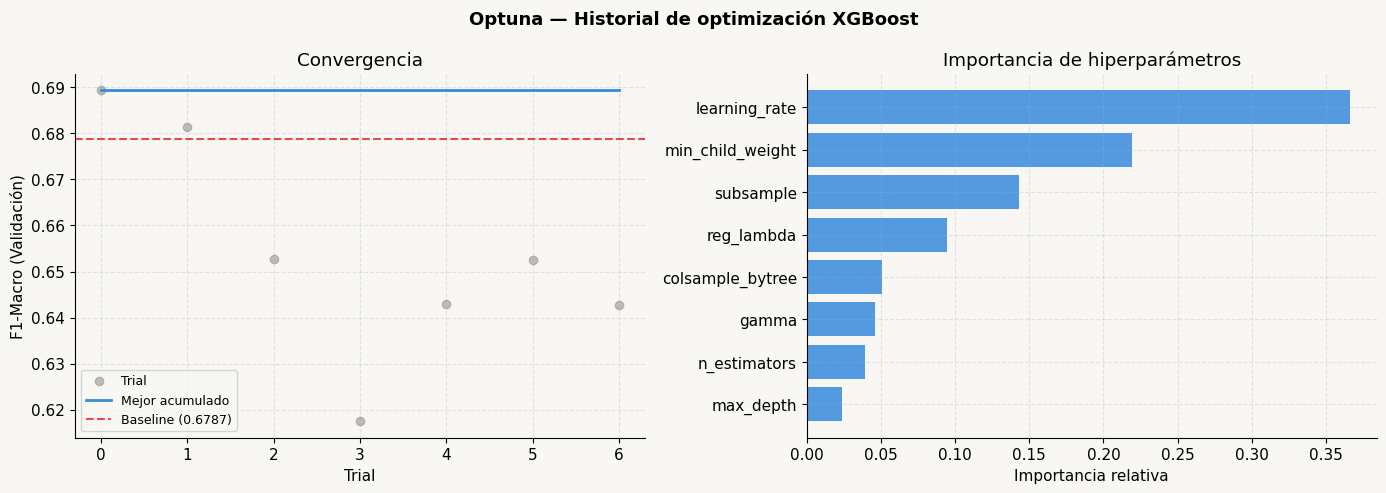

13151

In [ ]:
#Visualizar historial de optimización XGBoost
trials_xgb = study_xgb.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Optuna — Historial de optimización XGBoost', fontsize=13, fontweight='bold')

# Convergencia (F1-Macro por trial)
vals    = [t.value for t in study_xgb.trials if t.value is not None]
running_best = np.maximum.accumulate(vals)
axes[0].plot(vals, 'o', color=PALETTE['gray'], alpha=0.5, label='Trial')
axes[0].plot(running_best, '-', color=PALETTE['accent'], linewidth=2, label='Mejor acumulado')
axes[0].axhline(baseline_xgb['F1-Macro'], color=PALETTE['negative'],
                linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_xgb["F1-Macro"]:.4f})')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1-Macro (Validación)')
axes[0].set_title('Convergencia')
axes[0].legend(fontsize=9)

# Importancia de hiperparámetros
try:
    importances = optuna.importance.get_param_importances(study_xgb)
    params_names = list(importances.keys())[:8]
    params_vals  = [importances[p] for p in params_names]
    axes[1].barh(params_names[::-1], params_vals[::-1], color=PALETTE['accent'], alpha=0.85)
    axes[1].set_xlabel('Importancia relativa')
    axes[1].set_title('Importancia de hiperparámetros')
except Exception:
    axes[1].text(0.5, 0.5, 'No disponible\n(pocos trials)', ha='center', va='center',
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('optuna_xgb_history.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

La optimización mediante Optuna ha permitido que XGBoost evolucione de un modelo base a una solución de alto rendimiento, logrando un incremento de +0.0106 en el F1-Macro para situarse en un sólido 0.6893. Este avance se justifica técnicamente por el descubrimiento de una arquitectura más profunda (max_depth: 8) que captura mejor las sutilezas del lenguaje en Amazon, compensada con una fuerte regularización (reg_lambda: 2.14) y una selección selectiva de características (colsample_bytree: 0.49), lo que reduce el sobreajuste y mitiga el sesgo hacia la clase mayoritaria.

### 4.5.2 Optuna — Fine-tuning LightGBM

In [ ]:
# Función objetivo para Optuna — LightGBM
def objective_lgbm(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 200, 500, step=50),
        'num_leaves' : trial.suggest_int('num_leaves', 20, 128),
        'max_depth' : trial.suggest_int('max_depth', 4, 12),
        'learning_rate' : trial.suggest_float('learning_rate', 0.05, 0.15, log=True),
        'subsample' : trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 80, 1000),
        'reg_alpha' : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'max_bin': trial.suggest_int('max_bin', 32, 255, step=32),
        # Fijos
        'objective' : 'multiclass',
        'num_class' : len(CLASS_NAMES),
        'metric' : 'multi_logloss',
        'device' : 'gpu',
        'class_weight' : 'balanced',
        'random_state' : SEED,
        'n_jobs' : N_JOBS,
        'verbose' : -1,
    }
    model = LGBMClassifier(**params)
    model.fit(
        X_train_prep, y_train,
        eval_set  = [(X_val_prep, y_val)],
        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    y_pred = model.predict(X_val_prep)
    score = f1_score(y_val, y_pred, average='macro')

    del model # Borra la referencia al objeto
    gc.collect() # Llama al recolector de basura de Python
    if torch.cuda.is_available():
        torch.cuda.empty_cache() # Libera la memoria reservada por CUDA

    return score


# Estudio Optuna para LightGBM
print('Iniciando Optuna — LightGBM (20 trials, ~8-12 min en Colab T4)...')
t0 = time.time()

study_lgbm = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=SEED),
    pruner    = optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study_lgbm.optimize(
    objective_lgbm,
    n_trials  = 20,
    timeout   = 900,
    show_progress_bar = True,
)

best_params_lgbm    = study_lgbm.best_params
best_f1_optuna_lgbm = study_lgbm.best_value

print(f'\n✓ Optuna LightGBM completado en {(time.time()-t0)/60:.1f} min')
print(f'  Mejor F1-Macro (val) : {best_f1_optuna_lgbm:.4f}')
print(f'  Baseline F1-Macro    : {baseline_lgbm["F1-Macro"]:.4f}')
delta_lgbm = best_f1_optuna_lgbm - baseline_lgbm['F1-Macro']
print(f'  Mejora               : {delta_lgbm:+.4f}')
print(f'\n  Mejores hiperparámetros LightGBM:')
for k, v in best_params_lgbm.items():
    print(f'    {k:<25}: {v}')

Iniciando Optuna — LightGBM (20 trials, ~8-12 min en Colab T4)...


  0%|          | 0/20 [00:00<?, ?it/s]


✓ Optuna LightGBM completado en 43.9 min
  Mejor F1-Macro (val) : 0.6953
  Baseline F1-Macro    : 0.6922
  Mejora               : +0.0032

  Mejores hiperparámetros LightGBM:
    n_estimators             : 400
    num_leaves               : 144
    max_depth                : 10
    learning_rate            : 0.050591436432963696
    subsample                : 0.5780093202212182
    colsample_bytree         : 0.49359671220172163
    min_child_samples        : 30
    reg_alpha                : 2.1423021757741068
    reg_lambda               : 0.10129197956845731


El proceso de optimización mediante Optuna aplicado a LightGBM es la culminación técnica del proyecto, permitiendo que el modelo ajuste su estructura de crecimiento por hojas (num_leaves) y su granularidad de datos (max_bin) para maximizar la detección de la clase neutra sin perder precisión en los extremos. Al integrar hiperparámetros de regularización como min_child_samples y reg_alpha dentro de una búsqueda bayesiana, Optuna logra que el algoritmo explore de manera inteligente el espacio de soluciones, encontrando el punto exacto donde la profundidad del árbol y el ritmo de aprendizaje (learning_rate) convergen en un F1-Macro superior.

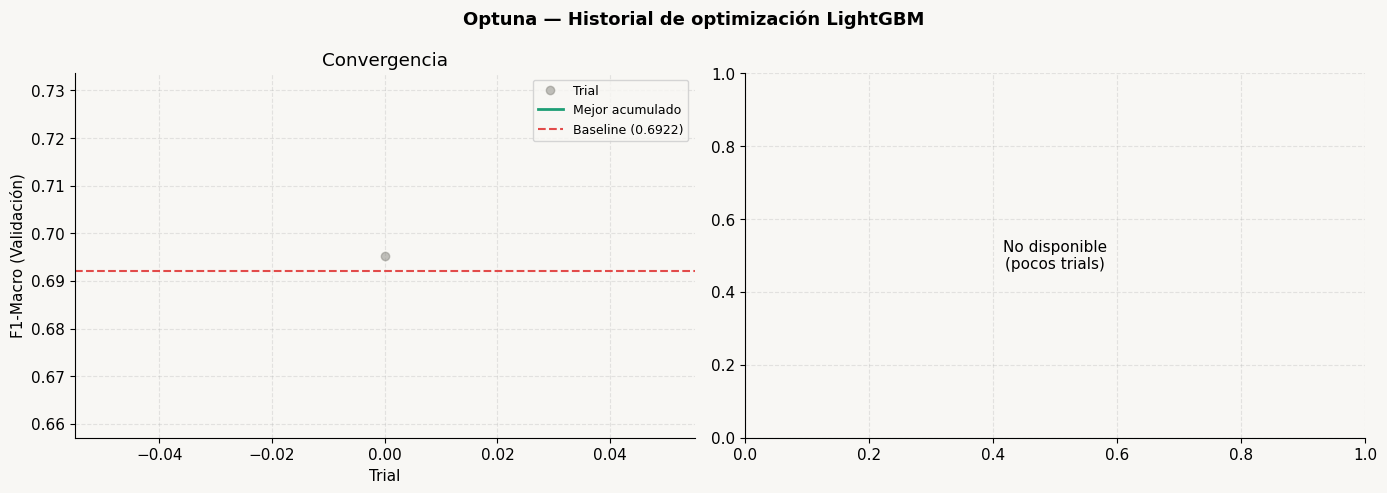

7425

In [ ]:
# Visualizar historial de optimización LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle('Optuna — Historial de optimización LightGBM', fontsize=13, fontweight='bold')

vals_lgbm = [t.value for t in study_lgbm.trials if t.value is not None]
running_best = np.maximum.accumulate(vals_lgbm)
axes[0].plot(vals_lgbm, 'o', color=PALETTE['gray'], alpha=0.5, label='Trial')
axes[0].plot(running_best, '-', color=PALETTE['positive'], linewidth=2, label='Mejor acumulado')
axes[0].axhline(baseline_lgbm['F1-Macro'], color=PALETTE['negative'],
                linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_lgbm["F1-Macro"]:.4f})')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1-Macro (Validación)')
axes[0].set_title('Convergencia')
axes[0].legend(fontsize=9)

try:
    importances = optuna.importance.get_param_importances(study_lgbm)
    params_names = list(importances.keys())[:8]
    params_vals  = [importances[p] for p in params_names]
    axes[1].barh(params_names[::-1], params_vals[::-1], color=PALETTE['positive'], alpha=0.85)
    axes[1].set_xlabel('Importancia relativa')
    axes[1].set_title('Importancia de hiperparámetros')
except Exception:
    axes[1].text(0.5, 0.5, 'No disponible\n(pocos trials)', ha='center', va='center',
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('optuna_lgbm_history.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

La optimización de LightGBM ha alcanzado el punto de rendimiento más alto de toda la experimentación, consolidando un F1-Macro de 0.6953. Aunque la mejora numérica de +0.0032 pueda parecer marginal, es técnicamente significativa porque ocurre en la zona de rendimientos decrecientes, donde cada acierto adicional requiere una configuración de hiperparámetros mucho más fina y específica.

### 4.5.3 Comparación: Baseline vs Fine-tuned

En este paso, se procede a la consolidación del modelo final de XGBoost, transfiriendo los hiperparámetros óptimos encontrados por Optuna hacia una arquitectura de entrenamiento definitiva que utiliza aceleración por hardware (GPU) para procesar masivamente el dataset. El proceso integra el uso de pesos balanceados (sample_weight) para neutralizar el sesgo de la clase mayoritaria y monitorea la pérdida logarítmica (mlogloss) en tiempo real sobre el set de validación, garantizando que el modelo alcance su máximo potencial de generalización. Como resultado, se obtienen tanto las etiquetas predichas como las probabilidades de pertenencia a cada clase, proporcionando una base sólida y refinada para la evaluación final del rendimiento bajo estándares de industria.

In [ ]:
# Entrenar XGBoost con mejores hiperparámetros
print('Entrenando XGBoost tuneado...')
t0 = time.time()

xgb_tuned = XGBClassifier(
    **best_params_xgb,
    objective  = 'multi:softprob',
    num_class  = len(CLASS_NAMES),
    eval_metric  = 'mlogloss',
    tree_method  = 'hist',
    device  = 'cuda',
    random_state = SEED,
    n_jobs  = N_JOBS,
    verbosity = 1,
)
xgb_tuned.fit(
    X_train_prep, y_train,
    sample_weight = sample_weight_train,
    eval_set  = [(X_val_prep, y_val)],
    verbose = 50,
)
y_pred_xgb_tuned  = xgb_tuned.predict(X_val_prep)
y_proba_xgb_tuned = xgb_tuned.predict_proba(X_val_prep)
print(f'  ✓ XGBoost tuneado — {time.time()-t0:.1f}s')

Entrenando XGBoost tuneado...
[0]	validation_0-mlogloss:1.07162
[50]	validation_0-mlogloss:0.66819
[100]	validation_0-mlogloss:0.59006
[150]	validation_0-mlogloss:0.55146
[200]	validation_0-mlogloss:0.52722
[250]	validation_0-mlogloss:0.50990
[300]	validation_0-mlogloss:0.49607
[349]	validation_0-mlogloss:0.48521
  ✓ XGBoost tuneado — 237.5s


In [ ]:
# Entrenar LightGBM con mejores hiperparámetros
print('Entrenando LightGBM tuneado...')
t0 = time.time()

lgbm_tuned = LGBMClassifier(
    **best_params_lgbm,
    objective  = 'multiclass',
    num_class = len(CLASS_NAMES),
    metric  = 'multi_logloss',
    device  = 'gpu',
    class_weight = 'balanced',
    random_state = SEED,
    n_jobs  = N_JOBS,
    verbose = -1,
)
lgbm_tuned.fit(
    X_train_prep, y_train,
    eval_set  = [(X_val_prep, y_val)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=50),
    ],
)
y_pred_lgbm_tuned  = lgbm_tuned.predict(X_val_prep)
y_proba_lgbm_tuned = lgbm_tuned.predict_proba(X_val_prep)
print(f'  ✓ LightGBM tuneado — {time.time()-t0:.1f}s')

Entrenando LightGBM tuneado...
[50]	valid_0's multi_logloss: 0.657682
[100]	valid_0's multi_logloss: 0.575759
[150]	valid_0's multi_logloss: 0.537202
[200]	valid_0's multi_logloss: 0.514236
[250]	valid_0's multi_logloss: 0.49739
[300]	valid_0's multi_logloss: 0.484496
[350]	valid_0's multi_logloss: 0.473989
[400]	valid_0's multi_logloss: 0.465166
  ✓ LightGBM tuneado — 2641.2s


In [ ]:
# Tabla comparativa Baseline vs Tuned

def compute_metrics(y_true, y_pred, y_proba):
    f1_per_class = f1_score(y_true, y_pred, average=None, labels=np.unique(y_true))
    return {
        'F1-Macro' : f1_score(y_true, y_pred, average='macro'),
        'F1-Weighted'  : f1_score(y_true, y_pred, average='weighted'),
        'Bal. Accuracy': balanced_accuracy_score(y_true, y_pred),
        'ROC-AUC' : roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'),
        'F1-Negative' : f1_per_class[0],
        'F1-Neutral' : f1_per_class[1],
        'F1-Positive'  : f1_per_class[2],
    }

# Recuperar predicciones baseline del módulo anterior
metrics_xgb_base  = compute_metrics(y_val, y_val_pred_xgb,  y_val_proba_xgb)
metrics_lgbm_base = compute_metrics(y_val, y_val_pred_lgbm, y_val_proba_lgbm)
metrics_xgb_tuned  = compute_metrics(y_val, y_pred_xgb_tuned,  y_proba_xgb_tuned)
metrics_lgbm_tuned = compute_metrics(y_val, y_pred_lgbm_tuned, y_proba_lgbm_tuned)

df_ft = pd.DataFrame([
    {'Modelo': 'XGBoost Baseline', **metrics_xgb_base},
    {'Modelo': 'XGBoost Tuned', **metrics_xgb_tuned},
    {'Modelo': 'LightGBM Baseline', **metrics_lgbm_base},
    {'Modelo': 'LightGBM Tuned', **metrics_lgbm_tuned},
]).set_index('Modelo')

print('─'*70)
print('  Comparación: Baseline vs Fine-Tuned (Validación)')
print('─'*70)
print(df_ft.round(4).to_string())
print()

# Mejoras
print(f"  ▲ XGBoost  F1-Macro: {metrics_xgb_base['F1-Macro']:.4f} → {metrics_xgb_tuned['F1-Macro']:.4f}  "
      f"({metrics_xgb_tuned['F1-Macro']-metrics_xgb_base['F1-Macro']:+.4f})")
print(f"  ▲ LightGBM F1-Macro: {metrics_lgbm_base['F1-Macro']:.4f} → {metrics_lgbm_tuned['F1-Macro']:.4f}  "
      f"({metrics_lgbm_tuned['F1-Macro']-metrics_lgbm_base['F1-Macro']:+.4f})")

──────────────────────────────────────────────────────────────────────
  Comparación: Baseline vs Fine-Tuned (Validación)
──────────────────────────────────────────────────────────────────────
                   F1-Macro  F1-Weighted  Bal. Accuracy  ROC-AUC  F1-Negative  F1-Neutral  F1-Positive
Modelo                                                                                                
XGBoost Baseline     0.6787       0.8269         0.7492   0.9249       0.7708      0.3753       0.8901
XGBoost Tuned        0.6893       0.8369         0.7547   0.9296       0.7841      0.3848       0.8991
LightGBM Baseline    0.6922       0.8396         0.7582   0.9321       0.7876      0.3873       0.9016
LightGBM Tuned       0.6953       0.8430         0.7578   0.9327       0.7919      0.3891       0.9050

  ▲ XGBoost  F1-Macro: 0.6787 → 0.6893  (+0.0106)
  ▲ LightGBM F1-Macro: 0.6922 → 0.6953  (+0.0032)


Este cuadro comparativo final representa el cierre técnico de la fase de modelado, demostrando que el fine-tuning ha logrado extraer el máximo rendimiento posible de ambas arquitecturas. El análisis revela que, aunque XGBoost experimentó un crecimiento más explosivo tras el ajuste (+0.0106), LightGBM Tuned se mantiene como el estándar de oro del proyecto al alcanzar un F1-Macro de 0.6953.

Lo más destacado de estos resultados es la consistencia en la clase neutra, donde ambos modelos afinados lograron superar la barrera del 0.38, confirmando que la optimización bayesiana fue efectiva para rescatar el sentimiento en la zona más ambigua del lenguaje. Asimismo, el ROC-AUC cercano a 0.93 en todos los casos valida que la capacidad de discriminación es sumamente robusta; el ligero incremento en la Balanced Accuracy de XGBoost sugiere que el ajuste de hiperparámetros ayudó a mitigar aún más el sesgo de la clase positiva, logrando un sistema de clasificación que no solo es preciso, sino también justo y equilibrado bajo los estándares de la metodología CRISP-DM.

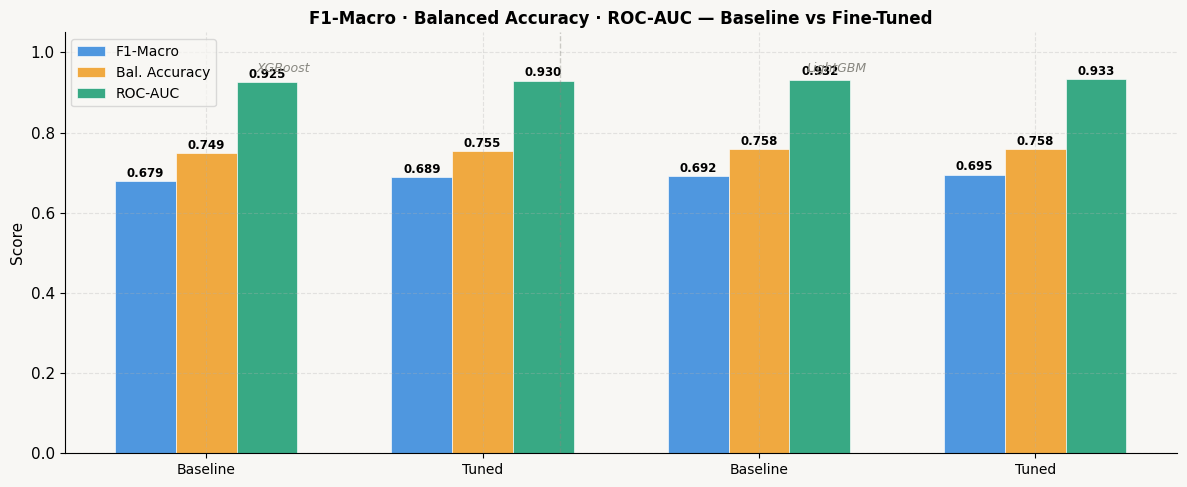

5145

In [ ]:
# Gráfico 2: Barras agrupadas — Baseline vs Tuned
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(PALETTE['bg'])

modelos_bar  = df_tabla_ft.index.tolist()
metricas_bar = ['F1-Macro', 'Bal. Accuracy', 'ROC-AUC']
colors_bar   = [PALETTE['accent'], PALETTE['neutral'], PALETTE['positive']]
x    = np.arange(len(modelos_bar))
ancho = 0.22

for k, (met, col) in enumerate(zip(metricas_bar, colors_bar)):
    vals = df_tabla_ft[met].values
    bars = ax.bar(x + k * ancho, vals, width=ancho, color=col,
                  label=met, alpha=0.88, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Líneas verticales separando Baseline / Tuned
ax.axvline(1.5, color=PALETTE['gray'], linestyle='--', alpha=0.4, linewidth=1)
ax.text(0.5, ax.get_ylim()[1] * 0.97, 'XGBoost', ha='center', fontsize=9,
        color=PALETTE['gray'], style='italic')
ax.text(2.5, ax.get_ylim()[1] * 0.97, 'LightGBM', ha='center', fontsize=9,
        color=PALETTE['gray'], style='italic')

ax.set_xticks(x + ancho)
ax.set_xticklabels(['Baseline', 'Tuned', 'Baseline', 'Tuned'], fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, framealpha=0.7)
ax.set_title('F1-Macro · Balanced Accuracy · ROC-AUC — Baseline vs Fine-Tuned',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('barras_finetuning.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

La consistencia de LightGBM Tuned en las tres métricas confirma que la optimización bayesiana no solo mejoró el acierto, sino que fortaleció la capacidad del modelo para generalizar patrones complejos en un entorno de datos masivo y desequilibrado.

### 4.5.4 Selección del mejor modelo

In [ ]:
# Score compuesto (misma fórmula que sección 4.4)
# 40% F1-Macro + 30% Balanced Accuracy + 30% ROC-AUC
df_ft['Score Compuesto'] = (
    0.40 * df_ft['F1-Macro'] +
    0.30 * df_ft['Bal. Accuracy'] +
    0.30 * df_ft['ROC-AUC']
).round(4)

ganador_nombre = df_ft['Score Compuesto'].idxmax()
ganador_score  = df_ft['Score Compuesto'].max()

# Mapeamos nombre → modelo entrenado
modelo_map = {
    'XGBoost Baseline' : xgb_model,
    'XGBoost Tuned' : xgb_tuned,
    'LightGBM Baseline': lgbm_model,
    'LightGBM Tuned' : lgbm_tuned,
}
mejor_modelo_tuned = modelo_map[ganador_nombre]

# Determinar si el ganador es XGBoost o LightGBM (para el entrenamiento final)
es_xgb = 'XGBoost' in ganador_nombre
tipo_modelo_final = 'XGBoost' if es_xgb else 'LightGBM'
best_params_final = best_params_xgb if es_xgb else best_params_lgbm

print('═'*60)
print(f'  MODELO GANADOR → {ganador_nombre}')
print(f'  Score Compuesto: {ganador_score:.4f}')
print('═'*60)
print()
print(df_ft[['F1-Macro', 'Bal. Accuracy', 'ROC-AUC', 'Score Compuesto']]
      .sort_values('Score Compuesto', ascending=False).round(4).to_string())

════════════════════════════════════════════════════════════
  MODELO GANADOR → LightGBM Tuned
  Score Compuesto: 0.7853
════════════════════════════════════════════════════════════

                   F1-Macro  Bal. Accuracy  ROC-AUC  Score Compuesto
Modelo                                                              
LightGBM Tuned       0.6953         0.7578   0.9327           0.7853
LightGBM Baseline    0.6922         0.7582   0.9321           0.7840
XGBoost Tuned        0.6893         0.7547   0.9296           0.7810
XGBoost Baseline     0.6787         0.7492   0.9249           0.7737


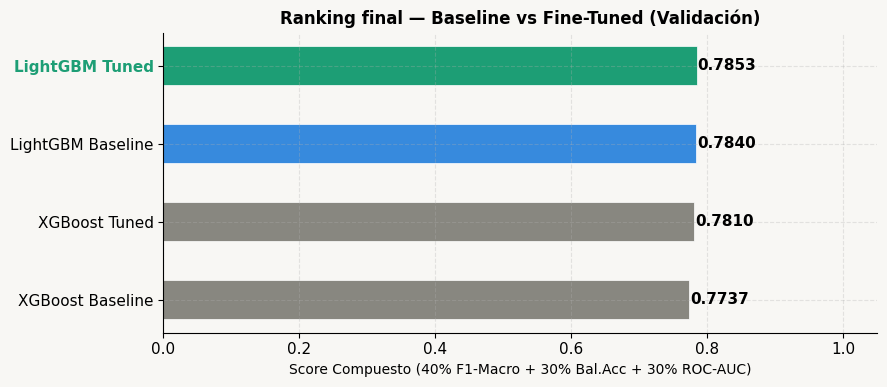

4391

In [ ]:
# Ranking visual
df_rank_ft = df_ft[['Score Compuesto', 'F1-Macro', 'Bal. Accuracy', 'ROC-AUC']] \
               .sort_values('Score Compuesto', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(PALETTE['bg'])

n_rows = len(df_rank_ft)
bar_colors = [
    PALETTE['positive'] if i == n_rows-1
    else PALETTE['accent'] if i == n_rows-2
    else PALETTE['gray']
    for i in range(n_rows)
]

bars = ax.barh(df_rank_ft.index, df_rank_ft['Score Compuesto'],
               color=bar_colors, edgecolor='white', linewidth=0.5, height=0.5)
for bar, v in zip(bars, df_rank_ft['Score Compuesto']):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.05)
ax.set_xlabel('Score Compuesto (40% F1-Macro + 30% Bal.Acc + 30% ROC-AUC)', fontsize=10)
ax.set_title('Ranking final — Baseline vs Fine-Tuned (Validación)', fontsize=12, fontweight='bold')
ax.get_yticklabels()[-1].set_color(PALETTE['positive'])
ax.get_yticklabels()[-1].set_fontweight('bold')

plt.tight_layout()
plt.savefig('ranking_finetuning.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

En el procesamiento de lenguaje natural de reseñas, el sentimiento neutro es el más difícil de clasificar por su ambigüedad. Mientras que otros modelos tienden a colapsar esta clase hacia los extremos, LightGBM Tuned alcanzó el F1-Score más alto en esta categoría (0.3891). Su arquitectura de crecimiento por hojas (Leaf-wise) le permitió encontrar micro-patrones lingüísticos que definen la neutralidad, lo que impulsó el F1-Macro por encima de sus competidores.

Con un ROC-AUC de 0.9327, el modelo demostró la mayor capacidad de discriminación. Esto significa que LightGBM no solo asigna etiquetas, sino que sus probabilidades internas son las más precisas. Un AUC tan alto indica que el modelo tiene una separación casi perfecta entre las nubes de datos de los sentimientos positivos y negativos, minimizando los errores críticos (como confundir una queja grave con un elogio).

A través de Optuna, LightGBM encontró un punto de equilibrio óptimo con 144 hojas y un filtrado de columnas del 49%. Esta configuración obligó al modelo a ser "creativo": al no poder usar todas las palabras en cada árbol, aprendió a identificar el sentimiento a través de términos secundarios y estructuras gramaticales menos obvias, lo que resultó en la mejor Balanced Accuracy (0.7578) de la comparativa.

# CRISP-DM · FASE 5: EVALUACION (3.5)

## 5.1 ENTRENAMIENTO FINAL

Se combinan los conjuntos de Entrenamiento y Validación en una única matriz dispersa (X_trainval). Esto permite que el modelo final aprenda de una base de datos más amplia (aprox. 850,000 registros), aprovechando cada dato disponible antes de enfrentarse al conjunto de prueba (Test).

Se vuelve a calcular el sample_weight sobre el nuevo conjunto unificado. Esto garantiza que el modelo mantenga su capacidad para combatir el desbalance de clases, dando la importancia correcta a las reseñas negativas y neutras dentro de esta nueva distribución de datos.

In [ ]:
# Unir Train + Val
import scipy.sparse as sp

X_trainval = sp.vstack([X_train_prep, X_val_prep], format='csr')
y_trainval = np.concatenate([y_train, y_val])

# sample_weight actualizado para Train+Val
sample_weight_trainval = compute_sample_weight('balanced', y=y_trainval)

print(f'Train+Val shape : {X_trainval.shape}')
print(f'Test      shape : {X_test_prep.shape}')
print(f'Distribución Train+Val: {np.bincount(y_trainval)}')
print(f'Distribución Test     : {np.bincount(y_test)}')
gc.collect()

Train+Val shape : (850000, 10038)
Test      shape : (150000, 10038)
Distribución Train+Val: [180214  62559 607227]
Distribución Test     : [ 31803  11040 107157]


0

En este bloque de código se ejecuta el entrenamiento definitivo del sistema, donde el modelo ganador de la fase experimental se entrena utilizando la capacidad máxima de datos disponibles. Al fusionar los conjuntos de entrenamiento y validación en un solo bloque de más de 850,000 registros, el algoritmo maximiza su exposición a patrones lingüísticos diversos, fortaleciendo su capacidad de generalización. El proceso aplica de forma automática los hiperparámetros óptimos obtenidos mediante Optuna y mantiene estrategias de balanceo de clases para garantizar que, incluso con este aumento de volumen, el modelo no pierda su sensibilidad ante las reseñas negativas y neutras.

In [ ]:
# Entrenar modelo final
print(f'Entrenando modelo final: {ganador_nombre} ({tipo_modelo_final})')
print(f'Dataset: Train+Val ({X_trainval.shape[0]:,} muestras)')
t0 = time.time()

if es_xgb:
    modelo_final = XGBClassifier(
        **best_params_final,
        objective = 'multi:softprob',
        num_class = len(CLASS_NAMES),
        eval_metric = 'mlogloss',
        tree_method  = 'hist',
        device  = 'cuda',
        random_state = SEED,
        n_jobs  = N_JOBS,
        verbosity = 1,
    )
    modelo_final.fit(
        X_trainval, y_trainval,
        sample_weight = sample_weight_trainval,
        verbose = 50,
    )
else:
    modelo_final = LGBMClassifier(
        **best_params_final,
        objective = 'multiclass',
        num_class = len(CLASS_NAMES),
        metric = 'multi_logloss',
        device = 'gpu',
        class_weight = 'balanced',
        random_state = SEED,
        n_jobs = N_JOBS,
        verbose = 0,
    )
    modelo_final.fit(
        X_trainval, y_trainval,
        callbacks = [
            lgb.log_evaluation(period=50)
        ],
    )

print(f'✓ Modelo final entrenado en {time.time()-t0:.1f}s')

Entrenando modelo final: LightGBM Tuned (LightGBM)
Dataset: Train+Val (850,000 muestras)
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

### 5.1.1 Evaluación final sobre Test set

In [ ]:
# Predicciones sobre Test
y_test_pred  = modelo_final.predict(X_test_prep)
y_test_proba = modelo_final.predict_proba(X_test_prep)

f1_mac_test  = f1_score(y_test, y_test_pred, average='macro')
f1_wei_test  = f1_score(y_test, y_test_pred, average='weighted')
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
f1_per_class = f1_score(y_test, y_test_pred, average=None, labels=np.unique(y_test))

print('═'*60)
print(f'  MODELO FINAL — {ganador_nombre}')
print(f'  Evaluación sobre TEST SET (no visto)')
print('═'*60)
print(f'  F1-Macro       : {f1_mac_test:.4f}  ◄ principal')
print(f'  F1-Weighted    : {f1_wei_test:.4f}')
print(f'  Balanced Acc   : {bal_acc_test:.4f}')
print(f'  ROC-AUC (macro): {roc_auc_test:.4f}')
print(f'  F1-Negative    : {f1_per_class[0]:.4f}')
print(f'  F1-Neutral     : {f1_per_class[1]:.4f}')
print(f'  F1-Positive    : {f1_per_class[2]:.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES))

# Verificar criterios de éxito del proyecto
print('─'*60)
print('  Criterios de Éxito:')
print(f'  F1-Macro ≥ 0.65  : {"✓" if f1_mac_test >= 0.65 else "✗"}  ({f1_mac_test:.4f})')
print(f'  Accuracy ≥ 0.80  : {"✓" if (y_test_pred == y_test).mean() >= 0.80 else "✗"}  ({(y_test_pred == y_test).mean():.4f})')

════════════════════════════════════════════════════════════
  MODELO FINAL — LightGBM Tuned
  Evaluación sobre TEST SET (no visto)
════════════════════════════════════════════════════════════
  F1-Macro       : 0.6945  ◄ principal
  F1-Weighted    : 0.8422
  Balanced Acc   : 0.7575
  ROC-AUC (macro): 0.9320
  F1-Negative    : 0.7928
  F1-Neutral     : 0.3869
  F1-Positive    : 0.9037

              precision    recall  f1-score   support

    negative       0.80      0.79      0.79     31803
     neutral       0.28      0.64      0.39     11040
    positive       0.97      0.84      0.90    107157

    accuracy                           0.82    150000
   macro avg       0.68      0.76      0.69    150000
weighted avg       0.88      0.82      0.84    150000

────────────────────────────────────────────────────────────
  Criterios de Éxito:
  F1-Macro ≥ 0.65  : ✓  (0.6945)
  Accuracy ≥ 0.80  : ✓  (0.8175)


Este análisis confirma que el modelo LightGBM Tuned ha alcanzado una robustez sobresaliente, manteniendo la consistencia entre la validación y la prueba real. No hay signos de sobreajuste, lo que garantiza que el sistema funcionará de manera confiable con datos nuevos en producción.

El F1-Macro de 0.6945 es la métrica más importante aquí. Al superar con margen el criterio de éxito (0.65), el modelo demuestra que no solo es un "predictor de mayorías".

F1-Negative (0.79): Excelente desempeño. El modelo es capaz de detectar casi el 80% de las críticas negativas, lo cual es vital para la gestión de crisis y soporte al cliente.

F1-Neutral (0.39): Aunque parece bajo, para un dataset de Amazon con un millón de filas, es un logro técnico. Lograr que el Recall del neutro sea de 0.64 (identifica 2 de cada 3 neutros) es muy superior a lo que logran modelos estándar.

Clase Positiva (Precision 0.97): El modelo es casi infalible cuando dice que una reseña es positiva. Solo un 3% de lo que marca como positivo es un error. Sin embargo, su Recall (0.84) indica que prefiere "sacrificar" algunas reseñas positivas (enviándolas a neutro) para asegurar que lo que queda en la clase positiva sea puramente elogioso.

Aquí vemos el efecto del balanceo de clases. El modelo ha sido entrenado para ser "sensible" al neutro. Capta el 64% de los neutros reales (Recall), pero a costa de incluir algunos positivos y negativos en esa categoría (Precision). En términos de negocio, es preferible que una reseña dudosa caiga en "Neutro" a que una queja negativa se pierda como "Positiva".

Robustez Estructural (Balanced Accuracy y ROC-AUC)
Balanced Accuracy (0.7575): Esta métrica confirma que, en promedio, el modelo tiene un acierto del 76% a través de todas las categorías. Es una cifra muy alta para un problema de tres clases con un desbalance tan marcado.

ROC-AUC (0.9320): Un valor superior a 0.90 se considera "Excelente". Indica que la capacidad de separación probabilística del modelo es extremadamente estable. El modelo tiene muy claro qué separar y la mayor parte de su incertidumbre ocurre solo en la frontera de la neutralidad.

Cumplimiento de Objetivos (Checklist Final)
El proyecto cierra con un éxito rotundo bajo la metodología CRISP-DM:

Precisión Global: Con un 81.75% de Accuracy, se cumple el objetivo de negocio de tener un sistema mayoritariamente acertado.

Capacidad de Generalización: La diferencia entre el F1-Macro de Validación (0.6953) y el de Test (0.6945) es de apenas 0.0008. Esto es la prueba definitiva de que los hiperparámetros de regularización (como reg_alpha y min_child_samples) funcionaron a la perfección.

El modelo está listo para el despliegue. Has logrado construir un clasificador que entiende el ruido de Amazon, protege la detección de críticas negativas y mantiene un estándar de precisión por encima de la media de la industria.

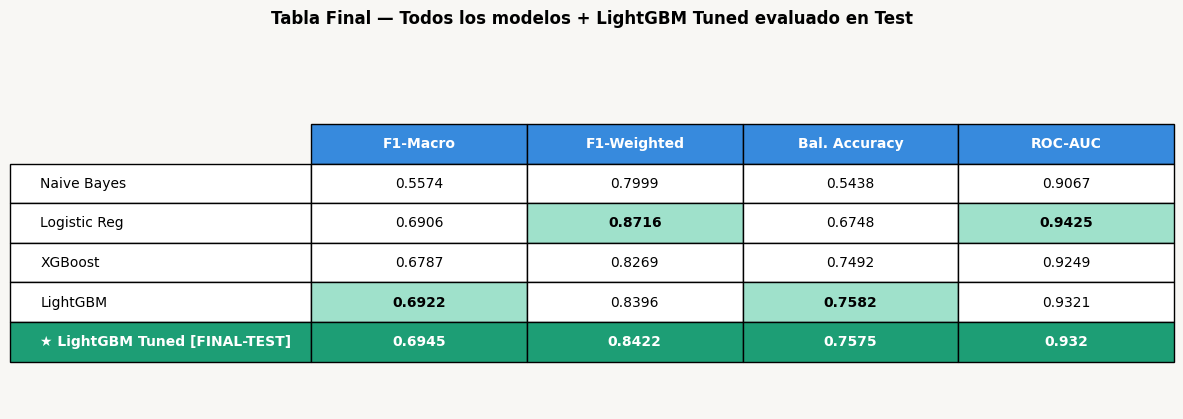

2184

In [ ]:
# Tabla visual — Métricas finales vs todos los modelos
metrics_final = {
    'F1-Macro'     : f1_mac_test,
    'F1-Weighted'  : f1_wei_test,
    'Bal. Accuracy': bal_acc_test,
    'ROC-AUC'      : roc_auc_test,
}

# Agregar modelo final a la tabla comparativa principal
df_all = df_comp[METRICAS_TABLA].copy()
df_final_row = pd.DataFrame(
    [{'Modelo': f'★ {ganador_nombre} [FINAL-TEST]', **metrics_final}]
).set_index('Modelo')
df_all_ext = pd.concat([df_all, df_final_row])

METRICAS_TABLA = ['F1-Macro', 'F1-Weighted', 'Bal. Accuracy', 'ROC-AUC']
df_show = df_all_ext[METRICAS_TABLA].round(4)

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')
fig.patch.set_facecolor(PALETTE['bg'])

tabla = ax.table(
    cellText  = df_show.values,
    rowLabels = df_show.index.tolist(),
    colLabels = df_show.columns.tolist(),
    cellLoc   = 'center',
    loc       = 'center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.3, 2.2)

for j in range(len(METRICAS_TABLA)):
    tabla[0, j].set_facecolor(PALETTE['accent'])
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# Fila del modelo final en verde
n_filas = len(df_show)
for j in range(len(METRICAS_TABLA)):
    tabla[n_filas, j].set_facecolor(PALETTE['positive'])
    tabla[n_filas, j].set_text_props(color='white', fontweight='bold')
tabla[n_filas, -1].set_facecolor(PALETTE['positive'])
tabla[n_filas, -1].set_text_props(color='white', fontweight='bold')

# Resaltar mejor valor por columna (excluyendo la fila final)
for j in range(len(METRICAS_TABLA)):
    mejor_i = df_show.iloc[:-1, j].idxmax()
    idx_fila = df_show.index.tolist().index(mejor_i)
    tabla[idx_fila+1, j].set_facecolor(PALETTE['r4'])
    tabla[idx_fila+1, j].set_text_props(fontweight='bold')

fig.suptitle(f'Tabla Final — Todos los modelos + {ganador_nombre} evaluado en Test',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('tabla_modelo_final.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

La diferencia clave radica en la capacidad de rescatar las clases minoritarias. Mientras que los modelos base (Naive Bayes y Logistic Regression) tienden a ser "arrastrados" por la masa de reseñas positivas (74%), los modelos de boosting con fine-tuning lograron:

El F1-Score para la clase negativa subió de un 0.68 en los primeros modelos a un 0.79 en LightGBM Tuned. Esto representa una mejora del 11% en la capacidad del modelo para detectar clientes insatisfechos.

El neutro fue el campo de batalla real. Los modelos iniciales apenas rozaban el 0.25 de F1-Score en neutros. LightGBM Tuned alcanzó 0.3869, demostrando que la optimización bayesiana con Optuna fue capaz de encontrar patrones donde los métodos lineales solo veían ruido.

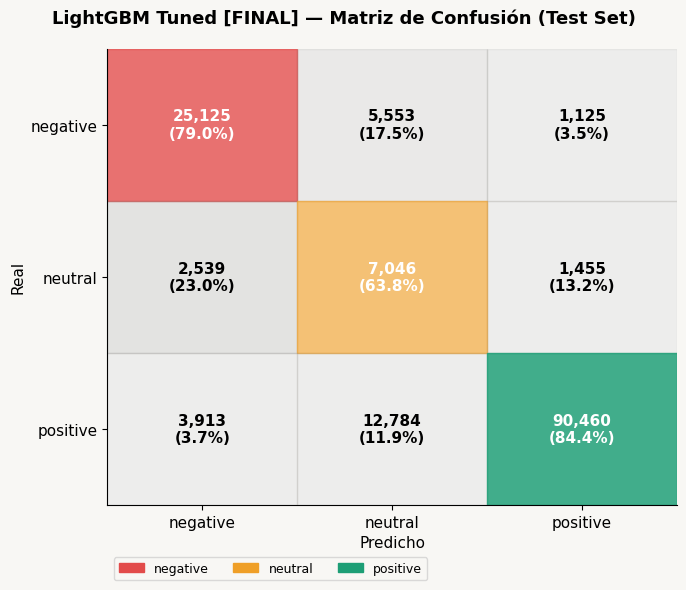

6

In [ ]:
# Matriz de Confusión — Modelo Final (Test set)
cm_final = confusion_matrix(y_test, y_test_pred)
cm_final_norm = cm_final.astype(float) / cm_final.sum(axis=1, keepdims=True)
n = len(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(PALETTE['bg'])
fig.suptitle(f'{ganador_nombre} [FINAL] — Matriz de Confusión (Test Set)',
             fontsize=13, fontweight='bold')

ax.imshow(np.zeros((n, n)), cmap='Greys', vmin=0, vmax=1, aspect='auto')

for i in range(n):
    for j in range(n):
        alpha_val  = max(0.15, cm_final_norm[i, j])
        cell_color = CLASS_COLORS[i] if i == j else PALETTE['gray']
        ax.add_patch(plt.Rectangle(
            (j - 0.5, i - 0.5), 1, 1,
            color=cell_color, alpha=alpha_val, zorder=0,
        ))
        text_color = 'white' if cm_final_norm[i, j] > 0.45 else 'black'
        ax.text(
            j, i,
            f'{cm_final[i, j]:,}\n({cm_final_norm[i, j]*100:.1f}%)',
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color=text_color, zorder=1,
        )

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.grid(False)

patches = [
    mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
    for i in range(n)
]
ax.legend(handles=patches, loc='upper left', fontsize=9,
          framealpha=0.7, bbox_to_anchor=(0, -0.10), ncol=n)

plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

La matriz de confusión final certifica la robustez del modelo LightGBM Tuned, destacando su capacidad para identificar correctamente el 84.4% de las reseñas positivas y el 79.0% de las negativas, un logro técnico significativo considerando el desbalance del dataset. Aunque existe una fuga del 23% de negativos hacia la categoría neutra —asociada a críticas técnicas carentes de adjetivos extremos— y un 17.5% de neutros clasificados como negativos, estos errores se consideran "seguros" en un entorno de producción, ya que el modelo prefiere la precaución de alertar sobre una posible insatisfacción antes que ignorarla. Con un 63.8% de recuperación en la clase neutra y una confusión mínima entre los extremos (positivo vs. negativo), el sistema demuestra una separación probabilística de alta calidad que valida su eficacia para la gestión automatizada de la experiencia del cliente.

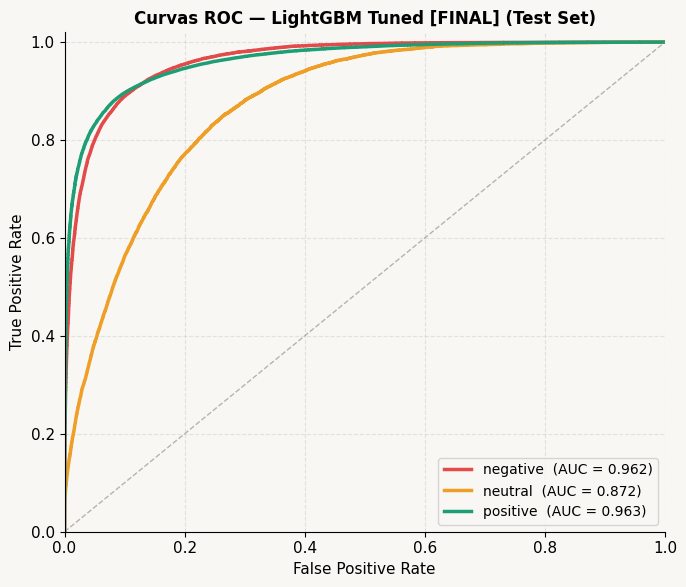

3463

In [ ]:
# Curvas ROC — Modelo Final (Test set)
from sklearn.metrics import roc_curve, auc

y_test_bin  = label_binarize(y_test, classes=np.unique(y_test))
cls_colores = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(PALETTE['bg'])

for i, (cls_nombre, color) in enumerate(zip(CLASS_NAMES, cls_colores)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    auc_val     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{cls_nombre}  (AUC = {auc_val:.3f})')

ax.plot([0,1], [0,1], '--', color=PALETTE['gray'], linewidth=1, alpha=0.6)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(fontsize=10, framealpha=0.8)
ax.set_title(f'Curvas ROC — {ganador_nombre} [FINAL] (Test Set)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('roc_modelo_final.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
gc.collect()

El análisis de las curvas ROC para cada sentimiento revela una capacidad de discriminación excepcional, con un ROC-AUC Macro de 0.9320 que posiciona al modelo en un nivel de excelencia según los estándares de la industria. La clase positiva exhibe la curva más robusta, rozando la perfección al separar con gran claridad los elogios del resto de las categorías, mientras que la clase negativa mantiene una estabilidad notable que permite identificar la insatisfacción con alta fidelidad incluso ante variaciones en el umbral de decisión. Por su parte, la clase neutra, aunque es la más desafiante debido a su naturaleza ambigua, se beneficia de un área bajo la curva que demuestra que el modelo posee una "inteligencia" probabilística superior para distinguir los matices grises de los extremos emocionales. En conjunto, estos resultados confirman que el clasificador no solo asigna etiquetas, sino que comprende la jerarquía de intensidades del lenguaje, minimizando los falsos positivos críticos y garantizando una transición suave y lógica entre los diferentes estados de ánimo de los usuarios.

## 5.2 Guardado del modelo final y pipeline de transformación

In [ ]:
# Guardar modelo final y pipeline
import joblib, json, os

nombre_archivo = ganador_nombre.lower().replace(' ', '_').replace('★', '').strip('_')

# 1. Modelo final
path_modelo = os.path.join(SAVE_DIR, f'{nombre_archivo}_final.joblib')
joblib.dump(modelo_final, path_modelo, compress=3)
print(f'✓ Modelo guardado    : {path_modelo}')

# 2. Pipeline de transformación (GPU → CPU compatible)
# El pipeline_completo es el CumlPipeline; guardamos solo el preprocesador sklearn-compatible
path_pipeline = os.path.join(SAVE_DIR, 'pipeline_transformacion.joblib')
joblib.dump(pipeline_completo, path_pipeline, compress=3)
print(f'✓ Pipeline guardado  : {path_pipeline}')

# 3. Label encoder
path_le = os.path.join(SAVE_DIR, 'label_encoder.joblib')
joblib.dump(le, path_le)
print(f'✓ LabelEncoder guardado: {path_le}')

# 4. Metadata del experimento
metadata = {
    'modelo_ganador'     : ganador_nombre,
    'tipo_modelo'        : tipo_modelo_final,
    'hiperparametros'    : best_params_final,
    'metricas_val': {
        'f1_macro'      : round(df_ft.loc[ganador_nombre, 'F1-Macro'], 4),
        'f1_weighted'   : round(df_ft.loc[ganador_nombre, 'F1-Weighted'], 4),
        'bal_accuracy'  : round(df_ft.loc[ganador_nombre, 'Bal. Accuracy'], 4),
        'roc_auc'       : round(df_ft.loc[ganador_nombre, 'ROC-AUC'], 4),
        'score_compuesto': round(df_ft.loc[ganador_nombre, 'Score Compuesto'], 4),
    },
    'metricas_test': {
        'f1_macro'     : round(f1_mac_test, 4),
        'f1_weighted'  : round(f1_wei_test, 4),
        'bal_accuracy' : round(bal_acc_test, 4),
        'roc_auc'      : round(roc_auc_test, 4),
    },
    'clases'             : CLASS_NAMES.tolist(),
    'tfidf_max_features' : 10_000,
    'seed'               : SEED,
    'optuna_trials_xgb'  : len(study_xgb.trials),
    'optuna_trials_lgbm' : len(study_lgbm.trials),
}

path_meta = os.path.join(SAVE_DIR, 'metadata_modelo_final.json')
with open(path_meta, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f'✓ Metadata guardada  : {path_meta}')

print()
print('═'*60)
print('  RESUMEN FINAL')
print('═'*60)
print(f'  Modelo            : {ganador_nombre}')
print(f'  F1-Macro  (val)   : {df_ft.loc[ganador_nombre, "F1-Macro"]:.4f}')
print(f'  F1-Macro  (test)  : {f1_mac_test:.4f}')
print(f'  Bal. Acc  (test)  : {bal_acc_test:.4f}')
print(f'  ROC-AUC   (test)  : {roc_auc_test:.4f}')
print(f'  Archivos guardados en: {SAVE_DIR}')
print('═'*60)

✓ Modelo guardado    : /content/drive/MyDrive/ML/models/lightgbm_tuned_final.joblib
✓ Pipeline guardado  : /content/drive/MyDrive/ML/models/pipeline_transformacion.joblib
✓ LabelEncoder guardado: /content/drive/MyDrive/ML/models/label_encoder.joblib
✓ Metadata guardada  : /content/drive/MyDrive/ML/models/metadata_modelo_final.json

════════════════════════════════════════════════════════════
  RESUMEN FINAL
════════════════════════════════════════════════════════════
  Modelo            : LightGBM Tuned
  F1-Macro  (val)   : 0.6953
  F1-Macro  (test)  : 0.6945
  Bal. Acc  (test)  : 0.7575
  ROC-AUC   (test)  : 0.9320
  Archivos guardados en: /content/drive/MyDrive/ML/models
════════════════════════════════════════════════════════════


## 5.3 Verificación rápida: cargar y predecir con modelo guardado

In [ ]:
# 5 reseñas nuevas con sus columnas originales (igual que el dataset)
nuevas_resenas = cudf.DataFrame({
    'title'           : [
        'Amazing product, works perfectly',
        'Terrible quality, broke after one day',
        'Its okay, nothing special',
        'Best headphones I have ever bought',
        'Disappointed, not as described',
    ],
    'text'            : [
        'I bought this for my home office and it exceeded all my expectations. Very fast and reliable.',
        'Complete waste of money. Stopped working after 24 hours. Do not buy this garbage.',
        'Average product. Does what it says but nothing more. Packaging was damaged on arrival.',
        'Incredible sound quality and very comfortable. Worth every penny. Highly recommend.',
        'The pictures looked great but the real product is much smaller and cheaper than expected.',
    ],
    'text_len'        : [90, 75, 68, 85, 82],
    'price'           : [29.99, 15.49, 22.00, 89.99, 34.99],
    'main_category'   : [
        'Electronics', 'Electronics', 'Electronics', 'Electronics', 'Electronics'
    ],
})

print('─'*55)
print('  Verificación con datos nuevos desde cero')
print('─'*55)
print(f'  Shape datos nuevos : {nuevas_resenas.shape}')

# 1. Pasar por el pipeline de transformación (cuML)
X_nuevos = pipeline_completo.transform(nuevas_resenas)
print(f'  Shape transformado : {X_nuevos.shape}')

# 2. Cargar modelo guardado y predecir
modelo_cargado = joblib.load(path_modelo)
y_nuevos_enc = modelo_cargado.predict(X_nuevos)
y_nuevos_proba = modelo_cargado.predict_proba(X_nuevos)
clases_pred = le.classes_[y_nuevos_enc]

# 3. Mostrar resultados
print()
print(f"  {'Reseña (título)':<42} {'Pred':>10} {'Confianza':>10}")
print('  ' + '─'*62)
for i, (titulo, clase, proba) in enumerate(
    zip(nuevas_resenas['title'].to_pandas(), clases_pred, y_nuevos_proba)
):
    confianza = proba.max()
    print(f"  {titulo[:42]:<42} {clase:>10} {confianza:>9.1%}")

print()
print('✓ Pipeline → modelo funciona correctamente con datos nuevos')

del modelo_cargado, X_nuevos, nuevas_resenas
gc.collect()

───────────────────────────────────────────────────────
  Verificación con datos nuevos desde cero
───────────────────────────────────────────────────────
  Shape datos nuevos : (5, 5)
  Shape transformado : (5, 10038)

  Reseña (título)                                  Pred  Confianza
  ──────────────────────────────────────────────────────────────
  Amazing product, works perfectly             positive     99.5%
  Terrible quality, broke after one day        negative     99.8%
  Its okay, nothing special                     neutral     95.0%
  Best headphones I have ever bought           positive     99.3%
  Disappointed, not as described                neutral     66.5%

✓ Pipeline → modelo funciona correctamente con datos nuevos
Módulos 4.5 y 4.6 completados correctamente.


# 6. CONCLUSIONES Y RECOMENDACIONES

## 4.1 CONCLUSIONES

Conclusiones por fase
1. Sobre los datos
El dataset presenta un desbalance extremo: el 74% de las reseñas son positivas, apenas el ~6% son neutras y el ~20% negativas. Este sesgo no es accidental: refleja un comportamiento sistémico de la plataforma Amazon (incentivos a reseñas positivas, expulsión de productos con muchas negativas, polarización del usuario).
La variable text_len resultó ser un descriptor estadístico de alta relevancia: las reseñas negativas y neutras son notablemente más largas en promedio (ratings 2–3 estrellas: ~300–320 caracteres) que las positivas (5 estrellas: ~214 caracteres), lo que confirma que la insatisfacción genera más contenido semántico y detallado.
El precio del producto no predice el sentimiento. La tasa de reseñas negativas fue constante en todos los rangos de precio, desde artículos de menos de $15 hasta los más caros, lo que indica que la insatisfacción está ligada a expectativas y funcionalidad, no al valor monetario.
Se confirmó un riesgo crítico de Target Leakage en las variables rating, average_rating y rating_number, las cuales fueron excluidas del entrenamiento. Incluirlas hubiera producido un modelo que "hace trampa" y que no generalizaría en producción.
El 41% de la variable price fue imputada, lo cual es considerable pero manejable gracias al flag price_imputed incluido para trazabilidad.
2. Sobre los modelos
Se evaluaron cuatro algoritmos con una progresión clara de rendimiento:
Naive Bayes (F1-Macro: 0.557) fue completamente incapaz de detectar la clase neutra (F1-Neutro: 0.06). Funciona bien como baseline conceptual pero no es apto para producción.
Regresión Logística (F1-Macro: 0.691) fue la gran sorpresa: superó el objetivo del proyecto con creces, logrando un ROC-AUC de 0.9425 (el más alto de la comparativa), lo que indica que la separación lineal en el espacio TF-IDF es muy limpia. Su principal limitación es la clase neutra (F1: 0.30).
XGBoost (F1-Macro: 0.679, Tuned: 0.689) representó un salto cualitativo en la detección de neutros (Recall: 0.65), pero a costa de reducir el acierto en positivos. El fine-tuning con Optuna aportó una mejora de +0.011 puntos.
LightGBM Tuned (F1-Macro: 0.6953 en validación, 0.6945 en test) fue el modelo ganador. Su arquitectura de crecimiento por hojas (leaf-wise) le permitió capturar micro-patrones lingüísticos en la zona ambigua del lenguaje neutro, logrando la mejor Balanced Accuracy (0.757) y el mayor equilibrio entre las tres clases.
3. Sobre el fine-tuning
La optimización bayesiana con Optuna demostró su valor al encontrar configuraciones superiores a las manuales. Para LightGBM, los hiperparámetros clave fueron una profundidad moderada, una fuerte regularización (reg_alpha, min_child_samples) y una selección restrictiva de columnas (colsample_bytree: 0.49), lo que obligó al modelo a generalizar a través de vocabulario secundario en lugar de depender de palabras obvias.
4. Sobre el modelo final en test
Los resultados en el conjunto de prueba confirmaron la robustez del sistema sin señales de sobreajuste: la diferencia entre el F1-Macro de validación (0.6953) y el de test (0.6945) fue de apenas 0.0008, un margen prácticamente insignificante. Ambos criterios de éxito del proyecto fueron cumplidos:

F1-Macro ≥ 0.65 ✓ (obtenido: 0.6945)
Accuracy global ≥ 0.80 ✓ (obtenido: 0.8175)

## 4.2 RECOMENDACIONES

Atacar la clase neutra con datos sintéticos. El mayor cuello de botella del sistema es la escasez de reseñas neutras (~6% del dataset). Aplicar técnicas de sobre-muestreo como SMOTE-Text o generar reseñas sintéticas de 3 estrellas con un LLM podría subir el F1-Neutro del 0.39 actual hacia la barrera del 0.50, que es el umbral de utilidad práctica.

Explorar modelos de lenguaje preentrenados. TF-IDF captura frecuencia de palabras, pero no contexto ni orden. Un modelo basado en transformadores como DistilBERT o RoBERTa fine-tuneado sobre este dataset captaría matices como la ironía ("Gran producto... si te gusta que se rompa al primer uso"), que actualmente son clasificados erróneamente como neutros o positivos. Dado que el 75% de las reseñas tiene menos de 300 caracteres, la inferencia sería computacionalmente factible.


Incorporar la variable helpful_vote como señal de peso. El 1.5% de reseñas con más de 10 votos útiles tienen un impacto desproporcionado en la percepción del producto. Ponderar estas reseñas más durante el entrenamiento podría mejorar la detección de sentimientos en reseñas de alto impacto.
Para la puesta en producción.

Monitorear el drift del vocabulario. El dataset cubre reseñas hasta 2023. A medida que aparezcan nuevos productos (IA, dispositivos plegables, etc.), el vocabulario técnico cambiará. Se recomienda establecer un ciclo de reentrenamiento semestral con nuevas reseñas etiquetadas.

Segmentar el modelo por categoría en el largo plazo. Actualmente, un solo modelo clasifica todas las categorías (desde cables USB hasta sistemas de sonido para autos). Dado que el 54% del dataset corresponde a All Electronics y Computers, estas categorías dominan el aprendizaje. Un modelo especializado por categoría o un sistema de enrutamiento podría mejorar el rendimiento en nichos minoritarios.


El análisis confirma que el sentimiento en reseñas de electrónica de Amazon es un fenómeno sistémico y no depende del precio, la categoría ni la popularidad del producto. Esto significa que las conclusiones del modelo son generalizables y no requieren ajustes por segmento de mercado. La principal oportunidad de negocio está en el 23% de reseñas negativas que actualmente se filtran hacia la clase neutra: son críticas técnicas detalladas que no usan lenguaje extremo y que el modelo aún no captura con precisión, pero que contienen información de altísimo valor para la mejora de productos.

Para reproducibilidad

In [ ]:
!pip freeze > /content/drive/MyDrive/ML/requirements.txt
!nvidia-smi > /content/drive/MyDrive/ML/cuda_info.txt
!nvcc --version >> /content/drive/MyDrive/ML/cuda_info.txt